# Проект SocialSearch

## Тематические статьи
Про графы:
- [Хорошая статья на хабре про кластеризацию графив](https://habr.com/ru/company/dca/blog/265077/)
- [алгоритм louvain](https://louvain-igraph.readthedocs.io/en/latest/index.html)
- [Awesome Community Detection Research Papers](https://github.com/benedekrozemberczki/awesome-community-detection)


Про нахождение информации о человеке:
- https://bsfo.ru/threads/probiv-cheloveka-v-vk.4110/
- https://www.iphones.ru/iNotes/705983
- https://cryptoworld.su/5-sposobov-probit-informaciyu-o-cheloveke-v-seti/
- https://habr.com/en/company/echelon/blog/321754/ Отличная статья на хабре
    
    
Лайфкаки по поиску информации:
- https://vk.com/feed?obj=1&q=&section=mentions
- [Каталог пользователей вк](https://vk.com/catalog.php)
- https://vk.com/foaf.php?id=245089915 Посмотреть код страницы
- http://сервисы.гувм.мвд.рф/info-service.htm?sid=2000 Провека действительности паспорта

Конкуренты (похожие проекты):
- https://bazaman.ru/ Нахождение человека по данным. Работает хреново
- https://poiski-people.ru/instrukziya.html Плохо работает [То, что нашли обо мне](https://poiski-people.ru/rossiya/moskva/boris-novichkov-moskva-90185.html) 
- https://people.yandex.ru (Поиск людей по различной информации)
- https://poisk-help.ru/ Работает плохо [Обо мне](https://poisk-help.ru/rossiya/moskva/boris-novichkov-moskva-2959.html)
- http://spys.one/vk/ Банальное копирование вк. Только информация со страницы пользователя
- https://vk.barkov.net/userinfo.aspx Требует доступ к странице. Базовая информация

Получение ключа доступа пользователя для vk api
https://oauth.vk.com/authorize?client_id=7091370&scope=photos,audio,video,docs,notes,pages,status,offers,questions,wall,groups,notifications,stats,ads,offline,docs,pages,stats,notifications,wall,friends&response_type=token

# Задачи проекта: 
1. Найти человека по минимальномо количеству известных о нем данных
2. Получить всю возможную инфомацию о человеке из открытых источников (социальные сети, гос. порталы, гугл, некоторые сайты)
3. Проанализировать (аналитичестки, с помощью ML) 
4. Предоставить все в красивом человеко-читаемом виде конечному потребителю (пользователю данного ресурса)

## Информация о человеке
### Базовые аспекты
*Поля страницы вк: first_name, last_name, photo_200, sex, bdate, city, country, relatives, home_town, maiden_name, relation*
- Имя
- Вевичья фамилия
- Фото
- Пол
- Возраст
- Страна
- Родной город
- Родственники


### Основная деятельность (в настоящем / прошлом)
*Поля страницы вк: career, education, occupation, schools, universities, military*
- Школа (класс, год)
- Вуз (факультет, курс, год)
- Работа (направленность, год)
- Бизнес (направления, сайт и пр)

### Сетевая жизнь / Контакты
*Поля страницы вк: nickname, online, site, exports, contacts, verified, last_seen, connections, followers_count*
- Сайт
- Все социальные сети
- Подписчики
- Verify
- Приватный аккаунт

### Интересы / Занятия
*Поля страницы вк: books, activities, movies, music, tv, trending, games, interests, quotes*
- Увлечения
- Хобби
- Музыка Фильмы Игры Книги

### Характеристика / Анализ
*Поля страницы вк: status, counters, personal, about*

*Информация на основе всех имеющихся данных*
- Экстраверт / Интроверт (в процентах)
- Популярность в сети (Подписчики, друзья и тд)
- Сетевая доступность (в процентах). Количество личной информации в сети
- Общественный статус (один из нескольких вариантов)
- Процент одиночных друзей (не состоящих в сообществах испытуемого)
- Придумать еще что-нибудь!

## Социальные сообщества человека
**Любые группы людей, к которым относится испытуемый:**
- Социальные объединения среди друзей
- Сообщества на основе общих групп
- Виртуальное объединение на основе общего интереса (несвязные друзья программисты)

### Операции над сообществами
- Поиск полного коллектива из небольшой его части

### Параметры каждого объединения
- Список всех объединяющих коллектив факторы (место учебы, интересы, возраст, пол и пр)
- Связность сообщества (исходя из графа)
- Размер сообщества (количество участников)
- Тут можно много чего еще придумать!


memory saved
# timeit graph 0.12339 77.0182722
# timeit communities_from_graph 0.06267 77.0810056
# timeit pools 0.06286 77.0811896


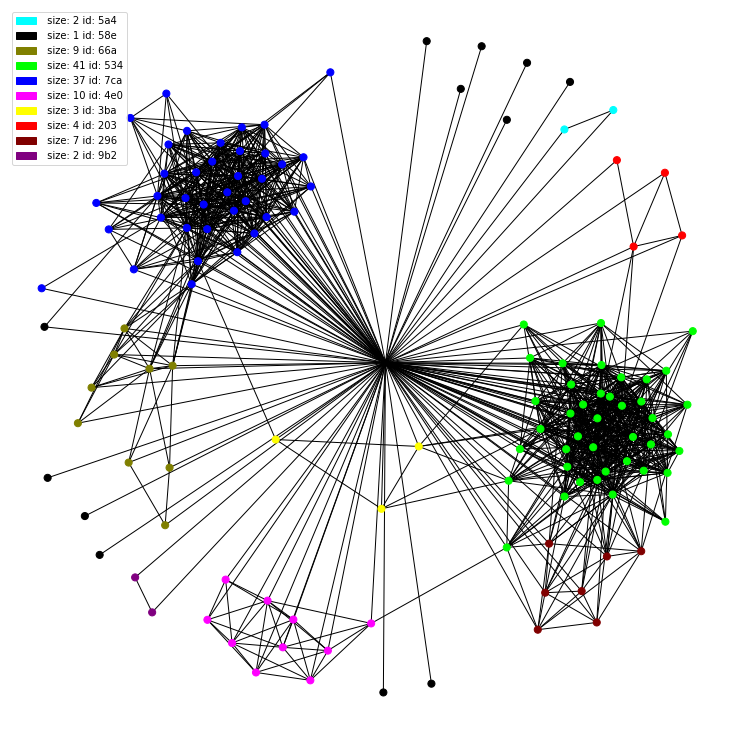

# timeit show_graph 0.46998 77.5529685
# timeit color_graph 0.53470 77.5530348


In [13]:
import numpy as np
import pandas as pd
from skimage import io
import networkx as nx
import random
import matplotlib.pyplot as plt
import vk
from community_pool import Community
import warnings
warnings.filterwarnings("ignore")
import collections
from collections import Counter
import datetime
from time import time
import json
import functools
from vkuser import VKUser
import networkx as nx
import math
import pickle
from queue import Queue
from main import *
# %matplotlib qt
%matplotlib inline
# bapi.start_agents()
bapi.save_memory()

# pprint(VKUser('boris2000n').friends.pools()[1].params, compact=True)
VKUser('boris2000n').friends.color_graph()

In [2]:
VKUser('https://vk.com/katya11111').full_data

{'id': 64674539,
 'first_name': 'Катерина',
 'last_name': 'Крупник',
 'sex': 1,
 'nickname': '',
 'maiden_name': '',
 'bdate': '14.9',
 'city': {'id': 8, 'title': 'Череповец'},
 'country': {'id': 1, 'title': 'Россия'},
 'photo_200': 'https://sun1-21.userapi.com/c857728/v857728845/267b4/G74UBBBp5Us.jpg?ava=1',
 'online': 0,
 'mobile_phone': '',
 'home_phone': '',
 'site': '',
 'status': 'Always say seventeen and insane',
 'last_seen': {'time': 1569448504, 'platform': 4},
 'verified': 0,
 'trending': 0,
 'followers_count': 70,
 'counters': {'albums': 9,
  'videos': 31,
  'audios': 0,
  'notes': 1,
  'photos': 171,
  'groups': 104,
  'gifts': 91,
  'friends': 243,
  'online_friends': 25,
  'mutual_friends': 8,
  'user_photos': 21,
  'followers': 70,
  'subscriptions': 1,
  'pages': 67},
 'occupation': {'type': 'university', 'id': 297, 'name': 'МФТИ (Физтех)'},
 'career': [],
 'military': [],
 'university': 297,
 'university_name': 'МФТИ (Физтех)',
 'faculty': 0,
 'faculty_name': '',
 'gra

In [41]:
users_data = ['b80bb7740288fda1f201890375a60c8f', 'id206972305', 'id206972305', 'id206972305', 'destitutiones', 'destitutiones', 'destitutiones', 'heartr8', 'heartr8', 'heartr8', 'tanya_vt', 'tanya_vt', 'tanya_vt', 'lbezvershenko', 'lbezvershenko', 'lbezvershenko', 'idteolar', 'idteolar', 'idteolar', 'id144257519', 'id144257519', 'id144257519', 'panda______panda', 'panda______panda', 'panda______panda', 'frybochkin', 'frybochkin', 'frybochkin', 'verrr_moot', 'verrr_moot', 'verrr_moot', 'xd207549729', 'xd207549729', 'xd207549729', 'boris2000n', 'boris2000n', 'boris2000n', 'id_mrmrmrmr', 'id_mrmrmrmr', 'id_mrmrmrmr', 'f1mpy', 'f1mpy', 'f1mpy', 'id194901225', 'id194901225', 'id194901225', 'vera_burkova', 'vera_burkova', 'vera_burkova', 'id364938697', 'id364938697', 'id364938697', 'ilya_mclovin', 'ilya_mclovin', 'ilya_mclovin', 'id306213513', 'id306213513', 'id306213513', 'evgeny_the_greate', 'evgeny_the_greate', 'evgeny_the_greate', 'halohup', 'halohup', 'halohup', 'id152841084', 'id152841084', 'id152841084', 'sashok_033', 'sashok_033', 'sashok_033', 'fake_lithium', 'fake_lithium', 'fake_lithium', '0katerinka', '0katerinka', '0katerinka', 'arbuzov555', 'arbuzov555', 'arbuzov555']
users = [VKUser(u) for u in users_data]
Community(users).full_data
# bapi.save_memory()

* VK API Request: %s users
* Get user data 306213513
* Get user data 120290191
* Get user data 206972305
* Get user data 318948755
* Get user data 160178201
* Get user data 245089915
* Get user data 207549729
* Get user data 224451631
* Get user data 342282677
* Get user data 181540026
* Get user data 120266299
* Get user data 149966784
* Get user data 364938697
* Get user data 154123343
* Get user data 188029147
* Get user data 311308643
* Get user data 265740776
* Get user data 194901225
* Get user data 196639225
* Get user data 152841084


{306213513: {'id': 306213513,
  'first_name': 'Екатерина',
  'last_name': 'Строганова',
  'sex': 1,
  'nickname': '',
  'maiden_name': '',
  'photo_200': 'https://sun9-10.userapi.com/c849336/v849336660/1bbe3c/pzFNXLjb06A.jpg?ava=1',
  'online': 0,
  'mobile_phone': '',
  'home_phone': '',
  'site': '',
  'status': '',
  'last_seen': {'time': 1569447507, 'platform': 1},
  'verified': 0,
  'trending': 0,
  'followers_count': 1,
  'full': True},
 120290191: {'id': 120290191,
  'first_name': 'Альбина',
  'last_name': 'Рухадзе',
  'sex': 1,
  'nickname': '',
  'maiden_name': '',
  'bdate': '23.7',
  'photo_200': 'https://sun1-25.userapi.com/c845217/v845217376/61020/Qb2a5Y5Lp0Y.jpg?ava=1',
  'online': 0,
  'site': '',
  'status': 'Всё временно ↢',
  'last_seen': {'time': 1569446971, 'platform': 4},
  'verified': 0,
  'trending': 0,
  'followers_count': 186,
  'occupation': {'type': 'university', 'id': 297, 'name': 'МФТИ (Физтех)'},
  'full': True},
 206972305: {'id': 206972305,
  'first_name

In [40]:
from itertools import groupby

things = [("animal", "bear"), ("animal", "duck"), ("plant", "cactus"), ("vehicle", "speed boat"), ("vehicle", "school bus")]
things= [("a", 2), ("b", 5), ("b", 6)]
list(groupby(things, lambda x: x[0]))

[('a', <itertools._grouper at 0x7fd5a98619b0>),
 ('b', <itertools._grouper at 0x7fd5a9861978>)]

In [19]:
from itertools import groupby
a = [('aa', 2), ('b', 5), ('aa', 6)]
for key, group in groupby(a, lambda x: x[0]):
    print(key)
    for i in group:
        print(i)

aa
('aa', 2)
b
('b', 5)
aa
('aa', 6)


In [3]:
a = bapi.get_obj('180')#bapi.get_obj('4d4') + bapi.get_obj('2d5')
a.params

* VK API Request: %s users
* Get user data 52450171
* Get user data 194852519
* Get user data 368637672
* Get user data 310732263
* Get user data 144257519
* Get user data 160451063
* Get user data 86190327


{'size': 7,
 'sex_mean': 1.8571428571428572,
 'mans_amount': 6,
 'womans_amount': 1,
 'age_median': 18.65010972941581,
 'age_mean': 18.65010972941581,
 'age_amin': 18.65010972941581,
 'age_amax': 18.65010972941581,
 'age_len': 1.0,
 'age_list': [18.65010972941581],
 'city_counter': Counter({'Санкт-Петербург': 1,
          'Москва': 3,
          'Петропавловск-Камчатский': 1}),
 'country_counter': Counter({'Россия': 5}),
 'online_sum': 1.0,
 'online_mean': 0.14285714285714285,
 'online_mobile_sum': 1.0,
 'online_mobile_mean': 1.0,
 'verified_sum': 0.0,
 'verified_mean': 0.0,
 'last_seen_mean': 0.03293514842551852,
 'last_seen_amax': 0.07971094207631217,
 'last_seen_median': 0.030150756891126985,
 'site': [' ', 'https://ctftime.org/user/36430', 'https://github.com/m4drat/'],
 'site_fr': 0.42857142857142855,
 'followers_count_mean': 83.28571428571429,
 'followers_count_median': 41.0,
 'followers_count_amax': 245.0,
 'home_town_first_fr': 0.14285714285714285,
 'home_town': [('Казань', 1), 

In [25]:
%%time
x = []
y = []
for i in range(15, 210, 5):
    x.append(i)
    t = time()
    bapi.get_followers('_anastasia__a_princess_', limit=100)
    y.append(time() - t)

* Inst api call: get_followers, agent: dinafomichiova4713
* Inst api call: get_followers, agent: lidiiadrozdova5662
* Inst api call: get_followers, agent: varvarabolshakova8794
* Inst api call: get_followers, agent: agniiazhdanova541
* Inst api call: get_followers, agent: kiraovchinnikova680
* Inst api call: get_followers, agent: varvarakniazeva9295
* Inst api call: get_followers, agent: agniiafedoseeva9784
* Inst api call: get_followers, agent: agniiakolesnikova5157
* Inst api call: get_followers, agent: aleksandrakniazeva7955
* Inst api call: get_followers, agent: tamarazueva1062
* Inst api call: get_followers, agent: agniiamuraviova212
* Inst api call: get_followers, agent: dinafomichiova4713
* Inst api call: get_followers, agent: lidiiadrozdova5662
* Inst api call: get_followers, agent: varvarabolshakova8794
* Inst api call: get_followers, agent: agniiazhdanova541
* Inst api call: get_followers, agent: kiraovchinnikova680
* Inst api call: get_followers, agent: varvarakniazeva9295
*

In [15]:
%%time
a = bapi.get_followers('denis7916073669', limit=100)
print(len(a))
resy = bapi.get_users_followers(a, count=300, limit=100)
print(len(sum(resy, [])))
print(len(set(sum(resy, []))))

* Inst api call: get_followers, agent: leilakalinina4900
100
* Inst api call: get_followers, agent: ameliiafedoseeva674
* Inst api call: get_followers, agent: aleksandrakniazeva7955* Inst api call: get_followers, agent: agniiafedoseeva9784
* Inst api call: get_followers, agent: leilagordeeva2201

* Inst api call: get_followers, agent: iaroslavaalekseeva5882
* Inst api call: get_followers, agent: agniiamuraviova212
* Inst api call: get_followers, agent: lidiiarogova4743
* Inst api call: get_followers, agent: reginalikhachiova8613
* Inst api call: get_followers, agent: ameliiasergeeva946
* Inst api call: get_followers, agent: ameliiasharapova9216
* Inst api call: get_followers, agent: tamarakulakova2946
* Inst api call: get_followers, agent: varvarabolshakova8794
* Inst api call: get_followers, agent: elizavetabobyliova5180
* Inst api call: get_followers, agent: varvarakniazeva9295
* Inst api call: get_followers, agent: sabinastepanova1794
* Inst api call: get_followers, agent: lidiiaers

* Inst api call: get_followers, agent: lidiiadrozdova5662
NEED MORE INST AGENTS!
SLEEP 1.7130658626556396 seconds
NEED MORE INST AGENTS!
SLEEP 1.7725274562835693 seconds
* Inst api call: get_followers, agent: leilakovaliova6560NEED MORE INST AGENTS!NEED MORE INST AGENTS!
SLEEP 1.8448243141174316 seconds
EMPTY AGENTS LIST
EMPTY AGENTS LIST
EMPTY AGENTS LIST

SLEEP 1.7949697971343994 seconds

EMPTY AGENTS LIST
EMPTY AGENTS LISTEMPTY AGENTS LISTEMPTY AGENTS LISTEMPTY AGENTS LIST
EMPTY AGENTS LIST
EMPTY AGENTS LISTEMPTY AGENTS LIST




EMPTY AGENTS LIST
EMPTY AGENTS LISTEMPTY AGENTS LIST
EMPTY AGENTS LIST
EMPTY AGENTS LISTEMPTY AGENTS LIST
EMPTY AGENTS LIST
EMPTY AGENTS LIST
EMPTY AGENTS LIST
EMPTY AGENTS LIST

EMPTY AGENTS LISTEMPTY AGENTS LIST

EMPTY AGENTS LIST
EMPTY AGENTS LIST

EMPTY AGENTS LISTEMPTY AGENTS LISTEMPTY AGENTS LIST
EMPTY AGENTS LIST
EMPTY AGENTS LIST

EMPTY AGENTS LIST
EMPTY AGENTS LIST
EMPTY AGENTS LISTEMPTY AGENTS LISTEMPTY AGENTS LIST
EMPTY AGENTS LIST
EMPTY AGENTS LI

* Inst api call: get_followers, agent: varvaraaksionova5004
NEED MORE INST AGENTS!
SLEEP 1.8436577320098877 seconds
* Inst api call: get_followers, agent: tamarazueva1062
NEED MORE INST AGENTS!
SLEEP 1.7120060920715332 seconds
NEED MORE INST AGENTS!
SLEEP 1.602856159210205 seconds
NEED MORE INST AGENTS!
SLEEP 1.4672718048095703 seconds
NEED MORE INST AGENTS!
SLEEP 1.146305799484253 seconds
NEED MORE INST AGENTS!NEED MORE INST AGENTS!
SLEEP 1.1636037826538086 seconds
SLEEP 1.2234482765197754 seconds

NEED MORE INST AGENTS!
SLEEP 1.3244261741638184 seconds
NEED MORE INST AGENTS!
SLEEP 1.3451335430145264 seconds
NEED MORE INST AGENTS!NEED MORE INST AGENTS!NEED MORE INST AGENTS!
SLEEP 1.4083211421966553 seconds
NEED MORE INST AGENTS!
SLEEP 1.413799524307251 seconds
NEED MORE INST AGENTS!
SLEEP 1.4185559749603271 seconds

SLEEP 1.3724513053894043 seconds
NEED MORE INST AGENTS!NEED MORE INST AGENTS!
SLEEP 1.5794501304626465 seconds
NEED MORE INST AGENTS!
SLEEP 1.5839221477508545 seconds
NEED

* Inst api call: get_followers, agent: agatasuvorova6583
* Inst api call: get_followers, agent: agniiamuraviova212
* Inst api call: get_followers, agent: elizavetakudriavtseva6928
* Inst api call: get_followers, agent: kamillabelousova5951
* Inst api call: get_followers, agent: reginakovaliova726
NEED MORE INST AGENTS!
SLEEP 1.8236603736877441 seconds
* Inst api call: get_followers, agent: sabinastepanova1794
NEED MORE INST AGENTS!
SLEEP 1.8940227031707764 seconds
* Inst api call: get_followers, agent: leilakovaliova6560
NEED MORE INST AGENTS!
SLEEP 1.810957908630371 seconds
NEED MORE INST AGENTS!
SLEEP 1.773216724395752 seconds
NEED MORE INST AGENTS!
SLEEP 1.809842824935913 seconds
* Inst api call: get_followers, agent: varvaraaksionova5004
NEED MORE INST AGENTS!
SLEEP 1.7031819820404053 seconds
NEED MORE INST AGENTS!
SLEEP 1.7596983909606934 seconds
NEED MORE INST AGENTS!
SLEEP 1.805130958557129 seconds
NEED MORE INST AGENTS!
SLEEP 1.8360166549682617 seconds
NEED MORE INST AGENTS!
SL

In [8]:
resx = '[astana_mir_electroniki, issatussupov, s_yereke, dilnazakmurza, d0y.dre0m, essie_amy334, 0sweetblood, aset_amantaev, cuvoe, sagibibiliwka, kazybekov_ye, danilka0.1, sagiwww.ka, aminaash_, raushanova8, astmodeus, shukurbekova.45, gulnara_ramet1964, amir29052016, azamatttovna, ai.ami.nagi, astana_astana_2019, veronika.tunyaeva.tattoo, _zhaks_21, aisuls.rametova, evil__tattoo, shabyt_muz_studio, smile_scorching_ice, ladys_world____, bekaarystanbekov, lucky_shop__kz, popivayu_4aek, erdaulet_r0, juzbasar_saken, yelnaz.kaliaskarova, shuagxhkns, mikialiet, amor.kz, biko_0605, gorohov.boris, _ziziti_, batyrbekovturarr, ___kenesbaai, yulya_ke4332, blatata_77_7, chingis.92, nshukurbekova, nurgozhina_00, _prosto_.lera_, rametovaaa, nurdekova_nazym, moldash_29, d_makulbekova, _makeee___, modnayaledi1, erbolat04061962, aktoty_turikpenbaeva, sarsenbaeva_nazerke, galiiarametova, dilnazakmurzaaaaaaaaaa, orynkulbaituganova, zhubanishev_damir, moon_zhm7, saisyuhada, kuanwkalievmadi, _aiko_21.01, brandmedicalshop, ast_baby_massage, toleibaeva0_14, kalamkasrametova, __shalharovnaaaa__, daurenashurov, stom_services, jb_uniforms, iwanttosdohnut, shukurbekovanagima, ashur.00, _alimkhanovna, ivan.peric93, bekdillayeva_, rametovagalia, galiia4979, nagima20036394, _zhumataevv, majrarametova412, __ttuuiip, piar.follow.follow, aidoshka_antoshka, z.z.z.z.89, taranev_, iambogomolovilya, chechenya77, sofi___bond_, twinkle_zass, kolsanchik6583, shevliakova.aleksandra, ivleva_vladislava, essie_amy334, kseniapanova_, tatianatsaplina_, maria.bigler, vla7da2019, 1318wtb, _s.kripton_, msuga1628, lovyoubts, mikialiet, essie_amy334, hanaedits.png, gcfjvbb, kiimjunecotton, haleyforvince977, jimunison, 3hgroovin, hemi_7.2l, jkbst, patric._.suzy_, sunflowersshii, redifrt5678g, 2004sasha1312, qwertypou253, ekstazi_777, orehpatrul, zasdferty, danilpie_fan, danilpiee, dovbusaleksej8, iamhxlydrxn, camarena.concerts, lovier78, __ysfwert__, tupoi_daun_chi_sho, memento_mori_1703, toturchan28, dude_i_saw_your_socks, reminderaboutthestars, 9solov.evv, arxattambaev, ilunechka, arseniideord, abakumova__anastasia, veronicamartins2913, talantbek_t, dugbaoxuan, auf_musik_, denisova.nada2003, ayndob22, _darya_evgenievnaa_, lfl_23_86, weyhdominik, lovelysingh729, jml1953.jm, lachir107, mersad.sar3poorde, souzaadailsonde, arifonbasi, soniszseung, nilton_gonzales, raguvir.sinh.7, azimov.elxan, _saglam_ariglama_2018, qazax_dirnaq_qaynagi_sekine, vaantrix3, kadir.turkmen.54738, ausheliza, dazawadi, furkaninmuhammed, sohibjonmamiro, dude_have_u_seen_my_socks, dextrapateram, _ziibilex_, _alinka_me_, whiteblack1321, wunnajeremy, lashmaker_cherkassy_alina, ratcomleyma, happy_gir_1212, ___.m.a.l.a.y.a.__, lera_blah_blah_blah, criucov.roma, nizaaaam, alena_musatova_, arle.gun, z.z.z.z.89, taranev_, chechenya77, sofi___bond_, twinkle_zass, katskynight, kolsanchik6583, maria.bigler, shevliakova.aleksandra, ivleva_vladislava, tatianatsaplina_, kseniapanova_, essie_amy334, tasty_simple100, ruslan_massage39, sapphire._stars, sysoevaliudmila, sergey_mischenko90, zarubenvladimir, dreambebeauty, z.z.z.z.89, _mia_morty, ___korny, postelka_3939, essie_amy334, pauline_bonad, ms.angelinna, liubovgilman, zhuber1989, in100max2, proshkinnikita1868, rozovyiporg, shukshina_nadezhda_, mazurina.liubov, center_podarkov58, mar.fabraya, b.mary.go.round, retrokino8, aleshamolchanoff, kuuuba3, glebadaesd, historian147, tikhonova._alex, te.uli, gordeikolomiets, agumkiria, gyunai_babaeva, grata25, christmas.toy7, brezhneva996, annabenu1571, eco_kitezh, estrellanass, timurbernatsky, kolesnikov1092, mariia_shchurova, iuliia_9102, morwennalouise, golodnyipovar, vlkharlamov, skrutenkov, el__ke, valentinaliubezno, dnevni4ok_kotana, super.bogans, sveta.obukhovskaya, kbri_kitezh, smart.course, burnazyanevelin, satalok, zombie_77_, ecilaraccoon, ribin_bird, evgeny_tattooart, dr.mamasha, newtonsky, shura_bez_azhura, just_lontra, honypern, strahovka_tinao, morozovkitezh, lesnaya_roza, anto.ska, vankakabanov, natalushka_kitezh, rudneva1064, english_penza, kitezh_community, sshibaev, sea_kati, landysh, vasilina_fedotova10, kirill.kislenko, alena.vladimirovna.simonenko, prazdnik_katerinaa, neiroleptik, studo_leninskiy_prospect, lizaholl, detiorion, irina_orion, deti.domateplo, lipatcon, grishina195, estel.edain, antongromozdin, davydov1964.9, s_kislenko, marjindeti, ankalagonchik, e.ryazhskaya, dcleighton, sobolevaiuliia6155, galelauwers, mustyluxury, dimaorionlive, morozov_svyatoslav, christmas_hunters, 25zhenya, mikhailshchurov, varaksinaii, iglemari, blog_o_video, simonova24, tim_morgann, vileon.ru, zayyadsiddiqui, ivan_nazarov_kbri, justinvanreese, nikoladementev, prodvigaysa, elenagalitckaya, pazludinov1965, ncfein, alexandra.kislenko86, blueberry8261, mr_elve, alexandrvaraksin, rizaainadezda, marussya23, asya_homyakova, kathleen_figuresk8r, yulia_sabrekova, mletis, razzilv, onenesspeople, anna_clock_, sasha_151294, stazzzzz1, m.priya_bala, alenofyork, valeria_kl3, alexsnice, eduard.seregin, anton_orion_, kuzminsfamily_orion, mborodachev, tibet_kailash, mannortiz, catlover_sphynx, tortik___moscow, sphynx_cat_lovely, essie_amy334, sokol3_3, h.ms10, kafin60, dasha_bondareva23, sphynx_cool_, rasty_hill, bomba.salon, moscowskyya, _keamon_og_, manicure_and_sugaring, zherebetskaya_agency, hand__of__death, kabachok2289, neonmonkeybar, sushevsky, fenowwwen, tegzanatal, mastervlobne, gift_boxes.msc, lapinskaiana, sodanails.ru, mikheev5776, astrolog_olgaru, edelweiss_nsk, alina_sir, dan.chik56, my_name_is_vitamin, kirillrykovv93, taniakirsanova18, makeup_mari51, weddingsalon_ilpodio, y_a___n_a, pavel_shagaev, adeya_s, elena_lena0098, armonim.uz, mrs.hunter._, victor________96, lyubov.i.bo1, worldmodels.2019, art_graffitto, calabash_club, weasome_denitsa, rab_bojenki, tatumasterflomaster, 3d_druzya, discount_help, shitie1216, wow_top_brow, bc_universitet, dramfred292, tik_taknails, alexey12041998, shaplova_hair, nail_luna_rus, liliyastilist, 290_skorost_290, xyseeh, cosmasila121, tatianka04, fil_armeytsev88, nail_lili_spec, fil_armeytsev88_official, dianka06213, alevtina.hair, evgeni324, voodoo18062016, alevtina_e.a.o, pepegas__, cosmic_dark_bear, __kadyr0vv, jumo_msk, roma_gumanev, artok1616, ibrahimovic_3rab, rugby_player7, usadba159, anastasiakom23, _grom_34, doaflip_night, kolesnikovfedor1911, liiiiiiiiiiiiizka_hd, lilispec, princess_hausa_, roma_kovalev_97, suicide.scrim.rider, mmmlllmmmlllmmmm, smoky_lashes, pavelpyntya, zaichikov.evgenii, a.fediashina, alexandrabrovi, _stream_line, robert.qp, still5842, _._train_._group_._, lera1554, rom.24.7_alko_, tori.s.13, _katyanik_, korneevyaroslav, betononasos59, russian_pulse, shop.moda.dly_vsei_semi, a.masalova99, lagutina.nv.20, svyatocot, tattoo_bryansk_msc, danikvinni, istaffparty_msk, lizik_line, lizacarukova786, kingpetrov4, ribambelle_art, ketrin3729, beautyfruitystudio, pavel_dunin, luna_studia, yumorina_, umnichka18r, _maria_petrashko, power__cook, plushbuketiki, natasha_lovaa29568, x_tema_russian_x, msk_mobile, smalldogbonya_, sonya_34963, yourhappiness77, hodyrevs92, nikolaeva_perfect_photo, lechenie_pozvonochnika_moskva, gven_crazy, _hip_hop_z_, salon4_obraza, a.tour_company, y_financial_clinic, varyasharik, topsyturvy14, moscowmo_potolki, anri.janio, nl_costa34, gracheva_11, soc.market_video, masianianikolaeva, __ermak__, _nika_13.05, demina_evgeniia, kirllikov_, alina_dance2010, nesti_msk_, chermashentsev97, anvar.alidjanovich, true_basket_camp, sochiappartament, errantkiss, darinka_mandarinka99, nasik_kot, anya3879, makki_maus30, kill_real_15, dmitry753, prrsk, piar_prostoi, blueberrywoods_12, zulya_akhmadullina, lovi_moment59, konor.raskol, armenovich__7, venomsmirnov22, cute_chechenka, v.tosha_5, lekha3200, polina.kuz, anhen_rom, _nedostupka_, alekseewaaa.a, ermik2804, khodyrevsania, e_milya6_, ignat_kutepov, luxury048luxury_village, nskachkov, kirill_nika102, angrei_cvilev, _sibilev.nik_, mr.dinw, macheta666, svet_48_, lettoteller, _bounty_shop, klenikova, outlet_elets, zenzn, ksyu_jackson, surovaa_, eletslive, gusakov5236, lash_liza_elets, _ve_ro_ni_ka____, _shchepelev, essie_amy334, _anastasia__a_princess_, x026ex, natashafox1970, darya_viktorovnaa, ca_lipso, di_didishka____, _demon_b_kedax_, tselykovs, tattoolika, malutinsergey048, kobzevpavluxa, beregovayaaa_, phenodeon_, _frolovofficial, ekapolyakova, vvvvvwii, andrey_krea, anna_lux_48, dimitarmalygin, bullet_6, _____.selyavi._, nastiiiza, _le__16, dronova_ekaterina27, serg_origin, krsnkv_, esquire_ars, _ulyana_kabanova_, __nas_tya____, veeeeeetrova, hella__hillz__, julia_bocha200u, brow_kkristina, paramonov_rr, kule_muscle, ne.nast, sofi_broww, wijijil, katyushka_98_lait, gragoryoak, shchekina__irina, lesya_kinder_, liza__potanina, leonard77777777, saprykinaania, agropersona, hard_pandy, merkyl__, yashidzon, bogdan48q, zhrs9063, lavrik__11, _m_e_r_k_u_ll, ph_artemka, shchukin_danil, _anastasia__n__, dmitriev_il, _katya_klokova_, smallvilledim, dii_ann_, andrey048rus, _dmiana_, sonet_ka7, young_richardz, anya_strebkova, sanek_lihih, _narhova, aneistazzzii, brezhnev_48, salkoff_1798, el_viktorovna__, no_comments_48, _.vanek._48, su.ltan6666, k__safonova__, dyatlovavaleria, ruslan_agarkov, dmitry_777._, tani_yakunina, _anasber, dariya_vinnik, aleksey_i_ekaterina_sk, browki_ira.48, rosykate_, nyutok98, nastya_dzhu, klokova56, igorevnaaa_an27, irinaa__blond, sanechka.aa, budyukina_olga, dishechkaaa, s.maryme, denisovnnnaaaaaaa, kutepova_taa, natalispes, maya_solomentseva, ir.cheee, dia_naa_, art_boards48, _.kuzmina784._, sagdiana_po, valhalla666_, angelina_st_48, anastasia_sidorova56, no_whynot, vitalieva_an, sonya.bocharovaa, lumbri_kao, vasi.lina_, merenkova_liza, t.slutstkaya, nisssska, kkristina_igorek, elenka_fluff, _loktion_, zlydneva4533, angelinka_kim_, nastya_yurovaa, daria_pavlovna01_, dianaliapina, gangelina_, _vi__vina_, kordysheva, svetademikhova, dianka_titova_, chiiiimmy, la_chiquita_burgos_, kookoyarmy, chim._jiminie, pooja__sharma__78, threadoftae, _korean_boy.kookie, kimpjm, mytaegiheart, neocityinurhouse, soniasedaghat, _vkook_forevers, _tom_tom_5, mari_toral16, winter_bear_shop_ua, hoseok231, josselin_army_official, gaby_a.r.m.y_bts, lionna3174, nwnha9479, roos_boys, banqtan.tea, xaxixrxixax, lauraschneider63, m_nona20, xo_robyn.t_xo, vhineng, free_the_namtiddes2k19, orv5689, kimnamjoon_best, kwazy._.hamster._.pie, jeon_ch.jk, won_a.r.m.y_lee, bts_bangtan_boys.fans, btssweetsx, xxfarida_mohamedxx, atikah_pitaloka, kuyang_baby_taehyung123097, triinaun, nqobile7079, anna.rita07, bsmbswm4205, young_jihoo_17, angelina_lep, dira_bella, slndewi29, hesshh__, x.__.mi_na.__.x, norwita011, nailabtsarmy_, yoongi_oline, samar_al_salamah, suga__minyoongii, aureliadizasitumorang, dianaserbina056, kikasje, melikebayram27, hands_fa_21, _btseditor_, yoshiii.yoshiii, kitsune._.senpai, katerinamikhailova59, pranpriialisa, jeon.19_jungkook.97, sashaotrakhova, kitikarviktoriia, nurtayeva_d07, mariaemiliamereles, margaret_hochmathya, invest.trader.oficial, wookimhae24, nesbittbrenda70, mjnwn1799, melaniedoblas.uwu, win0102_9706, sarvani_upadrasta, _cii_102_, luna_desirae210, milly_teh_wolf_uwu, jihanetakatert, meeli_vallejos_, brunna4723, lorranyrodrigues85, verhodubtanya, solehaysfa_, jung_cookie_is_my_husband_, alexak205, parkjimin6115, vikaledger, black_love_3446, maria8873clara, tabita_sarai12, jiminyaretzi890, melvina96_, mashanda_05, helloreadmydescription, suphattra_seeya, tae.offc, bts749forever, 2ls8nn, sio.edits, aliss_7w7, army250701, elvirabot6, candebarreiro.02987, gleicykellyhubner, githaaseptiani, at.an912, nazakim_taehyung_v, oh.val97, mosquedaania, farah_qud1.k.3, dudinha_oliveira_2002, christwhitley76, ivogueck, constanza07vega, joun_joo_heyo, hidalgovictor834, maria_alejandra2442, adry__v, analiviasousagomes, hadassaoliveiradasilva, iovershigh, aaaannntttooonnniiiaaa, uwu_i_hate_snakeu, sharzia_zia, _bangtan_channel_, coreaninha.do.bts, quentin_sabrilamour_oficiel.fr, bts_fan.group, georgianamariacirstea, limario_is_lisa, bts.koob, bangtanforeverxoxo, army_bangtan_boyssss, hayle_lopez, jiminiesi, andrezavihh, not_t3res, army.cambodia.7311, veroraccasein, 6872army_br, gizkameutia, nedjmamoulouda, fan_kim._.taehuyng._.fan, bist_yuvraj, btsarmyqueeeeeeeen, ishitamitra4, hzn_hsaed, ravena_lxmxr, bts_quote_ships, cheyenne.copeland, park._jimin_m, maryan_e, pinkiejiminie, 0btsfanfics, x.sally._o.x, ary_bts_army, bts.fandome, kpop_tae_b, serendipity_22__, bangtan_idknm, _.n.ecah, choke_me_daddy_bts, bts_addicted, _saee1311_, baeks_bae, taesluvj, _zaaahiiraah_, _ex_.pastelline._, btsgotmontxt, bts_the_legend07, katarinakkovacic, sinta_ncheye, bts_army_love_forever131, jimincrying, insyiralyaa, jungkookkjiminn, btsxwrites, meshi.muc, bts_lyrical, bangtantv124, et104_, _dlvs9, _sumaya_j, naeema3457, fangirl_kumsal, tae_tae_200, milky_jeonkook, sofijaramillomunoz, _bts_e_meu_xuxu_, dushirunn.bts, btskae1, winiuniverse, princecharminghyunjin, btsa8210, olha_a_bio._1, nieva.leonel, tiaw._.min._.jeonjunggukie, clarisselopesbabossa, all_kamikaze_, btszxzbts, j_i_m_i_n__bts_bts, btsfloof, bia._.black_, bts_junkookfan, difrbts, kookxtae_kookv, suga_gostoso, mashapro74, jiminnie_zz, bidayatull_tetet30, anime_naruto130, __bts._.taehyung, jennierubjanie, koredizimtv_, ____orange_eye._, mr_sa__2555, blak3566, fluffycattatoes, jixhyun_, bangtan_swang, _sanjinkpop_, missjiwonp._, perm.zhanr, e_xgaby_o, glxssy_kook, narinmohammud, victorie.tae2, suga.yoongi16, tamara_ludmila_toloza, jungkook_jin_bts_97, jim.minn, kabir_ahona, caroles_armysg, sra_park_army, ellieswannxo, btsworld____, manda_nvia, yenngantruong, kpop_boygroups_love, jeonggukgiggles_, rrrob99, korean.tumb.lr, bangtanx2, you_daddy_616, _jiminsfx, jeon.jungkook997_, singularity_mp4, armyl_ove, widiasampulawa, jekey.army_, jung_hobie_v, _love.you_straykids, peppealessiade, btsbbyboys.bighit_j.jhope, vminkook.gallery, ssspgd.slime.hk, madina__2001__, kim._.tae3012, kpop__tupatron, lushley_unnie_nmnz, vejin7, hueningkook, mieraaaaaa___, amina_min_18, bts_larry, _btsworld7, kenjikth, btsaesth3tic, ipurpleyoutaetae_, koredizisahnem, slava_13t, vanillatejjk, bts_army_7fan, ad_.riana._, g_vive_10, kimtaehyunglove1, jungjoonj, riyaaggarwal6, im_the_fuck_again, bts_suga_army_15, kpopellas, uwu_minyoongi, blackpink_._48, lulu_lestari04, salvatoreeeee_88, gt.yapma.bioya.bak_, delis_are_deli, ol_esia731, anastasiyamiln, suga907, golden_koreanna, darih.78, muchuugimeil.12.com5, sutako.bts, rastafaray_____19, roya_mohamade1378, jjungkookbts._, tvoya_devochka_2003, tae_._bts.love, kobra_cansta, el_7179, tchetchene_dangeureux_, umaru581, dorian_serg, dr._roza_, muloruchnoi333, magomadovartur30, regina.chitandala.1, zhamaldinovamadina083, iphonatorx, harjosvetlana, love.family_shop, sultaew__85_95, _shaipov.rustam_, 20_beauty_07, priscillaplange4, sharpudinho, alex.inojosa.77, katemorgan819, lisa.6452, ronald_kate459, markdeborah9, sherryyoung2020, rustam_shaipov2, diananovaselova, madina_fk, julinha_bruno, bulatova628, emathemath8, p_i_n_a_p_l_e_, aliska_pr7, gulsara.abdulla, ___tanya___09.06, merjoeva345, ulyana2465, jjreigijjcejcklejfjgc, instaroxanarox, gad_gimurad, tabarovanargiza, lianatroshkina, alamira_2426, michakl1979, mhmdhms7115, chrlnhmr, nataliya.kostenko.77, ocean.ona, isabelleleclerc839, hermosa_mujer_de_sinaloa, liubov.semakina, ltsytsaeva, mariepaul76, guli.ibr, petsfor_all, marieclaudeberthel, tp_yana, ____x__x__x____llj___, kaxa9426, l_quliyevv_l, tvoiglaza777, sougaipo, elenamoskow276, kristineharjo, gurina1829, yoginya13, maziotpsoriaza, stroganova_pmu, crepe.house, docasfestaseeventos, asifali2026, aksanaplugova, damarisbarsotti, mohsin.khankhan, solovevera9, verabekmurzova, red_thunda_hawk, duke.james.3954, khan.pathanrehan, vailac9795, rulik.igor, ga.lina4604, korawansangu, nice_produtora_musical, sisi373, gaimaevkura, michellehermann19, tudoquiosque, miiwomen, guiotwilliam, only_freakenz, jacome_tony09, israpilov.rizvan, ruiumor, amishkaa3672, hsnlsrmr, hoffmann5401, uzi_serdca_detskiy, janssen_profi, mebel_nizkie_ceni__, ____king___15___, hamza_tche, rizvan291176, natig4744, n__z_25_02_70, elitaibragimova5, ne_skaju_777, alena.kliuchevskaia, katskynight, vla7da2019, vengo352, theceramicschemistry, essie_amy334, general_udav, andreichvyr7935, avenue_ru, fractal_resin_art, happy_box_men, paychok_lo49, gordeikolomiets, danllllebedev, viki_xa, massimo_tarassimo, kolesnikm404, kolsanchik6583, sansashop.ru, npocmo_gypa4ok, artemiimassage, kurkova862, pawspace_art, mariya.k____, monster.stephanie, jamilya.1011, efimiu, elena_lashes_kokshetau, sanchous__3, izabelkutsova, kurl_valdovas, polina_petrova12345, __tkaaaaa__, sofi___bond_, twinkle_zass, doctor_lazer_kaluga, svetozarpoltavchenko, sergeysalischev, les_catalogue, mimimi.foto, _lady_style_obninsk, craftmastermoscow, lucio.nero.saint, savadement, temycryzyj48137, shariki_vse_dlya_prazdnika, wildwolf_craft, dreams__moon, cactus_ceramica, parnye.braslet, ivleva_vladislava, numerolog.juliia, by_chandler, light_bird, 3003smirnova2004, taranev_, kuznica_marsa, shevliakova.aleksandra, anna__bigler, aniarasmadworld, zermatterhorn, nikzakharov8, nas_tya0505, narashivanie82, bogomolovsimon, shariki.vsem.obninsk, zharova42, morozov_svyatoslav, estel.edain, marifastovets, nik_nik_lee, isaar_amatt, mvbigler, _lilith_hell__, maria_koshmanova, andreyveter89, jaklink1, evgeniibalkin, serdsce_vhlam, cool.oldschool, mikhailova2213, ianagusev2, iraivchenk, fotografiruyou, tania.zacharova, bdjdbrjd, birgerloft, not_yours_69___, bogomolovartemii, kaluga_besplatno, evgenia_gladkova28, zorka_zorka, sarycheva555, cesur.baxsli, tvorchestvo_34, khasanov_artyr_, andjourneybegins, zolomie.ruki, kseniapanova_, gubenkovaleksandr4902, chechenya77, remont54simonov, iambogomolovilya, tut_nechego_smotrets, tatianatsaplina_, ariana_uvarova, tembar57, gaidarli_alinka, nov_akaunt, polinataraneva, liza108, madpret_girl, _no_love_04, nadi.gro, olechka_gay_, yshacova_polina, eldarik_sharafiev, alevtinaburovitskaia, margaritabalkina, artemiartem, cheban_alex, e.zadorina75, tonya_zlatoust, uoopi12, kylemin_ka, ykluzia_sania, arturbigler, anyayudinaa, vla7da2019, katskynight, pppkkkr, essie_amy334, eternal_wanderer01, llthoughtlessllprvt, nastyaaniki, alex_prokofiev, myownhellllll, grndogg, gloryman8, videografandrey85, d.shamenko, anna_tyurina19, anyaaagushchina, kappakappatay, polinka.p00, prvt__gordeeva, anyta_forever, azaliyastar, __alinka__a__, _anastasiia_612, tanushka_oleneva, now__or__never16, annagordeeva2912, ayxaaax, max.lyg, ekaterinavarsh, nina.varshavskaia, kolesoff_001, latushkina_t, julianne_ya, _koroleva_da_, npocmo_gypa4ok, firsaaa._, factoff_official, david_kh3011, artemiimassage, tembar57, jaklink1, world_cars_2019, lizpims, daddymmax, sofi___bond_, anna__bigler, ruslaner_prvt, polinataraneva, fivol5, twinkle_zass, shevliakova.aleksandra, eldarik_sharafiev, kseniapanova_, prvzntsv__prvt, mixa.lll, iambogomolovilya, whiteblack_cherry, shariki.vsem.obninsk, bogomolovsimon, _alisa_0802, maks_wallstreet, _korshunova18, ni_senpai, annmoshkina, a.l.i.y, baskinasonya, _y.malofeeva_, _logacheva_15_, mmood.ss, ___k_r_o__n__o_s___, natasha_kinder_, aseredin_29, its__masha, katyaswk, alabashka, mareychukha, llthoughtlessll, lihachka77, unicornchick.penza, zakharromanovv, 777_lunev_777, sergo_sorokin, shalkii_31, aziz_mamedo_v, mamedov_privat, _n.sergeevich_, elenaelisa777, rusikbykov, vlad27101963, essie_amy334, degenerrat, aniva_iv_, videografandrey85, maria.bigler, arinaester, lotf_g, twinkle_zass, sveta_kuzya_, shevliakova.aleksandra, 1000scores_, iambogomolovilya, nikitagabow, retarddesu, mixa.lll, sofi___bond_, _onelittledemon_, shotbebi1, kseniapanova_, _mnogodel_, eldarik_sharafiev, _dasha.gritsuk_, _13__95_, neafiol, baronessa_boni, cop_this_drop, ivashchenko_anna25, m_danya.jpg, hey.annne, jolex_009, oks_medvedeva, naumdanila, tembar57, nixuariy, yurslww, ksenia_cryfan110, el.iz1867, tvoy_vihod_msk, ilushka.kulikov, degenerrat, essie_amy334, edlichkauliana, brandsmr1, myownhellllll, majya_kurneva, mariepetukhova, allvlls, deletakkaunt______, mint.glass, videografandrey85, npocmo_gypa4ok, serebro__nastya, artemiimassage, im_afraid_not_to_die, popl_lopl, twinkle_zass, shevliakova.aleksandra, sofi___bond_, iambogomolovilya, eldarik_sharafiev, tembar57, koti_corn, __mary_net__, huf_store_spb, weel_roy, sima.lend.cherkessk, yacacadlily, 777max.shaptala777, _cash_inst_, arucool, young_yanix, padacedy, tamerlanto_fan, nochnoi_xyligan_, nikitagabow, fivol5, bogomolovsimon, oopsaf, amoeebaa, abramova_st, nika.dobro, aistpoletel, _s_w_w_p_, tyler131389, joravre, tusik125, olya_simina, i_dobrovolskaya_19, elite.inst, donttouchmyspirit, brints7, polina_pets_18_19, ivan__zakrasovsky, vengo352, alexand_marka, andreyveter89, izabelkutsova, _octopus.es, gordeikolomiets, draculacv, maria__nered, bratasko.fian, swaet_muz, vikulia_voinu, daria.bon99, zoiasamonova, _koreglazka___, danllllebedev, minina4774, grigoreva.alice, rodniki_mental_arithmetic, massimo_tarassimo, maybe.iam, timchik007, artemiimassage, sergeev_exis, lera_dorosheva2005, popl_lopl, daniakurilov, efimiu, nikitagabow, leonie_zza_zy, sanchous__3, monstr102030, sofi___bond_, _polinka_alexeeva_, l.chikoff, gennadevnan, _mastona__, demondark_777, makyn_._ka, _de_n_i_s_, twinkle_zass, ganhar._.seguidores._, tata.cume, comdy_comic74, silvacarlos97, hano__sherwani, begosh16, leyna_ka_fan, poolinaa_av, telnov16, athamjon57254, dmitry_oreshnikov_555, polina_petrova12345, videografandrey85, bodya_iskra, listopadvalariaaa, donut_of_sadness, __95_video_95__, sasha_exclusiv, vnnv_b, banaishchik.life, valik4650, gaisyn, ilya_karpov347, den_sbachkin, tatiana_mit_11, olga.mozhaiskaia, sarah_arabi01, aminr090, camilaveraz23, sevda999_9, sebine46346, sita.khatri.338658, magazinevariadoss, mini_julia6, taranev_, princess_violet27, cat49039, alexssandro_r, mikha9395, gargamel_original, xj__4419, assxoy, busin7544.2, poxaletah, 007alishach, fortnite_nalozi, cyclisme__motivation, suetnik_na_suete, mary_knizhnikova_, iloveyourwall, kseniakveyt, karlagina_li, gg_konfetka_gg, n_ldin, ivleva_vladislava, light_bird, sergey_biznes_, yshacova_polina, aleksandrgalkin2210, shevliakova.aleksandra, koshurnikov78, morozov_svyatoslav, marifastovets, bogomolovsimon, matvei7979, xx_egorov, korneenkova_alexandra, __s.o.n.y.a, _veronika.brusnika_, maria_koshmanova, gurevich77, yslam1105, detiorion, mikhailova2213, valik4651, n.dunichkina, adai833, cucuc.ic, theseaivi_ss, milla_heifitz, draupadi_dd_official, _nebo_04, al_mirok, ariana_uvarova, ___one_love_18, sandra_rochi, evgenia_gladkova28, its_sandeep_saini22, gubenkovaleksandr4902, polinataraneva, joravre, nar.kotik_kotic, kseniapanova_, iambogomolovilya, tut_nechego_smotrets, pisy_ap, _no_love_04, tembar57, andrey_solovevi4, alevtinaburovitskaia, maria.bigler, _satan_daughterbitch_, cuvoe, tiredtodeath, trz_custom, diving.for.pearls, slutslut98, _rita.ergasheva_, 0sweetblood, diakka__, my_afterglow_, nicoco_du95, 1o116, mikialiet, _s.kripton_, msuga1628, nails_slvvai, execsatan, essie_amy334, bighit.bantan, ailee.ee, aleksandrinailievva, studypro.kz, zwillinge_eng_deutsch, miryuhscarff_kualalumpur, itachi.guide, gagenorton90, leaf.naruto, english_lse, hadnsonrayyanali7787, eeasyenglissh, nini.shii, cool_engllish, wavexstone, _vv_marrinka_vv_, alengedir, flytoeden, kaymanbeauty_kl, miroslava_owl_owl, enanihi, xolani2007, cuckoo_entrepreneurs, olesavageapparel, _my_little_devil7, toluant1, alexandra_428_y, r._.kiya, whoisfara, svyatalina, __rozal1n__, dull.roger.art, aleksseyy_, calipso_calipsoo, takatsukisen_, kulakloya, vall.bao, venusianmadisan, _biaccart_, studyinn_abroad, marshmanimals.toys, suzanarepina, draw_17_jk, r._kisha_.0, the.kurb, _nightmare_kook_, prosto.tak.pomogu, sadist.re, songwonsub_sunrays_ru, mini_english_, m8._exo, ppinkk_lovee, ficadjx, vkook_s, bangtan.italian.family, rudexess, 801_yam, satisfctn, dejon_mustard, bi_jerryeric, as1bkva1, energetic2019, fiercex.18, dramalandd, bilaaaaaaaaaaaaaaaal, neon_imh, fan.medina_talipbek_, rabota_biznes05, qwukl, alcertun, women_blog_26, sqwad.up, prove.mew, smeraldo.art, 001___ms, whoisdakha, godmusic.jay, forever_living_products4u, btsoff1cial, syodnatgnad, young_n_doomed, daldasmizah, lera_7898, zepetotsu, roses_are_roset, 394jitender394, sacha_vip, dignite_magique, dinara_rkhfanpage, j.spase, blackpink_blinkstagram, lena_elena_1265, ug_uniongames, ygbexgwfxiu0, typqtchen171, mohamed_zergui_todoroki_shouto, ikhwani_12, fropiie, mais_sa_bk, _dramarama_, armyproject.bts, vilsgho, girramiller, fiseshaa, lalalalisa_mni, bolinho._.bts, hsjsjsnsjsn, ynogyong, bbyygs, kinsey__official1, koretsky_sofya, jimin8670, illegirl_dna, nuesttrfan, work_skky, gggils, muffin_with_strawberries, yoongscute, taehyung_kookie_btsbest22, drjytk1970, jksbtlips, dsajk7424, _girl_she_477, dsakl6399, dsajkh1168, kokarevd, lyutsiferin, bts.jimine_, gain.free.lg.followers, hype___r, malumelo_012, qstina_aina._, sehunoh_exo94, malusha_m, bts.01official, dsaghj2793, vloveminlovekook, codyyorlovee_1221, kimtaeex, 1vpurple, dsajgh4803, fhcxf.zfhgv, dsajkh9557, taeklm, svfdhfgj1694, jungkook.vocal, vwevre, deboracristina6309, corbeta_lee, tzuyutwice.tr, nayeontwice.tr, julazerty, halilefebas9165, omaromar3532, jamalrahmani56, nareshkumar1805, amarkumar4103, lostdogir, gamze.046, ramanjha4798, _fredy_0, chelleeee77, bts_1__, viva_sem_dor_tecnolog_japonesa, kaleemahmad7723, dewpalparas, cekcek8316, shasha9114, shoooes_only, crybabysmaniacos, n_1sak0v_, sokhadania, lee_hangyu3, iulia_avonkz, mmytalieva1, kalmyrza.j, ayupovvaa_, crystal_kpop_shop, satkarimova, btlove892, kuralai_031, dorama1_1, almanac.bet, yuhdatts.laina, trimkad, bloom_bubble.kz, dvmrvnk, aleona_andreiko, marianna_kosic, katalina_jewellery, __orozalieva__ainyska, amankull0v, mmuhsin442, adik_____, _.e.l.i.z.a.b.e.t.h._548, anti.stavki, tientien141293, internet_reklama_almaty, turlanova_a7, influence.kpopshop, army_fanpage_bts_, _x.ji.yeon.x_, sushi.room.astana02, ___7_bts_7___, n_arukass, anarmishop, abdirazakh, the_lord_of_the_bets_rf, yarkiimir.kzz, lee_f.e.l.i.x.__, bts_army03_13, rayyan_aly_, emotion_studio01, goldbetx_, tnl.blog, gipeunsam, army.dorama.lokorn, ltxtsmoasl, ibighitbaba, korea_l0ve2019, lego_master_3010, sashakroog, qq439797, aiaulym77751, batmanov1992, olimpbetting999, _word_dorama, one_dorama, olimp_stavki_express, _malyshi_shop.kz, kyyyzy_tilekovnaa, katarios_jewelry, gr4eat10.bet.10, fact.betting, turkey.kinema, yilmazx3665, qpi.kook, lsabeko_erasli, mmotivatiion, 24_karata, arsen_official_kz, doramas_love__, junk_kook_alone, erlan_dosmaxan__, kjnnsss, asianpeopletv, allenbos.bet, asian___drama, zhuka.ozm, posudnyi_boom_aktau, arystanbekazamat_17, yano4ka_00000, adele_im, stylistalmaty, salta_urisbaeva, rabota_biznes_online_, jimincleanwater, akbota_fun, mal.7041, departament_komiteta_truda, mansukmametova63, littlemeow_suga, limons_kz, asanbek15, ___asians, arystan.kairzhan, dom_mod_style, doram.ma, sport_style_kzo, erbolkiziinabat, _kimsohyung, sjshsh___, zineb_daghoughi, 8694_mi, risgulsapargalikyzy, g.smagulova2342, daulet280, bsarsekova, nazyerkee, miissi__04, kulky_alemy, abdirov_362, miss_aigerimkelimbetovna, 2111_rus, upsize.kz.orginal, optom_kz_ulbosin, akosya_zha, bt21_army_forever_, kasymhhanuli.o8, creative_baby_room, little_castle_kz, v.prof_centrobucheni_povisheni, golden_blood_love, __kpop_fan_club, jk_ray_, shop_detkam_kz, stop_moshenni.kz, irisdavlatabdurashitov, __devil._girl._, kemelbekmereke, irina_yakovlevna46, magauiiak, yana.savchuk_26, bts.army_one.love_kpop, olimp.3.3.7, _turk_serials_love__, trageddienne, n_arukass_, obnaalich21, ai.ko8645, fasunkor, lysenko.la, sotnikov________, hoodratshit.memez, prizy_ot_bayzakovaa, pirnazarova.ai, bts_army_bts_lovely, bts_love_army_2019, xinata_girls, aslansuikenov, prognoz.ru128, dordoi.official.info, luizferrarini_oficial, d.o.p.e_m.e.m.e.s_r.u, aram_grigoryan.13_55, jungkook6963_, _gadalka_gadanie_6, emi_zlatareva1, littleloufinsta, 1plus1_istanbulu_gelin_, bota_zzzz, tradest_people, kordaytort_08, seoyoon39, dinaerkebalaeva, best_turkish_tv_series, taehyung_bts4905, kinooschka, _b_a_l_n_u_r_m_02_, mexovoimir, prodai.platie.kaz, jmpcyk, akmaral_biosea_direktor, podushki_dlya_beremennyx_ast, __bts__forever__young__, investmsk05, cgv_asmita, my__family__bangtan, 13qalamqas, xanwayim94, alitair_11, madiiina123, raskrutka_kz_optom8, bts_army_reactions, kozarchukania, alexandra_floarea_, bts__a.r.m.y.13, doramai.korea, abilovvax_m, _asian.space_, korean_boys_witheva, paolacristalsanchezlaboy, onlinefashionkids, aidanazeinu, k_pop_bts_reaction, gnnknsqaxcvbbn, mafiya.muz, a76__d.a, aimi_kz, dorama__serial, _kpop__land_, happy_life_aigerim, ulba_asmr, fsecret.hq, shuga_lami_almaty_semey, aisylumamaytova, ardak_4shorni, smm.pro.insta, kr.ystal9266, readmybioorurcancelled, turkcebalcan, tort.nb, kupi_mama_almaty, dorama_kpoppp, hps.plus, aydanka9898, chika0700, mr.balloon_astana, lazernaiaepiliatsiiavaktau, belgibaev_g09, _____udalenoo___, dauren_656, queen12___12, travel_point_almaty, vanegiiraldo, ____kokie.love____, obrychalka_almaty, taehyung_s_forever, as.pigments_sevastopol, honeybunny.jk, koreaxpeach, nina_ecohome, bogdanka_olegovna, shyrynkhamitova777, vviolent.shop, slimbiotic._.rus, karina.oriflame_taraz, smm_akolina.2, infostudyagency, bretel.kz, young_free_modelskz, jungookswife, abzal_sklad, goldchina.kz, renchii.xxvii, xan_shaym, modnyi_butik_salta, btsdihatiku, bangtan.mans, prazdnik_arman, sakosh_896, happytime.kz, bbstore_kz, neutralica, eos_kontaktnye.linzy, gaukhara_lashmaker, kashpo_almaty, fari_showroom, banya_setevik, dorammkinss, _anioka, stomatologia_29_15_1, mylife_myrules001, podushki.shop.kz, tiktok.beat, ggginkz, patishka_essens, luxe_bouquet, aselina9000, rustemr817, primefitness_ast, aqarysteam, baby_room_almaty1, tupqisana, popovich_vasilin, han_shaym_, makekz_99, kasen_omar, iherb_for_almaty, zhanar.travel, obijennye_svety, samanthafoley8, lybi_sebya, lazzat__muratova02, mirror_show_almaty, prague_institute, nadenka9199, eu.travel, aeaestheticscs, nsp_daniya, __black__latte__, askararuu, amway_almaty_isl, almazdastan, iherb_almaty_po_cene_saita, ramazan_podarki, eurasia_tour.kz, class_x_chasy_almaty_, art.kuhni.almaty, ohun9598, blknbeatzzz, prokofeva_alina_, u_see_theres_none_else_alive, broken_mrror, jhinne64, asya_.mak, sofiakotik28, beatitudo__vestra, katarinabeste, naanaa98, kmuchachos, vika_dr6, freyamercury, acidus._.crepito, __mindal___, flutterdick, microfonov, avesatansixsixsix, nika.moon27, atomic_wind, lavandbree, kung_fu_moscow, nov_yammy_foto, essie_amy334, a_biotic_god_, your_bald_knee, klara_2d, lil.melancholy, lash_msw, thehairdresserfrance, jill.98, _wzhzw_, balayage_club, bryan_fernando, ivanivanch5, esplode_forte, offpak, romansnoff, loli.hram, fashion_youngforever, p.a.t.o.k.a, wish_moon__, depp1nk_25, persona_academy, danilqaboi, natalya_nesterova_massage, _shigeru_devil_, _aliceway_, sibpoisk26, aesthetic_rabbit0, ledi_black_13_, nataliastylist9, sweet_studio26, happy_unicorn8, gennadykochiev_parfe_studio, gardening_goals, _iskcen_, na__yshko, sadwishes, kitchen_colors, dimanosz, fsknofficial, pletnevich_rastleplevich, 3adrotka, maisonn.store, v_drugom_nosochke, gavrusdasha, evasteric, shkola_style_zueva, vishnevyysad, imperiya.bel, estetboys, senseless_person, o.l.e.g_m.e.n, mamanespalut, resnichki_lublino, cherrycameto, world_of_quartz, yami4an, meerabiko, lumosnotknox, joni_darker, o.tsiselskiy, pilkabar, belov1707, minimalinteriordreams, _xanh.garden_, a.k.o.t.a.p, _nastyslasty, jeneva__photo, a_place_from_your_dream, titorenkoruslan, motelmoneymurdermadness, maxx0000031, beeslide, rina.tweek, tori_7903, 6tasy, boromor, elizavetaantonovaa, krst.blshv, belconf, mariasestu, frontdigital, tanyakovinaa, fantasmia.bel, las_tochka85, o_vdohnovenie, kvest_belgorod, 5alute_, benachenhou, malastov, savannahmooreycz, the_only_lo_lo_lo, j.1.r.v.v, tk___k._a._t, yyemreylmz34, angry_animal, 3ilfat9, _kat_mur, diet_awcfop, nail_art_y, m1sha27, cherkassina, nov_yammy, ann_hits_the_road, my_lovelllllllll_love_______, alexkatusha, katusha_zzzxo, julia_pushman_0019, theater_4_9, aliceradel, w_gallery_, vasile_4ek, akvhv0504, varusha1234, mops.land, brv_yu8, daria_hawke, aariisaaaa, kseniya___ivanova__, kiwishisha, str.noname, masaopuk, thebestfilmdirector, v.nevesomosti, dobromirova.14, anikitina_explorer, katyaaa4, varusha2904, a.evva0701, kate_lrkn, kositsinakatya, elizabeth_219, gordimon21, lihoy_leha, rayka__222, 1a.n.a, lelya_ermakova, vsem_spat8, ms.epik, gpgraz, sonyavolkov, sashaburmistr, russian_yards, dobbystyl, eeoneguy456, edi.134, anna___cher, jdekina, n.i.k.o.l___, s.rybakovaa, 289kg, hunqry.hippo, essie_amy334, whereisamymind, aivenlunex, septemdecim, just.about.sea, editswithane, oljune, maslov171, reciproe, ksu_sundra_16, strelyaevalera, sckotishphold, kamapulya.24, anastasya_veo, sai_ann_15, lookrezya, brehnya_vopros, second.beznazvaniya, miosharel, deana_risuet, berezka_swap, fenix121212, megapersonality, ghtx.ballet, secondbronza, barbaratoskina, polbokala, absolutelyawfulusername, puddleclub, ssfcckdd, baryalyna, linhabol, mm_ww_rr_yy, rissacorday, rabbitdibil, frogenvy, yo_naruto46, david_gunawan_barlian, bbd_apalkow, sapphiregraham, jchloeworld, littlemonsterju, cheesegrind_of_appeasement, lee_taein, thelazystardust, deletttteddddd1111, dweebkids, loseyourselftomusique, humanbabes, simonerochellemusic, artwitch.dress, nikchernikovband, blacxcat_, nnovcriq, procrastinator2000, spookyxmas, rko.the_viper, still_alive_but_nenadolgo, athnlol, shanm.art, alina.cohen888, unknownnzen, woodlixan, biologyone_love, goodhelium, sherlockh7508, night.tide.official, aouraia, melodie.develiche, follow.polarizedskeletons, rodistic, bby.geeraf, kstr1zh, olia.iva, _lovinski, rosekisslips, mchugh.fe, milenaaa_2, pusto.jpg, kogaranarey, kentos888, tyliernjish, bbdapalkow, s.lisaeva, tooop_foto, whomstdvelyyaintnt_thefuck, mayatellemand, 21local.dreamers, lillian_jonathan, spookyfiona, freefollowfromanon, yikessssf, avon.roses, sunisonfire, mohammad_mesrzadeh, emlozart, mes10trash, soyaangelaa, istina_send, thesamephotoofcavetown, ip.cliqueart, speckledstar, _un1c0rnn, plain.taxi.cab, famous_pro_981fhe, gh.oul, p0laarize, fan._.art._, letsgetthisroastacookin, cloudnm, blurry.357, homosexualgoose, cheesy.mango, drawsei, bethan.jpeg, artiswayofsurvival, bela_e_garcia_, stylishspitter, foreverdavidbowie, grimes.tyler, ewwhatafreak, soil_and_six_feet_under, lets_gogh, creepaoman, knckmt, smolbeandoesthings, emmaaloz, scrxxn_, monstermoonchild, vivislovevivislife, lgbtchalla, twentyonepilots_art, 6666.666666666666666666, new.jersey.venom, andybvbbabe, shada_de_da_dun, boneheaded.bimbo, ahsatanart, watermaline, mcclain.mf, tarynstrees, jammydrawings, cayla.de.francesco, kqylaa, inactive__un_follow_, hllychpmn, boyidareyou, nothanksidonthaveanything, georgia.a11, val.lie, oil.and.water, noooeooeo, beccaa.jpeg, verit.e, seungkwan1702, planefag, dreamwxrker, alexlynskey, larsdoesart, kathypandapaws, kzoobaby, goodbyetothegoodnights, tatumm.mm, qrimzsz, qhs_unified, 21panicattheboy, martian73, feedthefactionless, gaynerdlester, cat.astic, lgbtqa_emos, kirafromearth, fxck.esme, thatssomari, rebec.ca, nadia_vabbas, x_crime.biscuit.deluxe_x, vra.finsta, maddysjeans, john.laurens, niicky.g, noose.nation, gunsfrhands, my.coffeecup.romance, taeoceans, iwilllovejohnnieguilbert4evr, tasteworm, j0em4m4, deadkam___, hopetalithaa, lonely_band_fan15, fucklifebiitch, dreamenough, jacklaurience, elevatedacoustic, sadiefrostt, h.cecil_, redrumrainbow, immortals.hd, jooheonish, lumirosus, percy.hoo.nico, astral.alphys, tubularluke, andeventing, beeeellaaaaaaaa, panicatthe.art, fakedyouout, _earthbound_kid, scarlettdevries, thehalloweeniest, rachelle.christine, rodolfo0rena, wind_blown_sky, eluvna, hiatus_king, incloudtown, mariathereject, starswithhiddenfires, diapcy, wayward_red, bmmmo, twentyonelgbtmembers, tearinmyhe.art, purplepernus, _alexwantstodie_, onlymay, anay_edg, notrimbaud, beccaisacynic, greenteaelf, kay_ball22, panic_mcr_pilots, astro.sunny, art.by.iamzero, besthxzza, splattrat, batlikinan, twentyxnephxn, s.s.chill, nicole.dwyer17, rushedcreation, thatgirlzero, abbercadabber_, velvetbrains, awkwardsilambs, undead_assassin_, alyssa.bohl, tairasdoodles, kyleerallen, ammndaa, diddlyronpa, jenna.t.hall, tab.tha, shayla_rouland, tatinofmgc, youshouldkillme, undead_til_i_die, twentyoneheartattacks, sayhello2mylilfren, lynnsey_28, http.spookyjimm, alrightycutie, reillxy, ph1g_art, onehellamemeydude, wereqoinqhome, sevenhundredsocks, __.magss, lex.luthor.ii, jizztrash, dontphanic, addictwithasin, cas_the_psychic, captaincabose, follownewaccount_potitichip, snazzykiddo, twentyonetreasures, destielshipsphan, ripsodun, thekitterclub, a.osborn22, supergaylock, local.beefy.boy, changed.yo, inactive.memehub, mycoldtoe, grungequeen666, emma.dominik, hands4guns, lifeslap, amelianiamhs, daniiiandreaa, nerdy264, yupthatsmel, noheartallhype, joshy.boy.dun, doooohwbwbwj, dalinda_nu, _like.insta_, tehnostok_ing, _salva_70, dietcafe_murom1, bestsolncevopark, vodnik14228, asia_olianchuk, boycov7, lifecall_myrom, bitcoinminig300, yana___fadeeva, vocal_confetti, s.i.y.a.n.a_, rr.rost, lostgant, olga91_10, investicii_nedvizimost_zhilyo, odejda__05, uzb3165, mirsvetamurom, karlygash_nurgisaevna, limonova8999, mariakahno, efirovegor, gulnasiraatnagulova, nayaabaatar, svetloetemnoebeerbar, natanan8331, avklinikmrt, nano_video, __angelinka888__, aturimbetova, hyshshsjsnssshjsjshdgvee, den_1177, kalian_malian.msk, vadim___miller, coral_club_krasnodar, mebel_global33, denss177, varvarabelolipova, prodvinem_top_as, reality_cruises, damian_brz, m.ar_jeweler, vidishchevvladimir, ang_mikh, wwpc_invite, glotova_mariya, krupennikova.n, egoistka_shop, oleg_smakov, _smexyvsex_, bebyllator, nestyu_1307, nataly_nataly_nataly_, leno4ka_lenuska1, niki_93e, _marina_kochetkova, alena_osipovaaa, shinesvetlanka, bozz_incruise, anastasiya_golden_heart, ww_semen, ilona_gold_cruise, easonina, dergunov_business, pashtet__vikuha_klever, vorobevbrend, _1kost, kosmeti_tmb68, olgagricovec, valeri_tarasova, this._.me, daniil_angelina, vitamins_for_business, rkv23052018, vitaliy___st, aiten.brows, obuvali_service, yuweb.kz, wot_2019_wot, dr.karabaeva, martynmaxs, tamara_faberlic_22, orekhov_52, gt_khamzina, gulia_isaewa, kravets_iriska, leadmaker_ru, croissants.tv, lifeclubcard, ale_ale_1193, mlm_druzhkova, 0___e_s_t_e_t_i_k_a___0, shoesforyou007, svetlana_koroleva1, kellyghwal, n.7roo, nick.liu.1447342, gaponovaanna, angelinashastie, prominstag, vvllladislavv, butmydreams, portret.top, liza_online_co, _minister_1, lev.1607, _etto_axyeno_, vintu_ion, nanosmoke_crimea, top_rost, troeglazoffviktor, airatshigabi, aisi1997, la.na7843, ___vlasyandiana___, 2t_ya, shahida_rashitova, gabdulina000, alex_fromcruises27, gerlein.v, dasha_14_8, dj_mary_l, mitrova_luba, mirna.darina, markstrij.parikmaxer, zarobitokfree, vivaldi_megamoll, knkconsulting, olca.zhdanova, likostenko, _svetlanabatugina, vasilitskaia.a, ladykatti86, _22patya_, saltus_11.04, nenashev_bro, kr.istala1678, borisovaiuliia37, pereskokova13, pohudei_do_rezultata, luna.mini2_ua, world.of.news, sevastijan85, starlife.biznes.online, skvortsy, yuliana_mosolova, miller.im, svetlana_lebed.252018, ledcaps, dima_vorobey1987, yagudina_liliya, ninameshcheriakova8186, maskoto_store, oleg668, sergei.kozemaslov, milavictorovna, 161valery161, igors.pro, yulia_ganzha2016, shati8888, gagra_apartments, rubanenko_angelika, mama_rinatochki_, mashasikorskaya, lidermurom, master_kommunikacii, timokhin_pro, 26_nelli, adamsmit3605, lifeclub_dolgova, makeuptamarat, arina_komlichenko_, vitalia8421, travel_with_tatyana, olya_nazarova_earth353t, tichomirowa___, aniretake29, druzhkova_olg, zhumabaeva.dana, nako_mwrlife, sm1rnov_oficial, aversmurom, svetlana.krasik, ve.nera343, valentinbartkevich, alphonseculinaryengineer, natig.salmanov, meralakunova, neo__coffee, olga_brizinskaya_hydey, rabotka.v.internet, mari_dusyk, olga_instabiz, evgen_vorontsov, irina.berezun, andreysmirnov11, kuritsyn7541, alyonushkalv, grot.yulia85, psenkova4796, 77_manuilova_77, princeplazamoscow, revolution_sexual, zezikovm, taigatea.ru, bogatey_, shmaleikseniia, muhammadzoyir_7761, turgourmeyalta, canyzel.ru, dariachir, ternova.anastasiya1997, alexanderglybov, svetlana_kvitsiniya, egor_2009_iphone_, ekaterinarostovdon, olga.ogannis, aquix_company, followtoemotions, _feodom, vlasovaludmila2106, nadjwa75, chugueva1497, photo_studio_premiere, shakhin313, agasif186, coach_obozhin, kam4bekov, tanta_rd, narvaconf, utataxa, pro_massager.ru, mamonenkovanton, telremont7, serzhivo, av.roma, studiokukumis, tatiana_taekwondo, balaban2729, nikolaevvladimir5919, sibiriakovkonstantin, _al.iona_16, zagorodniymlm.ru, bezlimitkino, the_boogeyman_07, wow.nails21, alex_sosnovskaya_alex, epil_facefr, berishajanna, the_atmosphers, elia6413, instaava__, amika_1998.a, myford3, men__shoes, instarlab_lll, kate_0_jackson_, olgaolgashchebrova, ivanzhabinskii, levaly79, fabrikaprestol, photo_ma_lyuk, philipp_smm, chicparfym, elechkatosh, valearesetova, instarlab.mls, serebriakov81, ajayyadav5780, ailanapavlova06, haririanis, bezbardak, fernandessanjay, qaxish, adilsulaimonov, emrah_sancaktar.37, prostovikup24.ru, max_shevchukk, vodyanaya__, tatu31011966, 44.444564434, rezume.pro, shoola.akunova, lihoradka_spb, kochubeevskiidomkultury, maksim.baulo, liza_romanova_studio, shkola_youtube, bogdanova_tatyana863, es_magyarul, nina.barishnikova, k_o_m_n_a_t_a__4_0_2, guzel_tinbakova, vyp6666, zamanin_ruhu74, babby_minha_pequena, farkhod8252, kabatallagram, bunbanny45, cho.kgn, __milana__1223456, viktoriia.2104, mix.vision, sofiyanaydenova, denis_afanasiev_km, parovozikdetstva, verkapro13, __new_orhideya, _access_closed_17, pion.studio.msk, ivleva_vladislava, guyver_tresh, _loves_19, gorovetsr, ghost_oficcial, rahman_edition, aidana_handmade_, maltseva9415, hypermarketmebel.ru_45, tursunbayevshahzodbek, veranda_rnd, cmpax.95, 35eastproductions, murenkovv, karina.chernykh_, master.leshii, pravda744, sktattoo_new, ___victorterehov____, bolat_23.03.1980, f.b.i57, sony.phone123rus, emily.gleick, ergashbaevotabek, jamshidbek.1981, sardorxon___001, zalinagoroeva, demidenkovideo, kvartira_divnomorsk, komaevazhanna, ar_ina4128, alexpopov87, st_grystniu_ff, vladkon08, pogmazin1971, margaritaiuzhaninova, rostmega, malaya9.11.1991, pasag67778, taranev_, nikitagabow, twinkle_zass, iambogomolovilya, soph._.a, katya_muzychuk, artvideographer_alex, yuliyakarolina, luttick, tishchenko1380, avto_parfum71, elvina5112, kristi_t_photo, denis_aleksandrovich1990, 27olegator27, gamzatov3954, peterlis2013, q8oils_tula.71rus, __.__top10__.__, shevliakova.aleksandra, bolgarova.olga63, k_nikitin, vasiutinafanasii, nadezhdavasiut, penkinasvetlanaw, ruslanvk13, van_grok, alexandrshurshilin, shtanfeld, iuliiazman, banshchikovivan, irinashchupko, stompyairat, yakutia_fish_spb, bolgarove, tindamirel, llv98vk, slownick_boom, ludik87, nadziejadef, n.k.matveeva74, aaae9744, eldarik_sharafiev, motobrat_dimooon, yudina_stasya, andreyveter89, instaryba_official, innesa888ru, farideh.gh1360, tyurina_cris, gubenkovaleksandr4902, izotovb, thebudnik_ov, katrin_estetik72, yanahitrova88, hellcatss, lavr.ova, kefir_chi, silence_koer, astmodeus, elvina5112, tim.ka_7077, ruslon08082000, denis7916073669, videografandrey85, shevliakova.aleksandra, modn_education, fantaziavintage, essie_amy334, vika_813_r, 0_0.zzzzz, djokonda_com_ua, jumarnizakka, led_nice_one, katskynight, vla7da2019, talib_aliyev1966, vlad27101963, vengo352, svetofor_auto, tatianatsaplina_, pro100vania2, polinataraneva, steven.phillips_481, akhror_03_37, fdghfffygdsfjhfr, general_udav, videografandrey85, cheburulka92019, essie_amy334, daria.bon99, zverev__22, _._._._polino4ka_._._._, massimo_tarassimo, npocmo_gypa4ok, maybe.iam, yshacova_polina, popl_lopl, zoomagazin_irina_shalenova, nikitagabow, kitezh_community, rgb429, danyavdovichenko, jamilya.1014, efimiu, fivol5, mixa.lll, polina_petrova12345, morozov_svyatoslav, taranev_, iambogomolovilya, sntproklin, sanchous__3, alevtinaburovitskaia, slingi_mamino_teplo, ivleva_vladislava, danllllebedev, valik4650, eldarik_sharafiev, shevliakova.aleksandra, maria.bigler, kseniapanova_, tembar57, twinkle_zass, jeeshan9751, _elektrik_rasul_, nn._.gg, _lovkins_, _satan_daughterbitch_, joxa_789, saiid_aribi, ghulam._baluch3, cuvoe, linkacosmo, _mr_isaev_, jonathanmurray281, polutemnoe, komissionka_azhey, meloalianca, catsnation01, kikoo_005, _s.kripton_, kyrdanov454, 1ma_as1, yungninja027, __aida_shop_online__, ____davudova____madina_____, demi_jagger, seramg.777, staropramen89, sssss_jkkkk, alisa_4_2_3_4_5, ggimho.official, comforthomekyiv, fiesta_fam, degunino_district, medical_studentru, bwzn_hjy, abdurashid_536, nozimboy84, victo_rjunior, katya_kk_1_1, lla254, paulaalcantara60, pablo33dosantos, s.k.c.o.s, mendesgabrielle368, ko.ochko, merzostt_, kyrbanov545, arrtemmkka, construindosaude1, scrooge_mcduck.18, liarab, _katya098_, m.i.x.b.o.x, mrymgzmkhny, anya._.nyaa, brendasouzaalmeida207, vandoalves1618, mixbeauty165, jakudza.1, dan_dan__tut_, the_walker003, figueiredo6390, emmaonni1216, viva.lib, _dirty_way_, dinara_mln, gentaeden, itzmedizo, forpost75, da.mir4374, essie_amy334, aminochka6294, laminirovaniebatken, emagrecavocetambemsp, wesley_guerry_oficial, quijas.gerardo, catsimagesru, th_company56, naborsumki_kg, phantomgaming10, ismailov.ab_, krishnachaudhary4608, billyhendriyansah, love182364, bananowskie, beermanovalatina, bella010168, balenciaga.msk, lollipop_05a, model_agency_verona7, imanali155, salonkrasoty_kerbez, vemtimboramanaus, abduvas1tovv_, magomedov__umalat, trust_me_i_know_better, prabvir77, dami_di_shop.shym, d_j_005, charmy_almaty, sushi_shop_aktau, lyjfry763, al_ia2253, stor_itonz, aryantostickmae, zhoodarbek253, e1nu07, valieeer, yuliyasha_nsk, uulueraly, z.z.z.z.89, golfeinger_yep, jhonabroy, suiunmakambaiev, yulduz_nail_master, nurseiit_05, pomoshnik_plus, n_u_r_15_jigit_15, gerbal71, devchushkk, tairai_bibirevo, online_satw_qazax, ikilledtheteacher, keratintaganka, prodaetsa.uaz.patriot.2014, salamendree_ps4_ytb, tanyabailadora, _miki_miii, abas_rahimi8811, liza_lovepodology, sandeepdahiya239, sitinaysila209, kolyaski.moskva.kyrgyzstan, yehea68, avon_041, yakoubou21, idrissa5303, winter_woods93, go.odmo, wawa_zila, mortza.6777, levin.14, yukokiro, mikialiet, balabaykinadaria, dina_malina07, rprint05, yuri_yuri_tk, 2leiny, hmdz918, noushadbaloch52, areal_goose, swarovski_aktobe_, _carmelo_monteleone_fan_, kylwzwldyk86, t474358, m_e_h_i_k_m_a_l_i_k_555, jordane396, guliyankaaktau, narbekjumanov52, nitki_shop.ru, dima_vladyuk1, thebestprognozkz, _._aika_.__, yazidriifio, bibinur051, rahabkim574, narbekjumanov6, atulkumar4009, natali_berdnikova_cosmetolog, tdcsk.kg, isanova85, army_nade, derricktsogbey, __aziz__0700, spk_zubcovo, _carmelobestintheworld_, l_u_n_a____u_p, jonni._69, suhad_shamil, ivanova.y.555, bellesilva372, eric_ortiz101, tigr_1009, kari_nnn_21, nanaamaeshun28, lsaac609, vib6085, bockarie81, yagye__abdi, bam_bum_gucci, saika_shop05, _my.weaknesss_, podarki_khab, baddevil19, nikadoors2019, krist_wuun, center_sparta, vanileloo, kurbanovvv_666, magomedik_aminka, asphalt.kiev, itisovartur, svyatalina, grustn13, bts.army.fun, life_bts_world, mladina.n, _kadieva_97, egorievsk_podarki, nabis_rostov, moonchildd_d, moden__art, diakka__, my_afterglow_, peccato_msk, gormpromalp, you_kpopshop_, barre4ka, sororflos, jababaeyacaiacada9417, dianarasulova_, lovyshhka, massephase2018, takatsukisen_, astmodeus, _nightmare_kook_, _holysugar_, fake_love_6969, l_.wl.no._l, fffffffppoollo, jinnielapish, mk_masterskaya_krasoty, kurbanovapatima4, tot_black_, _lvissa88, k.a_musya, miramirglobal, mashoregor, ataev911, xxv.xii.mmi, sugauwuu, 7_hope_shop_7, muhamad_gadjiev_12, cashlove_100, nabieva_marishka, ikon_and_bts, kess4ever, evil.tot, britanskie_kotyta_05, halalrabota777, anastasiy17_love, shestakova_56, alexander.schmidt.berlin, abu_albantani, ff.18___, gift_factory.official, sapa_kaz, saika896, rustamov778855, restaurant.nok, temik47, saliev209, tvari_01, zarabotok_halal_1_, aal.fred, _babaewww_, trf.aalex, maminat199, _peach_colored, khastueva.gulizar, omartrujillo.exe, myfeelinmedia, taxi_assalam_manaskent, _uclvm_, rodnoi444, _dariuosh1350, marihanamirriam, alex_novskiy_digital, aigumov_a, _asiyat_abieva_, shamalaaaa, gusein__gasanof, axllousarariant97, freebp018, malikat.magomedova111, salonmadina, vinka.kz, pochemu.inst, _gleyson_132, p.chernay.a, gtchina.ru, instamove2.0, 03alideb, wit_music_official, _s.o.c.k.s, zolotya_hairstylist_, sevsvaomsk, dmitrovskee, _______matias, acvety_butik, katskynight, vla7da2019, ruzaevandrey, vengo352, andreyveter89, sveta.novova, taranev_, _octopus.es, iraivchenk, dmitrysolovvv, videografandrey85, mariakorneeva2k18, nik_nik_lee, polina_petrova12345, cema14_15malinkin, essie_amy334, kseniia__samokhina, daria.bon99, ksenja.bi, paychok_lo49, zorhius, npocmo_gypa4ok, izabelkutsova, artemiimassage, tembar57, vlad27101963, kitezh_community, lera_dorosheva2005, popl_lopl, danyavdovichenko, mohamedouchaib2, isaar_amatt, anna__bigler, zoomagazin_irina_shalenova, vlad_giblov, jamilya.1001, fivol5, efimiu, gordeikolomiets, morozov_svyatoslav, sanchous__3, krmhbyb9288, danllllebedev, estel.edain, yshacova_polina, __tkaaaaa__, shevliakova.aleksandra, sofi___bond_, novovasveta, marifastovets, _lilith_hell__, denizorkhan, muhiddin1782, andreichvyr7935, _13__95_, kuzminsfamily_orion, samara1707132019, sntproklin, temycryzyj48137, kristina.6384, aka_ch, ivleva_vladislava, azzam3710, nast.sushka, mikhailova2213, eldarik_sharafiev, maria.bigler, maria_koshmanova, olechka_gay_, tatianatsaplina_, kseniapanova_, gaidarli_alinka, nat_april, o.chtenie, minloon_in, dyuha.cat, megami_rin_357, mr.katerin, thekra_shawagfeh, rosengasses, rusikbery, _i.know.about.art_, totgructnicheloveck, tviticy, floterty, sweety.vampire, dioma.chii, yukawa_kimuraaa, elimiz_art, 19elimiz, essie_amy334, nekitonkiy, marmellas, tayhon_arts, ijustwanttoregist, __catspeachpaws, pidorgfozze_, tvaslex, fozzepidorg_, daron_il, makototayhon, katskynight, vla7da2019, kseniapanova_, vlad_giblov, smysmymric, npocmo_gypa4ok, ivan_sergeevich_aka_ivan, essie_amy334, maria.bigler, shevliakova.aleksandra, mc_lisan, timgerasimoff, andrei.kobzarev, puzzle_for_all, ekaterina19961234, kabardinskiimiod, its_polya, elizavetas_09, epikhinaaaaa, zayat_s69, m_atasha, hhomaaaaa, 2group_shmv2019, ixim3, cst_cheer, arle.gun, bag_of_io_arts, ulianabelova0408, ulianabelova04, kak_kakulya, olesiateniukh, malkcikova2, morskoy_zvezd, aleksei_vashchenkov, semicvetik285, tilakrajtr, kain_mortis_21, astrakhantsevaleksandratnval, llv98vk, ____streltsov____, vkkkkvk, yashagood777, lizzzag777, v_a_l_e_r_i_a__16, ekaterinakudina_, kolsanova_luda, m.koteev, ebadaaocadaceada3652, yanaarsenina, sasha.kapral, 8_muyp_8, t.a.n.i.a_a, lovls, glebatywhite, 1alice_campbel1, plytonia, muffinin228, dariavladimirovnam, ush_ka, today_is_nice_day, ag_07_li, vladimir_kolsanov, katskynight, vla7da2019, alice.peach, fannastya05, vengo352, lumituley, andreyveter89, wonwhere, levsop, ___never._.alone___, yesip.00, _irina_lopatina, _petrushenko, wmashkax, c.poly_, douglasw.photo, kofuko_chi, andreichvyr7935, asergiy2016, nina.varshavskaia, massimo_tarassimo, essie_amy334, kolsanchik6583, artemiimassage, bogserg, anna__bigler, tembar57, fivol5, efimiu, kikimora1998, polyandraa, nikitagabow, isaar_amatt, sanchous__3, kuzminsfamily_orion, vlad27101963, kristi_t_photo, danllllebedev, polina_petrova12345, sofi___bond_, izabelkutsova, marifastovets, nast.sushka, twinkle_zass, rizaainadezda, videografandrey85, morozov_svyatoslav, sntproklin, gordeikolomiets, tyurina_cris, kurl_valdovas, estel.edain, arturbigler, nik_nik_lee, liza108, iambogomolovilya, 3_.svetlana, _lilith_hell__, maria_koshmanova, tatianatsaplina_, yshacova_polina, zulfikor_1996, tai_olia, slingi_mamino_teplo, muzafar929, ivleva_vladislava, light_bird, margaritabalkina, taranev_, gubenkovaleksandr4902, maria.bigler, eldarik_sharafiev, kseniapanova_, krasivyedevushkiomsk, support_box, zakhar3980, georgy_grigoryan, iuliiaiantser, _vkusnocoffee_, sanremocrimea, kompleks_snab, coffee_garbage, ace.photos.7, bellissimovp, 2627_tatiana, poo_miki, igorborisov196, olesyaruslanovna, lunaicherepaha, rosshokolad.ru, iulia_zhelvakova, garage_pub96, sc_rabota_tumen, yoga_michurinsky, p_e_r_f_u_m_e_r_y, natalia.kharalgina, telnov40, t.olga0522, alexmalov, aleksei_poliakov3, sprvat, ruslansoin, rovshan___mamedov___1990, va_sia2334, ivanih1_, icedout_brand_shop, aleshchukova, tatianamolchanova237, foodfamilybrz, inst.probka, sara23456700, yuliya.trg, samson190779, zhcuravlevalana, liubov_cheremnykh, miron_7777, maks_denisenko_, maximilianprohorov, iuliialekomtseva, kofemancat, ecopack.kaz, nakosha_160607, rudaks951, vse_novosti_nvkz, horecafair, star_krissti, coffeeinekb, sweet_things.22, mantynovosibirsk, browtagil, polina_loginova_love, nikolaytikhomirov36, shkulsky_m, sunkulaev.maksim, y_f_0105, sweetvillage_chel, mineeva7763, panov_denis_, alisa.kam, kch_coffee, neznam1802, brilyans_odejda, rukapomoshi_novosibirsk, suncoffeeshop, beermood.bar45, elromacoffee, tolstykh270, ve.ronika5443, mikhail.9004, braindit4452, kinokafe.chel, sbondarcuk12, 12.09.69, gcrestaurantsolutions, kerikh_klaw089, selfie_07_, hotel_lazyrniy_sochi, andeanmotmot, unikornluck, kazyntsevanatalia, zara0071328, voron.dj7, igorpaschuk1977, snowbarsrussia, marishkasvoboda, trd_jdm, za_ra6412, yanakedrik89, ekaterina.7860, irina_kalugina_39, alecsgordiienko, _rezkin_ekb_, mallika_3333, katia.ushenina, mezenina16, cooper_haus, vladimir.nikitin.22.01, _five.plus.one_, ddrozdov777, ekafood_ekb, en38800, ianab22, justlandscapes._, coffeeman_ekb, nataliya_artm, evgenich966, luda_zvonova, babicheva_marisha, akhadkhodiev, artcafeloft, pains19962019, sasha_8906, blac5371, coffee.addict.minsk, baby.room_, coffeecenterod, v.novosti, coffeelovers_uspenskiy, mamneva_v, dmitriveselov, valentinajdan, diachelenochka, schreiber_pavel, linarikalaider, chigrinovaalexandra, inna_sumsk, ked_ik1, dukemyke, svetulkapir, _kuzminofficial_, anthillvrn, elyorbek.97, fartuki_rf, denis.ov.evg, vremenagoda_rest, darcya87_greenway, fediaeva128, delicious_cake66, laminaria_shop_ekb, vizavihotel, frosych, m_r_z_v, liana_skobiani, moi_gorod_kurgan, komarik1d, kilina1345, nadezhdaprotazanova, aaddori, funny.latte, na_sutki_ekb, lutfulloqayumov4, vse_na_beg, travelclub3075, time8270, surzhikova458, cheholpodolsk, olgashevarkova, eldorado_trc_alatyr, okeigorodkms, shilov3079, el.izaveta1336, masterskaya_sladostei, nikitazhivin, kirianova.milena, snagse, asia_tsvetaeva, gasparovichmarina, b.a.sh2403, yuliyhom, tanganyika_coffee, nhostel7, de_wa0506, wtf4955, hanemilyp2, _caxaro4ek_tv, gorodilov.sasha, girlshop_nsk, akseitovakhtem, ckravchuk8771, gaidenraikharsenii, krukovajulia325, sharifovshuxrat, krovatki_72, sochi.adler.hotel, cappadociavisit, ulya_kek, ku_sockshop_ekb, camilo04141990, hleb_iz_tandira, sushi_shop_.1, alecsandr_kasmunin, dinokids_wear, dmitrikoval89, miras5768, vladimir309671, sochihoreca, pizzamakers.ru, daniilzagorin, biruza_chaihana, pro_coffee_express, pivstop66, liberia_noks, catering.helper, m2.cleaning, oblozhka_doku_brelok, margaritadogs, natali.4599, gidromassazh_ekb, vaganov60, bangali096, dpvogue_ku, julija_gorban31, kava.sweets, sosnovtsevdanio, pufpuf_salon, vienna_cafe_ekb, ivan.vasianin, mebel_kai, elenapoliakova1560, irina.uristy, anna_markova977, steamcoffeeekb, heck_oliver, randomframe66, korea_natural_ufa, hotel_velvet, nikaputina2017, _happy_moments_03, thistreewontbloomanymore, toshka_088, galinabolshakova_ekb, wvcmd_0, tais.mood, nastyshehka, ma_riia764, lapka704, fedorova__svetlana, posutochno_komsomolsk, group_team69, ekskursiivsochilife, malovanayaa, kirillpods, zakazhi_parfume_v_ekb, hlebopechka_chel, berdnikov9202, taisiiasmirnaia, svetlana_reut, fayaz6572, volkovivan89, 1883syrupural, olgrnkl, svoyakuhnya, liubovkuvik, 1883syrup, sokol_coffee_ekb, kozlov_andrei_, leonidsinyaew, andrey_chernyshkov, banket_sokol_kurgan, cherema_196, duhi96, ttk_corporate, igor_fominikh, _cafedem_, ringo_diamond, goldinn.ru, smartmotors.abrau, instrument_nt, crazyshop1994, coffee_5.5, ola_astapenko, beautiful_manicure96, dom_u_more, sergeizamyakin, bolashak_style, pokupka_noutbukov_kursk, art_visage_ekaterinburg, otdih_krim_sev, sunny_summer_cottage, coffeelikeivanovo, rc_gelendzhik18, cash_money_51, tattytanik, helmutby, aktobe_silver, brod_street_8, rozygrysh_pobeda, mebeltriya_kurgan, altaisoyz, dva_batona, begovel_ulybika, avtomarket_sukhum, kigurumi_ekb96, _tchragyanv, _lucifersdaughter_, kristen_skape, j_woo666, deszcz.jesienny, anna8karpova, danielakondrateva7, baby.loser_, hulderdo, susestvo, vitaaaaaaminka_____, en___er, lizard_wizard_in_a_blizzard, sfi_4873, baclazhanchik, alivaba_ortega, ptitsa670, hloya.grunge, filia_kkkkkkk, xmikax_tvn_xd, miss_serbian_soldier, annie_galashova, m_zaretskiy, rushbery_powder, yogorka, dahabudka, linka_1912, missis_gray_, osipovamarina85, tamaraivanova2989, katrinzima83, brh_iss, 44sorceress44, pein_ich_will, vikashestakova.ru, alina__spak, dzokko, julsnappy, luwak_original, lilyamalinina, layanakan, eleonora.liavtoshliager, _tanikama_, _kwa_kwa_kwa_, alexdeamteam, by_lait_kam, alisa_pie_, shadowted4, _mar_go_sha, shbshva, zoiaraido, niyashev, misha.tattoo.spb, tanjuwka.k, the_heiress_devil, frustracionmsk, pavel.mitch, sonyapozdnyakova, _stupid_scum, anim_abaddon, gloria_volkova21.6, lismorgendorffer, daotvalii.pliis, sofa.sobsna, protonensynchrotron, iuky5, an_petra, besettelse, blavatskaya, snprtsv, pollyaria, katia_reccoon, marmakamari, trriwa, hakubzr, alexsandrakn, iriska_kalinina_art, lisserooo, nika.moon27, trendetz, ssancta, karina_isamendiola, kuzminkivillage, tochka_be, angelina40200, aisxor, inn_q13, tia_anghell, victor_booboo, _kseniya__r, dashkoo_xd, rok_blokha, black__vodka, karigar612, g_lsn, sasha._.business, neveselovskaya, afro_lina, lessya_avatar, marina_smallfoxy, the_infamous_snowboarder, 4erni4ka_27, nadua_25_99, neon_salon_spb, go.to.cry.emo.kid, ekaterinaarje, choncq, lilia_kevich, natalia_autumn, kaktys_arkadii, fyodor.zaytsev, allafraf_, nika_niii, m_loskutnikova, kagakova_uliya, sobaka_karoch, fixmesss, greaaa.t.poyot, maximnorm, bakhma.piu, ziraell_, helenspixels, nastasya_zubar, milaashka_bu_bu, tradersib10, beer.wife, wiimilligan, masalyginevgeniy, miguelplaygram, marianaverbytzka92, tebe_ponravitsa8, zoymig, 0.3_mp, olegfzv, kiril_riba, hip_hop_near_you, voloshina93, nikacallcott, sun_satisfaction, fedorova_irina_17, skape_doom, veronikaosadchaya, gavrilova_irina_trener, mys.ann, alina_rogova_privat, motik011, otbajlu, valentine.zzz, filkoi, ynxanna_3nmza, evgeniakrasa, ann_and_horse, greaaa.t, matsumura_mizuki, uni_dasha_2008, jrokku.0, _.moonshine._, polinavantablack, anarbaeva_04_, _.inaccess.ible._, itzmahha, ki_ra_ro_di_na, volna_hotel_nn, mss__carter, katerinkavna, alya_only_myself, yentsorate, donewiththis4ever, miscellaneous_tl, yannbessonov, saybollll, leonidbochkov22, konstantinshepeta, aslamkhan.p2019, nataly_finance, ms.oceania, anastasiia_neshcheret, liamorto, aleksa_fandoms, jebonbons, firra.eyes.ice, arhi_619, krabimaha, dianaivlevatru, coffeekomenda24, teacrabb, seryoja_smol, ___andrey_s___, yana.bayramova, unsympatisch_, helga_riri, bedtime_story1994, vasilisa_8909, sasha_drkrccn, foodfactoryone, enot.moriarty.16n, nikiforova_mashyta, daria_balashova_, diana_xo___, sydsaddd, muraomega, crazy_angel14093, kathryn_uki, resourcefullll, _vicactus_, __asya.me_, jiaanzu, shicovadaria, martenson_, uverennyi, anastysya.nikolaeva, lislismep, rukojop_9696, fatima.zekeva, holy_toxicity, kawaii_shark, lesskorn, radchenko_vera, deadann, kat0117, fyerytw, bewonderful.ru, alyona_zzz, levshutov, wm.sav.kin, leadweb_studio, _1valeron_, faik_buldin, sova_plastic, poli_korshun_, _your0_0sunny______, yorkimya, l_firstova, aristarxlove, dnevnik.astrologa, ilyamyu, rock_paper_cider, beefeater_your_body_guard, hairmaniacoiffure, blonde.venus, cah_tatid, essie_amy334, astrolog_mshepel, blurryrpk, milena_korolenko, holly_hox21plus, mtwly3762, tatiulerich, shishkina_m__, juniexx_, kiborgsplanetyzhopa, akula_is_ikei, koshernikova, kolka_bog, bienenzuchter, masha_patty, anyozerova, inanation, barhami_dalak9, cherry_qingyu, abramovich_hd, roberto_liimah, anna__gurariy, _.blvnt.palaz._, lidzarie, bitchster, babyglock_shoot00, la_fula_yhuri11, betinhaa.marques, alien__on__earth_, elenachiffa, barber_soosha, _kozhinov, bahtina_nox, d_a_s_h_a_n_e_i_m_a_n, ataullahhusseini, ple.cho, mitanieto, alianna07_9000, lia.mprvt, cka.live, xxmoruvaxx, redheadwandering, bugado_013, lady_caelum, shopunakite, daffko__o, cheshirec2t, taki_bert, houdael5719, urtymzz_, al0sh98, guyvinvivot, nellyloschadenko, lissa_shlyapa, a_i_d_a_har, leralava2, hoopdah, novitadewi_nd_, officle_gill_saab, psikhasab, _mahzunka_004, s.a.m.e.e.r.j.o.n, daurenismagu, yuliyavoronina90, futbal_live_mir, __nagluxo__, __s.w.e.e.t.love__, _king_tv_7, beintop_nn, sun_spa.zagar, prostoy_098, klintuman, auto_style_obninsk, kristina.komlik, lenysik9862, this_surprising_world, vcentremost, taiyakiyakusaka, ivana_892, nur_beauty_center_, studia_krasoti_oxy, zerofillm, xosilbek58, kaifui_from_life, sshahinnofficial, balloons.tinao, molodezh__tj, s_tyle_secret_777, rogozinaolesiaalekseevna, kosmetolog_massazh_vlg, shugaring._klin_, doxielove_usa, beer__fresh, nail_tatuaj_vlg, relax_klin, vs26vs76, killfirm_62, shapovofit, keratin_botox_nura, gulnurka58, provoda220, mal1ka_2003, hamid.haribi_4818, braun.shopping, dymok_63_penz, slavabelishchenko, prosto_podpishiss, makhmadrachab567, gorodskaya_parikmaherskaya_yug, finaeva120, _lider._77, slyfoxd, stevenluj, puteviy_lounge, famous_kalian, m_a_l_a_y_a__1, alionka6608, ll_mr_mahi_ll, abaev100kg, advokat.afanasev, red.hookah_klin, tajik_______22__11, 3guy_s_shop, najma_067, _jobirov_0010_, tzamyatina, khurshed.ku, tatyanazhukova4501, stos_138rus, bolt_shop_tlt, ic3peak_songs, ___boss___01, kapura.art, alexandra_8073, _sergeevna_077, dalmedeni, bolgovartem, tasia_zlobin, lbumerangl, heather.mayson, _.lider._o3, auto_grills, _muzik_kg_03_, shox_boz_1, pipec.me, _.kar._777._, jb5_worldtour, quick_racket, 01_azam_officiall, k_z_bro, silantevse, suplement_pria_id04, mauriziobasile68, mahmadsaid__hasanov, antipova6756, ymuslim98, vr.vision40, klinhookah, infinitymebel, olga.pozharitskaia, liliya_probeauty, khamraev418, karimofff_96, prostoakhuenniy, _musik_01, man_tojikam, dushanbe_bmw.tj, _shurik_99_, pizza_marsel, sv76vs26, paddok.tro, blscarrental, kuza.mp4, dozhdevik_russia, klubnikamsk, lutfar342_, nano_kazakhstan, dilobar491, abramova10, rizqitaufiqqurrahman, myatalounge_troitsk, sa.lam8890, remont_of_best, _king_tv_73, bjk_resmi, kmcarsrent, _u_s_a_000_, tatianadubrovina, portsiya_zaboty, gorshkova158, _malaya_no_ne_tvoya_12, earphone_v_russia, taleranto.8, irisha_arisha23, stroginorestyle, asvhnj4, japan_tuning.avto, mir_puhovikov, darinazolotova1, river_resto_club, lapikaleksej65, gadgetboss.ru, _.malik._o3, _radzhabov_05_, khriskatalina, perevozki_m.o, darya_vip94, crosscity_nn, fefebag.kz, spotolcom, kinomaxug, azizbekgulmuratov20, bakhriddin_official, 070194vasy, shop_street_classic, stephen_lavrov10, rahmatillo01, oknagost56.ru, kolodsa_, avtoexpert73, autotrend102, german_gott, operskiydvij, easycut.barbershop, paradisecosmetics.msk, gl_klin, dilfuzakadirova992019, sanadi_lounge, the_your_dream_, netu_immenii, platformasochiclub, mebel_santekh, sohosalon, hot_gifki, _valovaya_tatiana_, grand___betting, naimushina_olga_v, karimoff__96, favorableguitars, vidos6895430, osotova.kseniia, kraso_ta001, progress_novostroyki_07, muhammad_0007gg07, repair.electronics, hudeemskorpan, korobova.mariiaa, kinoteatrrodinakazan, troitskfloristika, vrmotors.spb, alfatoni.travel, happy__enot, mari.kristensen, oeduard2019, nikolaevna_113, polinabayanova150, vsellens.s, barber_jarmen999, chillingtimemsk, poduchkina, orentkany, shahin_gholipour_official, chernaya_kost_zheldor, belaya_katrine, akula.musica, kriger_evgenii, _brand_shop_luxe, dimaklimenko0682, dead_mans_bed, himchistka_v_moskve, lesya.fedesh1985, tanay92dfghh, potolki_moskva_i_mo, mir_kvartir_07, arinarai9895, aamil__malek, alexeyvysoczkij88, _svetlanka_06, chocolate_yzk, bbbbbbbaaaaauuuu, shuj0at, gadanie_74, amazon_farfetch_sale, myzlo_ot_yenota, tani.kv.hair, washfixcars, marketing.education, bily_sound, duckyou_ange, konmekt_, dasha_seregina_offical, olenka_shlyakova, alenka____alenka08, nevanilakaramel, hamsterpolly19, dream.bag.unicorn, _krasavchik_0_0_7__, odezhda416, m_u_h_i_b_a_72_77, ya_kayfarik_01_, ilovesanvito, x_x__liqwer__zz, goldfishpushkino, myatnyi_tresh, unfortunatebangs, kosmetologiya_olga, _sitorajon_tjk_o7, norahmad.eisazaei._.2002, video_music_00, navigarin, blatnoy_delfin7, _navruz_007_, _lider_official, veronikamalceva99, okroshka_room_noginsk, _samira_khambatova_, remont.nedorogo, faizullaev_bakhrom, alif_tania2000, advokat_isaev_mokha, avtoservis_garag.troick, aleksandraaleksandrovna203, dedzlovred_88, mr.salut, veliy_hotel_suzdal, zertsalo_company, super_rap10, newvatutinkisity, avon_elenaisaeva, stom_a2, dr.tatyana_homeopathy, ndjxhh77, stroy_tex_dom, shugaring_134_, shambala62rzn, love._.bags, komarova_photographer, viktorika.aa, restawrator_, elenakovalenko4229, natali2107natali, barbershop_buddy, myatakln, master_m_11, kvasnytcya, futura_beauty_med, _kupi_prodai_spd_, ushinskymgpu, monami_v_leto, alenka04662, kristinsuvorowa, nina_kaile, bahrom_08_rg, masterpremium.msk, arch_avtomobilli, 070707_muhammad, bandit_5800, pp_spb_cake, ________funtik________, v_xassa, hillsabelle, ghouse.baig.94, me1iz_, lichka15, gra4ev545, vlasenko.makc, denpopov777, arseniy_travel_life, aliev_.07, zmlzl, e_katerina25, shontime_, rose.wine99, stas_biba, kavkaz_9267, studiomotylek, _ni.nado_, s.a.m.r.777, diadema_studia_krasoty, four_bubbles_, islam_guemri, essie_amy334, ssanya1, emad_lsheikh_, x_a7met, oskoltop, follow_isi.da_10, tonino_style, art_natiyasoul, yesilyurtlu_nusret, saeedhason, cuma_alali, oruc_balikci, sdf54s9e, auto_girlsgang, my_beauty_lab_spb, pushka_store, eatdrink.mandela, pa_f_os, mentoster, _coxpanenki_luxe_, aysina_diana_, maks.kenz, uri_nuna, niko_fire_, 33keratin, kiselevavaleria455, kochetkova_02, kiagari_193, nik.bartolomeo, follow_isi.da_02, sahbifaat, vpk_kontent, daria._ziuk_, 13.danilka, alekstsenev, bayramovrovsan, nataliakosenkova, alexandejei, kkkkk1q, _ero_blackk, jostik_18, liliabisenbaeva, mechukaevagaydukova, tolya_kuv, matveevs580, ahmet.saltik.7731, _charming__boy_678, kamil_10.04.97, alexa_salon_msk, rbchx7cv, my_demons_arehere, 46fgdgjdx45722, abram_jon85, marat_competition, danil14488, geras.im.ova, extvideos, mashaadeeva_, arakelian5578, dmitriy_e_g_a_, botox_keratin_tyoplystan, fastcheatinsta, tulpan55.rf, _.saakova._.polina._, elizaveta___0212, eusebiacurran, khattab______, kseniia_groz, setyop.zykol1233giop.bgp, dan_getty, altern99988, canim_947menim, kirushka_polozov, bekbotova_liza, crzylvrsart, engdotcom, darina_fog, dreamlashes.studio, portrait.bo, pandashca23, riffs_women, lizka1391, yana_bsk_, lhassliebell, murzellll, insta.top.people_, yuegx_, russian_dokumenty, tot_samyi_evrei, vlada_ne_rada, alinka_0125, orienta_sashka, chemsou_loco, tatyana.vaqina.1977, petit_prince99, skladnovartem, annet_kolpakova_, nerdy264, _myc9l._, shilokhvostovasveta23, mg250883, amine_khlifa07, __a.no.d__, kinder.__1, __kareg1azka__, kimmaxim21, a111.3dwhite.smile, 5898danil, tort_tortikov, ilona_yours4, ugar_today, kuzzzzina, _kasyamba_, fashiontrand.ru, zardakovbaha, nastya.mironova20, trullyalyu, makhlivan_triathlon, minkov5057, bzardakov, gm9nifbr, shane7914, mitttemili19817lx, tourizm.otdyx, insta.foto.case, azis_spesnaz_russian, volosy_v_cvete, pandora_valja3, stari4ok_z, adela_loves_you_, 777natasha666, polishachps, _mineralka___, mo1ch, _alena_ray_, diana_aysina, ekaterina987987, valerya_kiselyeva, eliz.hodjova_abv.bg7923, matt_cbm, hoanganhnguyen1302, panda23_08, makiagebeauty, alinanesterovaa, sonia_sofa13, blacknes_s, that_stuff_you_know, just_fatty_99, r.f.m.speedcup, statusi00, _danya.8, sergeeva_alena__, _tvari_na_, lesena90, 0leg2, ya.alekseevna_1, amali4kka, ekaterina_dusha, amulyaakumar, maria_kim137, neoculture_ru, any_cat_2007, feryza2p, ung_raul_07, syrrnickk, salon_domino_mitino, tulebaevaaisha, queen_songsujin, kim_zara_park30, tokpokki_k, deoanhnuguaegi, oh.eva.kim, yuliakotik133, k_pop_my_love_forever, rvikun.07, 0_inverso_paradise_0, nsfk_tae__, _lelya_11, yana_kim136, ki.ra9285, tanya_r.a.d.u.g.a, darya.bars, meri._.moy, nogti90210, _joshualedesma, france_zyy_, viktoria_szkn, _heather_honey, stably_xgrapth_pic, lisali3108, tatatadaaaam265666, tkukiko_, bts_27590_, fsanamiants, luaram.8, nena._.77, aleksandra.dorokhova45, zakiyah_06_08, huva_a, rystam_tjk, evgeniysavaderova, sikana.pumpkin, kwkh5330, choi_wang_semin, a.h.m_2002_, nastia5765, k.j.c.t.k, j.e.e.s.i.prv, coolliiinnnneeeeeee, anto.fermarin_.12, 2170ji, rainbow_slims5, liza.ist_15, cooltitova, sosokey01, zoya_voznyak, kookniss, _chve_ina, 7heaven_shop, kata13245, isak_xibi, _soul.ulyana_, marine_desmares, povarenok_polly, _ekaterina_solomina_, nastya2056578, yerin_korea, fetustaehyung, ll._bts.army._ll, bangtan_.321, strawberry_milkshake122, beom_wang, shalwaputrimardhotilah, evil_9306_adylisya._, nabilaputri_97, kochi2808, bryansk_boys, slendergurl02, filatova8888, ann_shche69, _h_ram, mne_nuzhen_novyj_dinozavr, kkathrin.19, lshchaeva, pea44ess, yuki.rus, mrs.asimonova, kaisarova1997, __kareg1azka__, ppbocharov, arina_galitskaya, sdwasss, galinkaanfi, tmf_srp, madame.crou_crou, ozhan4646, me1iz_, fuyourmo, shirokova_aa, novik_alina_nikol, d.nikitina29, mary_rzy, https.smetanka, p_palna_p, mary_ivg, kiragalochkinaa, usmanchik_2311, woyyps, filmorda_mspu, lualinaa, choma.oleg, b.leshka, k.r.rus, brosco_centre, grigo_ept, x845_, an__yep, break.cafe.moscow, moscow__balls, nastya_obratenko, sergey_dlsh, dmitry_karyakin, gsvhwvx, _nezlaya___, pitomnik_nemcevo, forzamarat, jeeptrip_crimea, uunknnnownn, arijst.pp, dilnoza9013, dear_ginger_store, grey_rey, rrasulovaa, sshilk, igorgalenskiy, tervalv, denis_____________s, anastasia_1_1, bingogringo, jintonch1k, forest_code, frantissa, alena_kul_, ekaterinagerusova, _._chuchundra_._, andrush.aa, _druuugsssss_, stia.z, liiiiiina_a, zarina_pulatova, salvia_360, stephanilang, daria_lady_gaga_, mari.kts, _ni.nado_, trios.woman, islam_guemri, alina.chebv, med_spravki_samara163, londonshark, angelina_929_8, __x__7__1__5__x__, gkufficiale, denis7916073669, russkiy.ege, izba_bar_restoran, iivalexa, history.fact, shapki_detiam_premium, _lim_prvt_, nogtikogti8, resnica_i_brovi, guseynov_muhammad_, iconic_mod, tsay_roma, lambikkk, sladkoezkakatya, teomedia.ru, tomaaant, viktoriy_laik, gerasimova__01, sava_ks, evgeniy.platonov, v.chizhik.d, okrim_ri, mood_ayk, jeemb0o0, nice_shop_in.ua, klimashkina_lab, _polya_21, key_dance_dress, high__feelings, ___tough_nut___, oobisaps, lina_shop18, 9evid, insstashopp, aysina_diana_, _top_shop_1, xaxaxaron, stas_egorkin, poli.naka19, my_chester_style, aleksandrovich01.11, alexshademusic, _cry_satan_, uri_nuna, rozetka_priv, kovaleva_anastasia579, islove.box, _.vmr.varya._, danila_saiko, ginger_jinn6, _raketa_zvesda0069_, pig_gifts, _nnd._, photo.podarok2019, vests_mahotina, aasss_5678, _khondkaryan_hh, zara.russia.official, preme.uptade, mariayaarcobaleno, new_nebo, milashka_olchik, oriflamenews, _anastasia_sima, kamil_10.04.97, partaruss, frost_12163, nikitakrabys, ice_cry_every_time, vpk_kontent, mouselovescheese, domashnyaya_umnica, razbitoe_korito, cawk146, _vladimir1337, hope_mzf, hhvost_, _heavydirtysausage_, fedyuk1love, mas6ha, maximuzzzzzzz, ivan17_96, luizakhondkaryan, morun.e, _cucumber._._, artem.saveliev_, iiivesta, kochetkova_02, vjuly_, _pokrasote_, omarg.94, igorgalen, _sofa_ru, iiice_creeeam, danja.corn, malykhro, artesha_saveliev, _step_an_, anatolich35, alenka._.chocolate_prvt, nikol_vasillisa, blizkim_, xristosik22, maksimova_a_m, lzrvivan, _legalizze_, wishekkoks, shilovaasw2018, bolot_2107, knyazeva_daughter, _aaaanastasiaaaa_, artefedo, __v_o_d_o_l_e_i__, __young_as_bitches__, kotenok.german, __olenenok, _polly_04_, ruuzanna99, pffdaaa, mr_gasper_360, yankerbel, _andreytenetilov_, 4mich_ira, miatris3, filicheva_julieta, mashaadeeva_, bakanova6516, diongaaa, _.vdimav._, pilka3911, liana.amr, katrinekatrin, ne.vls, banan185, __tommyhilfigerr__, nadya2.0u, pechechyan.d.k, imkirillutkin, _.lelyshi._, rxvjnkhfdsx, gra4ev545, 19bunny19, vlad_14ss, mos_sofia, vera_kasimova_, _arishencia_, fullcollapse_, vlad_kozhevnikov, wazzup_daniel, ice_marat, alinka_0125, h.rashad1, gzya_, suigetcu, ogyrec216, saha.bobr, kalina_l_e_s_n_o_y_12, konstantin_kit, kcu_shechka, mekhrali_, _l_____m_, mr.ognyanov, wyccrtujla, andrewbaranyuk, corey5perry, marysharko, 3dmorozilka, _hamlo._, i_dasha21, annet_kolpakova_, _tepnin_, strelkov__13, _katrin_23, no_one_died_of_it_, just_varya_, _ugin._, irka_zabolotnaya, rashik_rashik_, danila_33_, gra4ev555, kimmaxim21, ve4no_may, l_ook_s, abram_jon85, white_valera, kylt_ylicz, diana_aysina, lina.wolf_111, _myc9l._, _prvtk_, mort_nigga, ishkovva, strelkov_pashka, less0_ome, spiiicegool, anttlnk, gayana_urievna, sofyagur.private, ayka_4141, aytiiik, skladnovartem, egor_korona, chiksand, dan_getty, nevanilakaramel, sofyagur, _v_i_o_u_s_, sergeus_private, _yana__frolova, kirushka_polozov, vlada_ne_rada, ta_samay_alina_, nazarbaidynqyzy, j.a.n.e.l.l.a.a, _sarkazm_q, cudritch20184, 0sweetblood, cuvoe, home____comfort, aiko_janserikova, cookandchlo, raraskrutka_505, diana.shahh, dna_91kz, anastashia_metel, aziken_22, heykamma, moondanam, __.bts.exo.__, allba.fan, karshiga_unai, astmodeus, rinat.serikbol, kokoro_armystore, minikinderkz, timati_and_alisa, batyrkanova_40, cxnimxtt, imagine_bangtan53, thephotofilmer, jass_nbx, modikonest, amanovich_aboo, banu_cakesss, zhangeldi_daurenuly, ulara__m, akbota_fun, merkeonline, dimash_1kz, balaidol, dau1etpeen, il1asova_003, karabalayevaa, zharasbaev007, spoky_mems, science_and_facts_com, rfaeloron12, taekook_reality, _mytuba, real_zalip, _essizder_men, michaelhoffmanxx, capcan_gr, _sta_rdust_, samatsamal4, _s.kripton_, madimarovasamal, mmrmr11_handmade, djami_army, vnutrenniy.kayf, itsaiagoz_aaa, marat_mustafa02, love_and_famili, ainagul.suleeva07, apple.sushi, bts__fever2, mem.drm, _doramki._kpop, twice_once_forever_1211, kpop.magic.shop, sushi_nori_maki, springday.shop.kz, bangtan_hots, worldfilledwithhope, shugyla.rm, aida_world3, msuga1628, bts_lovely.kz, essie_amy334, funny_.bear, zhanerke_w, imaruzhan, sr.vale34, aika__aika__t, _aida_world, deinemuddastinkt1234, __kalybaevva__, svyatalina, the.kurb, yukokiro, moonchildd_d, r._kisha_.0, hora4u, era_barbers_team, _.zharkynai, alex_cramer1984, bts_y_italia_army, dorama748, _anaa_klimenko098, roman_sharifov_fans, kore_rus, astana_kokon_kz, ainur.amankyzy, violetasmirnova1, zhansay__03, turner_tm, __imhena__, kino_musicl, dava_stories, grust_p1, prikol_viness, y_barevicha, fanart_bts_._, shugyla.aitbaeva, mult_funny, b.o_p.e_, kuvashbekov.abo, good_stuff_kz, star.shop3, bibars2002, temirlant0, koreansty1es, tanat.zhanatuly, lia_dasilva03, katia_1995_katia, la_lashin, energouniver, saya__ils_, dastan_kalkanov, mamytova_aisulu, zhigershuak, erbolbirjan, kayfarik01010, zhansaia___03, aueskhanovaa, _akzhan_abilova_, korean_style_shop__, ___kim___d___, meirambek0412, a_kvartiry, _zhansaiaurustem, qpop.idols, aida_xio, kpopworld2018, standart.projectplus, serali7284, norineresendez.r29, duisenbaeva8, zhansulutasbulatova, zapretnaregistratsiiu, pomosh_nugdayshim, saltanat6931, aziken__02, ____saya___kz____, saia_janem, nazym_aldan, vinetki_shymcity, aiau.d, got79315, _erke.002_, ___akzhan___, himinner_b, ___nurik___w, elzacount, ziyada.gee, arukka_x, jungkook__97_, _elenanurumbaeva_fl, nurlibai75, aidynbeksautova, _zhansaia03_, _shugila_hanskaia, vvalerie.rayy, alaska_ice_roll_bar, quest_logovo, ahjwksgsiwve, zhansaia_rustem3, maxihoroshiy24, cagi.universe, rusinterservice, janibek.jarasbaev, maidan_farhat, akosya_zha, _joni_2002, yestibayev_sayan, betcity_31, quest_story_almaty, vipprint.kz, repsuffsi8zb3, one_91_fan_ff, lavq7, kiosk_vedrov, aruka29.06.02, darinabekuzarova, darina.mama.damira, moldoshova_malika, kovri_astana.01, dorama.fanat, jansayarystem, asdlkkjfjdks, by.aua, konkurs.qpop, _aknur_707, aimu__skxx, ablaihan.887, 91_oftheworld, moneymaker_allworld, genuinestyle.cis, bijurooomsss, ethnos_toby, zabortsev_pm, utepaliev, favorit_bets, fan_de_yancham, precious__beings, bts_kell_my_sol, snsd_holiday, _elina_000117, halil_88888, mukadilova_02, bauka_17kz, manarbekov.0708, a.jarasbaeva, shadiyar.k, korkemay_, avto_zap4asti_almatu, jonnuk_kappers, live.vilki, vyatlina, aylin_moda_almaty, gazizulaev, betsports__2__kz, _aselllya_, ponti5976, akbota_zhamalbek, zh.00.00, sportic100, olya110031, rasbajmenova, aika985ava, football__2010, vipcasekz, ai_di_centre, olegvertera03, gt4oe, kailashev98, sagimbaevdaryn04, iliiasmirzhan, replykaginger, karuso.kz, vip.sports.bet, aruzhan_10_10_21, bagilabersugurova, aida_galymzhankyzy, neturaznicy, in_koreakz, luxury_sport_prognoz, bangtanboys_fanfics_, you_dont_know_me_bitch____, vip_ot_jonassomfan, kundyzalimkul, adilbek19970419, aruka_aruzhan_501, ninetyone_cool_fanfiks, baurjan012639, akzhanabilo, laura_siberikova, jeney_anna, agileraraf_91, zoryana_eefremova, regina_dmitrova92, bidashka.keshyou, kimbat.__, bigban.n, suguitacordova.77, lydialyana_, feruz_muhammad, relatable_sayyings, gggshopkz, tattoogramkz, bala_zharkynai_fan_qazaq_qpop, ninetyone.fanfics.91, saranhe.sam_, paboishi, sevara837, daniilvorobev632, tut_prognozi, kundyz_alimkulova, aiwa.bibi.2012, bekderbek, kaktuzz.tkd, lash_room_moscow, tahseen.alrhief, apollinariaembroiders, viktoria.s_secrets_, nataly.v0303, arkashinilia, geovanisoliveira, drugovavalusha, vagapova.zu, _uuuf_, vbelyaevo, biblio_club184, magik1709, less0_ome, nika_gerdy, railushka_2812, bogoyavlenskayanastya, me1iz_, irissska.404, compromiiise, forzamarat, baby_club_ostrov, dol_go_polov, w8_4_love, not_your_gelya, anna__bez, maximova_99, 4epv9k, viktoriia2374, _theonlyway._, udachasongmedia, ppbocharov, keratinka_v, amina.dyshekova, sk_cakaonail, neva_autocom, browdisign, choma.oleg, hair_keratinka, matveevalekceu660, farkhod203, z_a_r_i_n_a_335, whathefoxisthis, faaamel, annaiogannashuller, ismaylova99, alena7251, iphone_case_an, grey_rey, danilovaa_l, agency_msk_models2, ido_sugaring, saschacouceiroejore, martcek, ready2play.ru, nastya__morozova__, marinaserova90, igorgalenskiy, alik19960415, rumashtab, craftbeer_litovskij, valentinakrasavina, grinbergcosmetolog, tany111galens, ___elshad__01, denis_____________s, anastasia_1_1, __________shwan________, bingogringo, liolka257, ciliapro, _tania_nail, tanymarch, forest_code, irinaoskinaaa, vap18, fox_dress, salvia_360, alyonushkalv, english_indeed, du.brows.kaya, beartur_moscow, _ni.nado_, yusifhuseynov_11, lelekovaangelina, steklove, orcho_, pffdaaa, inessa_trendcy, yogayasenevo, kararasik, alina.chebv, tyoply_stan, londonshark, italy_fashion_italy_man, lnmry.f, ___arturs___, klimova_nactya, soap.de.roses, zarenkowanastya, anastasia_624_q, medazakkan, cfcs.garmonia, __x__7__1__5__x__, gkufficiale, o_divan_moscow, jeemb0o0, novikalisa1991, denis7916073669, vozduhlounge, anna_nails_litvinenko, prowed.group, eva__smirnova_, garo_murad_, moon_konkovo, myata_konkovo, iivalexa, antonovoleg0804, bad_badurov, mag.feedora, rakhmatovtolik, maxim_7709, ceferov_____a, blackriver_iksha, satisfaction_ept, _your_purple_moon_, odezhda_dedovsk, saneks.tz, v.chizhik.d, _lim_prvt_, resnica_i_brovi, alexey_baranikhin, lambikkk, bellavitali_, moe_vdokhnoveniye, sazonova_stilist, sladkoezkakatya, tomaaant, tatianak4593, sava_ks, behruz_jumpman_, mood_ayk, sabina_style85, bags_for_all_, automarkirovka, rozetka_priv, miatris3, _raketa_zvesda0069_, first_class_77, high__feelings, _l_____m_, oobisaps, aysina_diana_, icase_apple.msc, sun_lashes_studio, case_shop_msk, _nnd._, _cry_satan_, uri_nuna, gimlokdmitriy, danila_saiko, smelow_13, bravo_taxi, domashnyaya_umnica, vests_mahotina, my_chester_style, tomayoshimura, white_valera, lzrvivan, lizalizavetaaa_sweet_cookie, _khondkaryan_hh, rudi.nails, salon.bonton, sparkles_4u, mos_sofia, buttbhati, totorolab, klimashkina_lab, __young_as_bitches__, erub77, ice_cry_every_time, _legalizze_, vpk_kontent, fidan.teymurova88, iiice_creeeam, egormartynenkov2303, hope_mzf, wyccrtujla, keratingo_msk, razbitoe_korito, danilkina5, maximuzzzzzzz, dmitry_karyakin, hypnosemoscow, kate70503107, dear.ira.nails, arinacherniko, dibilism_ne_autism, become_gram.fame948, ivan17_96, k.r.rus, cawk146, morun.e, beautiful_country_photos, tvoy__romantik, _.vdimav._, artem.saveliev_, grup_l.i.f.e, chlenskiivznos, iiivesta, yuridicheskayapomoschrf, shining_girl_007, dr.volykov, irka_zabolotnaya, gun_9244, konkovo_live, kamil_10.04.97, _ivanyshka_359, ol_chern.ru, saberhajmbarek, inst_moskva, ixtattooing, workshop_of_beauty_, danja.corn, fineenglishclub, _bigrak.moscow_, borisovaliz2004, alenka._.chocolate_prvt, sportbet_365, liana.amr, olkaso02, krasamariya, 26__blue__26, mentoster, maksimova_a_m, abram_jon85, tochka_spektr, rio.into, artesha_saveliev, knyazeva_daughter, ta_samay_alina_, pmakovka, kotenok.german, bolot_2107, epldiamond_prince, xristosik22, pupsikk_a, vlad_14ss, __v_o_d_o_l_e_i__, morya_ch, vjuly_, _polly_04_, ruuzanna99, mr_gasper_360, schenki_s_dorogi, byrlakbot, landscape_rublev, dachnik_msk, _andreytenetilov_, ice_marat, liana_kosmetika, baza_postavshikov__27, kurili_msk, puzzyjuizzy, mashaadeeva_, botox_keratin_tyoplystan, adusha360, bakanova6516, __olenenok, implantat.moscow, angelinalelekova, kovaleva_anastasia579, stasiasol, diongaaa, kristi_khvan03, ve4nno_kolpak, wishekkoks, tvoy_maksi, ne.vls, __magic__unicornn, alexander_foto82, jewelry_smolenka, giveaway_appl, eur_trips, ___djamal.1, antaka810, andrewbaranyuk, oktaliya_official, gra4ev545, vera_kasimova_, sergeus_private, avtokresla_kaliningrad, snow_elochka, wisheksoxs, _arishencia_, wazzup_daniel, h.rashad1, __evelina14, shariki39store, kreya943, hornedgorgon, mike_rrodrigues, davydenkova.m, fakearabmoneyboy, alwaleedabdulla502, theolivergrand, barbarianlord, dancingfox3, coffeegroup.ru, dikaya_krapiva, essie_amy334, petruha007, willdrug, can.d_cane, cody_donovan_patrick, mephosphilos, alkbael, lokosia, c.moliner, beh0lder_, andiemcc13, anton_laskin, tintielar, katysha1695, arkhipova8531, zira_11111, _ing006___, chimitaugryumova, natasha.kats, radchenko8343, 4065katia, sa.ida8783, novyy_sulak, reginochka7777, nm066958, oksana_shilova2701, danjanaymova, ayagoz_nails_kst, alena.skidanova, li18ut, lilit.lilit.g, narquziyeva, natali78525, bekonya9999, irina_0_0_8, dubrovina_svetlana76, elenabeloglazova81, akhmadova752, nepesowa_g, bolshie_odeyala, gasanbekov_jego_, zalinakiseva002019, adela_muhutdinova, irkis.ru, anastasiia.kargapolova, gozal3252, sevara7428, marina.lyubimova.2301, miler_rita, 5.8.8.8, makkapantieva, nastusha484, roman_.bas, marikaorsk88, tatyana_sofyan, malikat4225, 89628673609galya, 1_rashka_1, galyajumagazieva, petrenko_vi, viktoriiako5, farkhiud, shakirahadejumoke, 19galya50, aksyanova_roza, tamashovam, irina_8427, alexis_barrier_, g.m.a.a.97, dolgu, lerasdlera, tulegenovnadina, mashacha__9737, onthetop_studio, lennarapestrova, ice_cube_27_17, ekaterina.3236, kibizova.diana, irina_denisova_ol, nono97909, ir_u_m, savdonsvetlana, kurbanova_aizana, irina123fy, maria_jannat1352, svetlanaman65, azeri_gozel95, maksimabdulgal, obezrukova1983, nik_nastyi, 8922.653.10.63, arginbaeva_guliza, mir_vokrug_nas_2019, mashunia9565, janin3576, earthquake776, erzikhanova.mina, strashchenkojulia, catea4333, lligghts, berezka4888, kpop.bts.dorame, irinavasykova, _.x.padhu.x._, galinanazarova702, 13kpopdorame, tsvetoalenkii, 3679_natalia, alexandramuliarchik, bibaeva.diana, olesiakakyeva, 123___________1235432, tolgonai_ish, rshim45, noe_costo15, alinshik001, k_tuleuova, farruxnomozov9, gab._.legault, sadullayeva_marjona, nurzatjanarbekova95, _badboy___69, __smooth__body__, joker__5657__, patimat112117, 111.112019, bibaeva_di, guzal5060, na.rgiza862, asia.babaian, martyusha_____1, loly_ail_123, chudesnyypryanik, syedhaiderali2000, soldatkinanastya94, wokrugsushi, santeh_shop_44, lunalika_777_, irina2603v, hizyrshisyr, vitabartoshevich, naida.naida89, kovalyovaluba16, _mari_arushanyan_, volshebnaia_lavka_kaspiysk, nadia31.12.2006, cherkasova4922, maslova8823, indira.meyrambekovna, magomaev979197, sharaapovva_, madina_shodievaa, sevdoc_ka, rabota_doma926, sevda_rabota_doma, sevockar_fl, sevockar_faberlik, fitnesspro_testone, gresikmariia, _vika_2704_, yana192809, takhmina_nazira, shokha830, sa.ida2964, elena_and_my_happy_life, khakimova.dil, rasulova162, dolls_katerinamarias, vasilyeva.natali, vania.ivashkin, kittyuliia, ___yusha_, varda_one, marina_instaadmin, li_ubov1655, 2017_2018_14_20, tkolkof, klaraudovenko, lexuslexus304, statana325, target_ivanril, magomedovramazan347, nataliasmirnova2470, nigarayusupova_, oxana__tok, natalaluzgina157, galinavlad2724, raisa4956077, juldiz_akniet, safiia20194, gu.lnur176, annuska_1959, elenakruckova79, taukova1105, boriakinagalchonok, nurmamatovamirgul, roma.4655, kolchikovaoksana, shcherbakova2421, aminat.833, nodirakasimova, olgakolesnik76, almagul260986, angelina.deminaa, nevolinanatalia4, elg_k, jhcvvgdr, guitarra_rock_2.0_, predmetnaya_fotosemka, iia.v, lylia7864, 2058tatiana, djonizokova_m, __382838475737385872, firyuzayarashova, ly28u10ba62, elena.arzhanykh, alinayakimchuk0608, hadidja_0385, kurkinat4, glu179, chistyeshtory, biznes_motivacia_uspeh, anna_pavlova83, guzal2114, kumysheva8709, lenizasmirnykh, hajmuradova_67, oknastroy76, botatemirgalieva, aluya_ll_, olqaduplewa, alfiia2496, promo_787, dzhavadova.inna, _olegorlenko_rok, little_mouse_m, m___a___09, natka982, amore.ur, igornazarov31, umed.boboev4, husainovaleisan99, 222__55555__, c_y_oung_, hamzatvaraev04276, shavkatjonovazizbek, saniyat07031995, zilifatumarova, maksim12729, juliya070809, bogdan.2733, zebosanam99, naim_tursunov6, dinailakhunova, le.on4679, voda_all, satgulya_2312, grishinatalia_, agaevfarkhan, belannatka, vkravchenko__, bellochka.75, arucmu2019, aleksandratolstikovv, natalia.khlebnik, solnywko0112, remont_kazan016, maliarovskaia, parizoda_parizoda1997, tatiyana.leonard, lyizaismailova, kosmetika_v_surgute, art_jungle_____, al.exandr7817, white_space60, kkkkkkkk.lik, bmw__953, saida00dag05, numagam, risalat546, alnat.1820, valentina.zhevzhik, ydgdhrir, di_ma2692, raziia28, kristina_olhon, viktor.5742, esofman_sahane, shoxida_98_, zhivnost3, love_z_m_32, amir.ernur.mansur, aida_zhappar90, riabokon259, roma00873, s.razgulyeva, alina.kondakchian, ladyasmlzd, mukusheva928, kirillpol706, an.zhelika5596, ayalaassylbek, babashka67, bakirova.rimma, alinanoskova1973, al.iia8541, vipechka.y.leili_lisy_nora_05, privalova1514, o_matytsina, hamsytinova, terekbaevbekturgan, akhmetowa_swetlna, oydkydoydi5qhji99, blxckpinklovely, miiisssuuu, ____mwmlive____, qweezen, esenia_love, 8860svetlana, andrey_letin, katusha_kizim, beautyleaderinfo, lilpass_109, mhustler_mhustler, _lyzz__, pptnkv.mr, _dila_29, khan577sahil, _ddaeng03_, boss_gassiev5678, evrika.chelkovo, crying_heats, colirful_nails_, amyrris, alina_mak_0215, kirari_sama_02, anis_sahraini, smash.on.the.street, black_pink1981, _lilblackbangtan_, fortnightflowers, di_oez, yun_daiana, dark_rose130106, anpanann, yookihyun22111993, drmcxtcher, flywerdre, callmebran.t, hepinizdennefretediyorumamq, aboutjisoo, betrus_, __kim__taehyung____, sajturnwavs, uriekunx, ___pobo___, kaskunmaxim, suicidadoss, leiam.a.bioxx, frejolyeol, sgdhhjfhjgsgjhthsht, angie_fg5, aleeeenaachkaaa, 16dashely17, leonxx_heller_, hallucinati6n, issu6ss, txt.bighit_march42019, monstylish_, uni4verse, _t_w_i_f_f_, baippppp_, wonho_kei, ignosados, startaeyong, love.yourself0, tiktok.korea._, nicornud, miyu.bts_v, wesmaxfield.original, phoebegrey.original, allisonargent.original, _mxlkmwn, ttae.taenai, scenetae, deanwinchester.original, soyludiz, chamuyeroo, everybodygotothediscotek, little_princess.doll, cxrpse.a, _.m00m1n, __.fxck__xt, kwoncito, 1h53m, rastafaray_forever, 1hunnit_jh_94, _depressed.1_, daegujjk, vladimirboginya, _deladie, your_almazov, pyr_perci, _your_jam_, _fideos.con.salsa_, the._.death._.valley, _mki000, meel_jaime_, deploy_77, fredis___, cchaerry, microbabyy, nosokim, mil_dmi, iamyouwethey_, wyatt_turner_, pivaaasiiik, bullwtprxxf, valentinrodriguez7336, arrr_ari, cheyxq, fate.tee.official, lkadavhre, jeon.___.jungkook.___.321, bts.official.bangtan, __.xx.rsf_14, tyler_sds, majo.puente, cookieeeee._, full_.tendencia, juan_jimenez_131294, _venusenpiscis, sssuates_, _.sxl_cxxper._, xhzhdhdth, o.ortizx, saturn_is_my_world_, gucciphilicsu_br00, zaya_is_raya_000, el_culodejin, meruem_tuconnais, xbts_tae_x, marianarodrigues4859, bts._.official_.bts, sabri_la_diva, x_kpop_alg_x, starbucksshortcake, namjin_bts8, team_bts_gr, svnnyoongix, jhoice_gabriele, kpop_stuff_x, mutyakkmutyakk, anna_mayer132, jihoonxjeojang, _.ram0nes._, _aninhaaas_, diazjanine00, hano.wb, evhsx, bangtan_boys12360, annelouise.bts_forever_jk, _tatii_1, minyoongi456999, bts.9191, hot.___stuff, darlingook, nelsanunayan, sofia_dewi12, infinite_bts_vminkook_line, evgeshakaskun, _nastya_1107, pprroo100katya, _b___x_, _caroline.cooper_, _jeon_hae_joo_, kr.isti293, s.u.h.o.v.a, bighits_love, capricious_princess15, mar_3162, myawwwwwwwww, abbas_5193, _nadya_17, ___peach.____, tanyshka_proshukina, dianadianadi01, desmond.cleveland.92, jwnm6813, c666ssandra, savage.bangtan, ingridcarvalhodeaquin, victoria_de_warren_26, bangtaniran09, wumbo_kitkat_bar, belle.vera, ry_rymontevirgin, leanza0813, mikari_kim, baiqq_hickmaah48, ashleigh_31105, ka_ren2123, skeightherboi, naservazd2, kimseulgi919, sinanis_syasya04, ra.jkumar5195, samcis_her, charlee_sandusky2019, _karen.meow_, pride_anime_bts_love, thaila33__, majed901402, bts_a.r.m.y_22, floweredseok, malarvizli, peachyrenees, babyjimin_promise_, adachicyuto, ra_ju6572, biancavianaa__, pr.jk02, annyeongta.e, dudeestas, gerez670, alexx995_, aurora_clover, silvi7143, eliferliana, liz__lex, odessa06052017, trepezaevanatasa534, angeli_ka_live, ___nastya2075, superior._be._, kholmatov7006, _k_anatolievna, fan_o_dodoschke, sharapov96, rosa20202552, mila__245, 3._arya_.6, amri.1381, katusha5476, e_vegner, zaga9849, hoseinhejbi, y.ahmadpor1070, shqmny4985, saeed.nazirfakhr, masi6415, dnn2549, sergensergen1975, _alon_zoe_16, mdkdl7652, ahmadreza.sh2156, d.3580, moamad.1995, esmailsaeedi20, rd.chr, behrooz1531355, shah_beigi, mostafa1381samani, nematkhanshirazi, arminbato, majed.perspolisi, shebah._______________, fran_araujo012, amiral2947, babaie7023, mleka2120, haroun_zzz, ayannn56, javad.yavari2435, vahidpahradel, nail_expert86, pifdd098, ali_ahmadi.j, hasti_____1372, 90.5860, rgd2657, mmd_amini_khoy79, mh.sn9136, sydy6959, walldeyoliveirah18, mohamad0452592, adbilakem, daoud.darkaleh, mohhamad6680, kseniiamakarevich, mishaj08, vahidnaruyi321, m.haghani_7919, _nic.15, amir675100, matii_manyaa_, farukh_0295, danybreezy26, daniil_klepikov, ma.sha8815, _clownessa_, dashawncovers2, _cry1_privat_, choisantheestallion, lolita_de_kookoo, regularzen, therealtitus_, sebastian_sato, s._fox.kia, ylbfh, mr.yunho, markachu_04, axaxaxxaxxaxaxaxxaxa, vikalipchenko, yunhoeez, baebae_jin00, kkichim, kkkeyv, 18.01_j, lesbuka._.omom, cherry_._666, 1heartless_bastard1, nafnn_f, valery_kudashova, gvesl, dariakaraulova_, is_sorry.o, cris.pn1, bumkyu, its_mad_dreamer_, gghostlost, shooting_uwu_star, rombourey, kek._.loll, podsolnyx_pyknyl, hikimorii, lxxcker_, ave_satt, stefanicrowly, je.lisssa, littttttttlememes, zkdlin.zzz, eto.yoshii, _tychka_012, _linthn_, wgthboom, oh.m.e.w, speart_b, heykkary, kangnakaima, woochilla, sharrlottka, wiellywu, lxxcker, iluwumi, tavbad, lizadomokurova, mc.lizon, bbbaileyy.1, alirezahoseynhkani6, tallahwandar, olegjeong.in, y.monte_, lipllee, mrs.newdoshik, baikova751, flaksson, goranchukk, unicornukulele, graf4749, _miroh_127, iprmsu, jssgzz_, yourcheol, flmhnr, _chebupela_, stranger__things_tv, david_thiago43, essie_amy334, kasuroni, myasunova_1987, music_of_skies, kyrinsteele, follow.me.insta___, hialailir, midze_06, dinozevr_yana, mech_heart, zhirbeka, 690xqx, sossweeett, 1_isblack_1, saveoneourglobe, carina_covers, mcsovaa, p.lc05, c1passh, ramencucumber, vecklich, ceydaxofficial, hlorinttt, ouowu_, pon0pony, kkkaejinhyung, nurulhidayahbintishaidin, mind.renessans, mini.095, axaxxaxaaxaxaxxax, _hpochmak_, yunraichi, butiamonlyhuman_, _depressed_only_, katusha_kizim, followaccount_old, everyone_mixed, ___peach.____, kxyateezy, zigel_bigel.down, lizo4kakoroleva, 7kitty0xp7, jkjn.jilpbrz849, sunako_sun, yana_shamkova, aalexpoug, _.leelanzi._, ktserts, va.silii8059, beautifulrem, lulu_queen58619, _monbebe_x, lsksrv, nyqma, _6myr9_, nekki_kim, heiheiernest, diaaryon645, hot_milk_daily, choisanieee, weird.flexer, spsokrat, ateezmakes1, evrika.chelkovo, colirful_nails_, fighestic, hong_joonggie, _sireshnya_, mmjae_, flwrdanny, anaesthesinum_, demosvika, criimarii, monstax.edit, hyunjinvs, cirulnik_shelkovo, spidorack, demosika, danilafox1803, lunar_neptune, lenormie, kirari_sama_02, krjjis, 01_ocharovashka_01, smash.on.the.street, punvita, vievirr, aleeeenaachkaaa, monstylish_, hellevatoooor, zulimarbarroso, rastafaray_forever, _deladie, yoon.gallery, your_almazov, vladimirboginya, 1hunnit_jh_94, eyvodnyy, _lenasphoto_, _t_w_i_f_f_, the._.death._.valley, fashion_hub_7024, cchaerry, pyr_perci, yookiwihyun, hyungwon_is_pinkeu, 986537854w, wyatt_turner_, nosokim, agata_244, 0063sunbet, joohoneyy94, basic_brycinxx, medoka_ray, miineww, 4chern, xxoliverpascalxx, _m_a_m_13, gulnarik_fan, pivkochtozahuinya, lyakhovva_prvt, realllcham, reallldusya, vroderin, mopopyrka, _hx_nh, aleksei_bashev.9, hello.im.t.a, permsh, kalashniko.olga, insta_bot_0011, ferrrrrrum._.26, _jeon_hae_joo_, _.like.avocado._, aloe.elya, ___yanat___, tw.zzzi, kkk.lllm, mar_3162, sajad_safi82, _.uebishe72, qeitunger, ____marmalade_____, yuuur_yuri, ren_hirohata, dvarublya, yun_daiana, myawwwwwwwww, _1_a.l.e.s.y.a_1_, tagieva.d, amyrris, fjwvkex, k.i.s.a.1974, mario_djpro, microbabyy, poterannoe, s4tisfying4smr, 4evermonstax, katakong_teng, ursoulglow, fredis___, iamyouwethey_, _fffreak_niko_, repeech, woody_studio_, lichnosti_spb, icar4swings, privalov_dima_04, baepeache, ann_kane_, kavonemes, smutnysvet, frejolyeol, kr.isti293, fuckingborsch, kiemsol, _anastasi10_, _lostmywayy_, louisevillamayor, blackpink_official_73, nantpazl, pivaaasiiik, afastress, mil_dmi, nastya_63amg, moibivshiiakk, _s.y.c.h.e.v.a_, _bitchh_what_, boss_dooog, mashaaluganskaya, alina_mak_0215, anpanann, kawaiichan_the_cute_meifwa, emma.rice.fries, pauk_maxim, i_zerro_i, dariakurganova_._, oliakalistr, katusha5476, nails.pinki, muhrina123, juanjovideostar, r.y.z.h.o.v.a, darya_kot228, ___stasya2004, closed_nomore000, ksuuunn__, tanchik_aynat, tfflflflflfff, af_sana95, np_vk, lyahhovva, kseniya2473843, tanechka_bm22, gpasvhhd, kalinnikov_filarmoniya, suraj_bava, abdu61_01, milki_wayy8974, otto_.1._man, fedyaa__, anny_unnicorn, house.plantopia, _veselova_alina_, daria__bliz, oritey, vinvinbar, cghell, solarts_design, graficaletters, g_rafika, freidgerman, sergkogut, katknutsenart, kuryanova.art, essie_amy334, _zebb, soyalya, brezhneva.artist, skyrra01, ivasnina_o, hannakren, hurmablue, lilymorran, ekaterinagataulina, xgingerwr, behance_top, zhaborovska.art, daria_laba, lokilanyart, sylki_, plisetskaiamaiia, altveta_art, aiso_land, elizabeth.batori, iamesenin, colored_crazy, elizavetaalexeeva, evasavits, andrieltaro, 123bh123321, selinetoolate, luxorishe, fem_child, marista._, marusyarum, atelie.designestudio, itown5, av_zaya, saucymailman, olli_oley, rualann, ru_larp_hmb_photo, leony_puzeony, kroen89, samayluchay, yahoodoznikru, fengyexiaermi, nikitarachkevich, tattoo_mall_ru, makingmadart, 1340mandy, poletnost, pd_art_krd, gothic_n_real_horror, wolka.art, 4illustrate, vhk_rytiri_nydek, sonia.eirih, lovelifeart.fromme, scapeit_no, causticgames, hossam.sisi, cute_gif, d.dasilva99, aleksandrakuryanova, affectent, avoirbanane, krisbali1978, dragan_lviv_art, aniashmuilovich, art.mahlovka, olga.bass, felixmortheim, insoul_artist, angels_my_art, the_art_and_soul, printsketch, a_salon, print.alex, city_wonderland_, pepiiik46, ima_lil_lost, margo_ruta, uskova_stanislava, oulwi.prt, v.g_fit, ranepa_ru, igor_klyucherov, aboutworldd, lllkkkkkmmm, _vitalinaa, o.elizaveta.a, e_r_u_s_l_a_n_o_v_a, __my__privat__beach, tati_pezhenkova, ranepa_tusa, sevandrij, dryli, sofia_miller22, m4rchh, chupotwo, das._.sha, hellova_nik, op.ap, itnotsi, a.amishka.g28, katekolomiec, aysina_diana_, essie_amy334, mashaadeeva_, tvoya_passiya, annet_kolpakova_, samarina.nastya_, alinanesterovaa, trullyalyu, oulwi, ekaterina987987, _alena_ray_, nastia420660]'

In [8]:
# rr = str(resy)
# print(rr)
set(sum(resy, [])) == set(resx)

True

In [3]:
%%time
resx = []
a = bapi.get_followers('essie_amy334', limit=100)
for i in a:
    d = bapi.get_followers(i, count=300, limit=100)
    print(i, len(d))
    resx += d

* Inst api call: get_followers, agent: varvarakhokhlova3462
* Inst api call: get_followers, agent: kamillabelousova5951
0sweetblood 0
* Inst api call: get_followers, agent: reginapanfilova1678
msuga1628 88
* Inst api call: get_followers, agent: sabinastepanova1794
katskynight 15
* Inst api call: get_followers, agent: tamarazueva1062
cuvoe 80
* Inst api call: get_followers, agent: lidiiaershova6477
vla7da2019 14
* Inst api call: get_followers, agent: agatasuvorova6583
cherryychyuu 14
* Inst api call: get_followers, agent: agniiamuraviova212
* Inst api call: get_followers, agent: elizavetabobyliova5180
vlad27101963 131
* Inst api call: get_followers, agent: lidiiarogova4743
* Inst api call: get_followers, agent: elizavetakudriavtseva6928
_anastasia__a_princess_ 184
* Inst api call: get_followers, agent: agniiazhdanova541
* Inst api call: get_followers, agent: dinafomichiova4713
sokol3_3 148
* Inst api call: get_followers, agent: kiraovchinnikova680
* Inst api call: get_followers, agent: 

In [10]:
print(resx)
print(str(resx))

[astana_mir_electroniki, issatussupov, s_yereke, dilnazakmurza, d0y.dre0m, essie_amy334, 0sweetblood, aset_amantaev, cuvoe, sagibibiliwka, kazybekov_ye, danilka0.1, sagiwww.ka, aminaash_, raushanova8, astmodeus, shukurbekova.45, gulnara_ramet1964, amir29052016, azamatttovna, ai.ami.nagi, astana_astana_2019, veronika.tunyaeva.tattoo, _zhaks_21, aisuls.rametova, evil__tattoo, shabyt_muz_studio, smile_scorching_ice, ladys_world____, bekaarystanbekov, lucky_shop__kz, popivayu_4aek, erdaulet_r0, juzbasar_saken, yelnaz.kaliaskarova, shuagxhkns, mikialiet, amor.kz, biko_0605, gorohov.boris, _ziziti_, batyrbekovturarr, ___kenesbaai, yulya_ke4332, blatata_77_7, chingis.92, nshukurbekova, nurgozhina_00, _prosto_.lera_, rametovaaa, nurdekova_nazym, moldash_29, d_makulbekova, _makeee___, modnayaledi1, erbolat04061962, aktoty_turikpenbaeva, sarsenbaeva_nazerke, galiiarametova, dilnazakmurzaaaaaaaaaa, orynkulbaituganova, zhubanishev_damir, moon_zhm7, saisyuhada, kuanwkalievmadi, _aiko_21.01, brandme

In [11]:
time_arr = []
k = 0
t0 = time()
tt = Queue()
for i in range(5):
    tt.put(t0)
t2 = t0

while True:
    k += 1
    bapi.get_followers('_anastasia__a_princess_', limit=100)
    t1 = tt.get()
    tt.put(time())
    print('Request time:', (time() - t2))
    print('Last 5 mean time:', (time() - t1) / 5)
    time_arr.append((time() - t1) / 5)
    print('MEAN REQUEST TIME:', (time() - t0) / k)
    t2 = time()

* Inst api call: get_followers, agent: agniiazhdanova541
* Inst api call: get_followers, agent: agniiamuraviova212
Request time: 1.7240276336669922
Last 5 mean time: 0.34506878852844236
MEAN REQUEST TIME: 1.725475788116455
* Inst api call: get_followers, agent: varvarakniazeva9295
* Inst api call: get_followers, agent: dinafomichiova4713


Exception: [429] inst error

1.7575523197650909

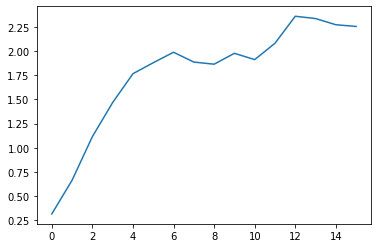

In [10]:
plt.plot(time_arr)
np.array(time_arr).mean()

In [11]:
from instagram import WebAgent, Account, WebAgentAccount
inst_accounts_raw_data = \
"""agniiamuraviova212:58nwNOT6iA:lignus_calereldor@mail.ru:k5eC1r7f9r
dinafomichiova4713:hjSOZ5Sx3g:hoildoyellowtap4@mail.ru:zvxeMApBu8t
lidiiadrozdova5662:hOQXuhdJxX:thonarthryrion@mail.ru:dBRO50yeGp
darinabobrova8107:AnNInVZcgP:oswricerumak1960@mail.ru:NE9ueF2e44Rc
karolinafiodorova7156:7DzQbVToaZ:algladekerin13@mail.ru:p5SRcnRFHqt
varvarabolshakova8794:PyvFqtfh1g:crandish.thomli1982@mail.ru:b7lRPT8Gjl2Ho
agniiazhdanova541:S4ApKhUBKh:sesil.felerion1996@mail.ru:sj1kqM4oi8
kiraovchinnikova680:414LKKrHPa:kewculmefaran@mail.ru:Ce2TKyXYZ5l
varvarakniazeva9295:sWXduOEjWz:wubohenlamb@mail.ru:L4RKjfoiNz
agniiafedoseeva9784:yhNb3U7fYd:globurnys@mail.ru:EYZE7lDE
agniiakolesnikova5157:rDfIoQSOIf:desil.baler1992@mail.ru:wCka7477
karolinaignatova5231:Og24M00VVd:mappinlamb@mail.ru:NaTwA1iuDK
dinarogova4678:yF0yURWwxY:alfmon-voodush@mail.ru:MTBphui6
darinasidorova5511:XdJ6sOB54C:iiruuja-manoc1987@mail.ru:Vx5Sjnj3owVCq
darinasazonova2973:M7KacJjW2a:lip-dwarf1984@mail.ru:oKAR1GqVV
aleksandrakniazeva7955:V3WYCG1fQ4:susil_norfimir@mail.ru:V6Q98usAy7f2
tamarazueva1062:vZ5r7U8pBe:jeinupoitho@mail.ru:ZR2IMPZ3gPe
elvirazhukova7840:oEjbiyQ63C:ulfheretoork1991@mail.ru:tX5ZMf3jI9
dinafedoseeva5862:WjC73NTsbL:rognarsalund@mail.ru:KZpOw0pIH9
iaroslavaignatova8267:KuxLCuSD0V:sihrwig-pudish@mail.ru:TxwgyXIxN5CG
leilakovaliova6560:zEhAFUjFGU:fefureoworfind@mail.ru:ubKh3euqyltkF
lidiiarogova4743:L9RtTctnuG:lerinnelynd@mail.ru:zQNyQ1pv8iw
ameliiafedoseeva674:v7iCXPTxGp:ulupoderoido3@mail.ru:s5931Ga2TV
ameliiasergeeva946:z5XYZp9iSM:tostwalpalo25@mail.ru:o6qXhC9h
darinabogdanova403:sDjWWR1QOq:egwin-drumog@mail.ru:OZ7lVd7wD1B
iaroslavabespalova1694:ErhvI2HSNm:pleghadrudish@mail.ru:RII7ymlPRMbI
reginapanfilova1678:xFzyYhKITD:pewdongonus@mail.ru:09SDiv9EyHTu5
sabinastepanova1794:1nlR5Tecpl:sihrerthvoogdush30@mail.ru:N7mrmg1vewZfE
varvarakhokhlova3462:Y01DVVGrJp:prisboroughdogan10@mail.ru:4P6Q95lN
agatasuvorova6583:8DelwWXf5x:folodragon@mail.ru:s6R8Q5mhBs
lidiiaershova6477:40FkUNxdVm:whitsilver-fagnus@mail.ru:QFz1b6Bsr3gE
varvaraaksionova5004:S6KLputgGG:osgythgriurk1979@mail.ru:OOA4v362A
kamillabelousova5951:b0Giqt1aWI:perunocshinycoin@mail.ru:LImm2CTaz
elizavetakudriavtseva6928:lg0GbPUxJv:elerthpudash@mail.ru:55xIrC872Iauuf
tamarakulakova2946:Wf8wjgwL3B:whitbourn_kegnus1998@mail.ru:qq6iAoxGPD
elizavetabobyliova5180:JsbhlnEr4B:kognar_belyr1984@mail.ru:NzOb3Gi11Ry3
reginalikhachiova8613:EFzPZSQppY:jaillaleridecan5@mail.ru:VlAm66I0b
leilaodintsova291:PZ5shkLkMR:yeiron-soinoc@mail.ru:bQln8i5K
leilakalinina4900:nWh8KCQjjD:nibwickrelin@mail.ru:Fp7znGQu8l
iaroslavabelousova121:LUn8gN8M6b:titchyardfoiran@mail.ru:SKjx3oQkeps272
agniiabeloziorova5654:E6KnPpzeXB:godeofmuidush1987@mail.ru:HHEnipN2d
elvirastepanova7106:H5WxUGQ1uB:drifswearsemli@mail.ru:ATlImh8qrt15vp
reginakovaliova726:mstGZkoHt0:fishalamb@mail.ru:CsF2LBTE2CKPn1
darinakomarova7420:hqcoZctWv8:lera.afanaseva.1976@mail.ru:nTI94FNF2R2bv
tamarasazonova6525:51CWj9hYkD:atheleof.grumak@mail.ru:A2roLp1IVNxZ
iaroslavaalekseeva5882:pRbrgZH47R:rotho_roosterpig@mail.ru:maoki8LqLqaS
leilagordeeva2201:ZOPjfCua2w:wirjatta.mupper1984@mail.ru:FthfbRxbg2TeEg
agatanikitina2554:zmiN0MXdMx:sasha_popova_61@mail.ru:SgrYH6thlqAvlK
ameliiasharapova9216:vGnWISq6PE:cenerth_tudash@mail.ru:aCnZVb6m
kamillafedoseeva5749:SoZ8pl1OxZ:cenwoldproogdish@mail.ru:PrDSOAODIapi5"""
agent = WebAgent()
working_agents = []
inst_accounts_data = [tuple(data.split(':')[:2]) for data in inst_accounts_raw_data.split('\n')]
for username, password in inst_accounts_data:
    try:
        ac = WebAgentAccount(username)
        ac.auth(password)
        working_agents.append((username, password))
        print('GOOD', username)
    except:
        print('BAD', username)
print(working_agents)

GOOD agniiamuraviova212
GOOD dinafomichiova4713
GOOD lidiiadrozdova5662
GOOD darinabobrova8107
BAD karolinafiodorova7156
GOOD varvarabolshakova8794
GOOD agniiazhdanova541
GOOD kiraovchinnikova680
GOOD varvarakniazeva9295
GOOD agniiafedoseeva9784
GOOD agniiakolesnikova5157
BAD karolinaignatova5231
BAD dinarogova4678
BAD darinasidorova5511
BAD darinasazonova2973
GOOD aleksandrakniazeva7955
GOOD tamarazueva1062
BAD elvirazhukova7840
BAD dinafedoseeva5862
GOOD iaroslavaignatova8267
GOOD leilakovaliova6560
GOOD lidiiarogova4743
GOOD ameliiafedoseeva674
GOOD ameliiasergeeva946
BAD darinabogdanova403
BAD iaroslavabespalova1694
GOOD reginapanfilova1678
GOOD sabinastepanova1794
GOOD varvarakhokhlova3462
GOOD agatasuvorova6583
GOOD lidiiaershova6477
GOOD varvaraaksionova5004
GOOD kamillabelousova5951
GOOD elizavetakudriavtseva6928
GOOD tamarakulakova2946
GOOD elizavetabobyliova5180
GOOD reginalikhachiova8613
BAD leilaodintsova291
GOOD leilakalinina4900
GOOD iaroslavabelousova121
BAD agniiabelozi

In [13]:
good = [('agniiamuraviova212', '58nwNOT6iA'), ('dinafomichiova4713', 'hjSOZ5Sx3g'), ('lidiiadrozdova5662', 'hOQXuhdJxX'), ('darinabobrova8107', 'AnNInVZcgP'), ('varvarabolshakova8794', 'PyvFqtfh1g'), ('agniiazhdanova541', 'S4ApKhUBKh'), ('kiraovchinnikova680', '414LKKrHPa'), ('varvarakniazeva9295', 'sWXduOEjWz'), ('agniiafedoseeva9784', 'yhNb3U7fYd'), ('agniiakolesnikova5157', 'rDfIoQSOIf'), ('aleksandrakniazeva7955', 'V3WYCG1fQ4'), ('tamarazueva1062', 'vZ5r7U8pBe'), ('iaroslavaignatova8267', 'KuxLCuSD0V'), ('leilakovaliova6560', 'zEhAFUjFGU'), ('lidiiarogova4743', 'L9RtTctnuG'), ('ameliiafedoseeva674', 'v7iCXPTxGp'), ('ameliiasergeeva946', 'z5XYZp9iSM'), ('reginapanfilova1678', 'xFzyYhKITD'), ('sabinastepanova1794', '1nlR5Tecpl'), ('varvarakhokhlova3462', 'Y01DVVGrJp'), ('agatasuvorova6583', '8DelwWXf5x'), ('lidiiaershova6477', '40FkUNxdVm'), ('varvaraaksionova5004', 'S6KLputgGG'), ('kamillabelousova5951', 'b0Giqt1aWI'), ('elizavetakudriavtseva6928', 'lg0GbPUxJv'), ('tamarakulakova2946', 'Wf8wjgwL3B'), ('elizavetabobyliova5180', 'JsbhlnEr4B'), ('reginalikhachiova8613', 'EFzPZSQppY'), ('leilakalinina4900', 'nWh8KCQjjD'), ('iaroslavabelousova121', 'LUn8gN8M6b'), ('reginakovaliova726', 'mstGZkoHt0'), ('iaroslavaalekseeva5882', 'pRbrgZH47R'), ('leilagordeeva2201', 'ZOPjfCua2w'), ('agatanikitina2554', 'zmiN0MXdMx'), ('ameliiasharapova9216', 'vGnWISq6PE')]
len(good) / 50

0.7

In [15]:
k = 0
for gr in bapi.get_obj('0dd').groups:
    name = gr.data['name'].lower()
    target_list = ['физтех', 'mipt', 'мфти', 'фпми', 'фивт']
    for word in target_list:
        if word in name:
            gr.print()
            k += 1
            break
print(k)

Экзамены Физтеха               https://vk.com/mipt_exams 
Потеряно на Физтехе            https://vk.com/mipt_lose 
ФИВТ МФТИ                      https://vk.com/dihtmipt 
Студсовет ФИВТ                 https://vk.com/stfivt 
Магистратура МФТИ              https://vk.com/magistr.mipt 
Международные стажировки для МФТИ   https://vk.com/mipt_internships 
Культурный физтех              https://vk.com/mipt_culture 
Технотрек & Физтех.            https://vk.com/trackmailru 
Признания на Физтехе           https://vk.com/love_mipt 
I Like Trip Клуб путешествий ВШЭ и МФТИ   https://vk.com/iliketrip 
ФПМИ МФТИ                      https://vk.com/miptfpmi 
Цитаты преподавателей МФТИ     https://vk.com/prepod_mipt 
Фонд целевого капитала МФТИ    https://vk.com/miptfund 
Физтех.Сегодня                 https://vk.com/students_of_mipt 
ФУПМ МФТИ                      https://vk.com/fupm_mipt 
Волонтеры МФТИ                 https://vk.com/vol_mipt 
Молодежный Комитет МФТИ (МКИ)   https://vk.com/mki_mip

In [15]:
id = '0ee'
params = obj.params
# params = Community.from_users(bapi.get_obj('391').users + bapi.get_obj('126').users).expand_community(break_point=5).params
print(params['community_size'])
print(params['occupation_type'])
print(params['occupation_name'])
print(params['universities_name'])
print(params['schools_type_str'])
print(params['schools'])
# bapi.get_obj(id).print()
# print(params)
print()
with open('data/_params.txt', 'w') as f:
    
    f.write(json.dumps(make_json_serializable(params)))
    
# params

193
[('university', 142), ('work', 22), ('school', 2)]
[('МФТИ (Физтех)', 130), ('МФТИ (ГУ) (см. в Москве)', 6), ('Яндекс', 4)]
[('МФТИ (Физтех)', 34), ('МФТИ (ГУ)', 34), ('МФТИ', 6)]
[('Лицей', 34), ('Гимназия', 23), ('Колледж', 3)]
[{'id': '696975', 'country': 1, 'city': 857, 'name': 'Физтех-лицей им. П. Л. Капицы (бывш. №11)', 'year_from': 2016, 'year_to': 2019, 'year_graduated': 2019, 'speciality': 'информат', 'type': 2, 'type_str': 'Лицей', 'amount': 6, 'fr': 0.031088082901554404}, {'id': '124841', 'country': 1, 'city': 169, 'name': 'Провинциальный колледж (ЯПК)', 'year_from': 2018, 'year_to': 2019, 'year_graduated': 2019, 'type': 8, 'type_str': 'Колледж', 'amount': 3, 'fr': 0.015544041450777202}, {'id': '82386', 'country': 4, 'city': 183, 'name': 'Школа-лицей №165', 'year_from': 2011, 'year_to': 2018, 'year_graduated': 2018, 'class': 'б', 'amount': 2, 'fr': 0.010362694300518135}]



In [81]:
for u in bapi.get_obj('340').users:
    if 'Педагогический колледж №10' in str(u.full_data):
        u.print()

Ксения Борисова 527952904 https://vk.com/id527952904
Юля Герасименко 196758543 https://vk.com/id196758543
Ксения Малая 217276439 https://vk.com/id217276439
Eliza Aristova 485415975 https://vk.com/id485415975
Екатерина Кузнецова 151475454 https://vk.com/id151475454


In [ ]:
ne_groups = Counter(
                        dict(
                            [
                                (node_group[nei], graph.edges[(node, nei)].get('weight', 1))
                                for nei in graph.neighbors(node)
                            ]
                        )
                    )

In [19]:
from sklearn.preprocessing import normalize
x = np.random.rand(5)*10
norm1 = x / np.linalg.norm(x)
norm2 = normalize(x[:,np.newaxis], axis=0).ravel()
norm1

array([0.37320257, 0.70729868, 0.14509851, 0.55634512, 0.17284372])

In [41]:
my_groups = user.groups_pool.groups_data
my_groups = sorted(my_groups, key=lambda x: x['members_count'])
groups = np.array([(gr['members_count'], gr['name']) for gr in my_groups])
print(groups)
# np.median(groups[:,0])
median = np.median(groups[:,0].astype(int)).astype(int)
dict(groups)[str(median)]

[['3' 'mdd test']
 ['119' 'Telarld']
 ['174' 'Официальная страница журнала "Ростки Ковчега"']
 ['186' 'Просмотры и трансляции ФИВТ']
 ['296' 'Алексей Кириллов. Портретный и семейный фотограф']
 ['351' 'ФПМИ.Индустрия 1 курс']
 ['440' 'Академия искусственного интеллекта']
 ['448' 'фтл каждый день']
 ['527' 'Театр-студия "МАЛАХИТ" Олега Малахова']
 ['598' 'Фонд целевого капитала МФТИ']
 ['602' 'День Первокурсника МФТИ 2019']
 ['1056' 'Учебные материалы ФИВТ (Оф. клуб любителей Го)']
 ['1217' 'Семейная школа поселения родовых поместий Ковчег']
 ['1246' 'CulturALL Reboot']
 ['1295' 'Питомник-БотСад-Поместье | сеянцы, саженцы |']
 ['1413' 'Абитуриенты ФПМИ МФТИ']
 ['1617' 'Студсовет ФИВТ']
 ['1870' 'Soft skills в МФТИ']
 ['1916' 'MIPT(Moscow Institute of Physics and Technology)']
 ['2003' 'Физтех Тур']
 ['2013' 'клуб любителей дискретной постиронии']
 ['2039' 'ФПМИ МФТИ']
 ['2584' 'СНПО «Бакалавры Физтеха»']
 ['2767' 'Экопоселение Родовых Поместий КОВЧЕГ']
 ['3233' 'Codeforces']
 ['3895' 'П

'VK Education'

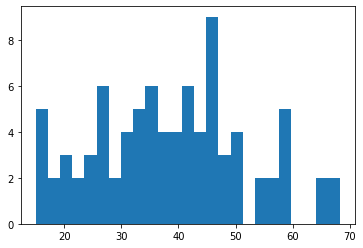

40.12472437003373

In [56]:
%matplotlib inline
user = VKUser('https://vk.com/didiv2000')
#user.friends_com.color_communities(user.friends_com.split())
plt.hist(user.friends_com.params['age_list'], bins=25)
plt.show()
user.friends_com.params['age_median']

In [7]:
activities_types = Counter()

In [10]:
for i in range(1000):
    print("LOOP", i)
    try:
        user = VKUser.get_random_user()
#         user.print()
#         user.friends_com.show_graph()
#         comms = user.get_communities()
        com = user.friends_com
#         for com in comms:
        items = list(com.community_groups.from_most_common(25).params['groups_pages_activity'])
        activities_types += Counter(items)
        print(len(list(activities_types)))
    except:
        user.print()

LOOP 0
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
295
LOOP 1
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
* VK API Request: %s execute
295
LOOP 2
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
Светлана Лепехова 206988099 https://vk.com/id206988099
LOOP 3
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
VK API error 6. Too many requests per second. Wait 1 seconds
VK API error 6. Too many requests per second. Wait 1 seconds
* VK API Request: %s execute
* VK API Request: %s execute
295
LOOP 4
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
Мар

* VK API Request: %s friends
* VK API Request: %s execute
Анастасия Лопатнева 293763653 https://vk.com/id293763653
LOOP 44
* VK API Request: %s users
* VK API Request: %s friends
15. Access denied: this profile is private. request_params = {'method': 'friends.get', 'oauth': '1', 'v': '5.35', 'lang': 'ru', 'user_id': '297336668'}
* VK API Request: %s execute
Olesya Stepanenko 297336668 https://vk.com/id297336668
LOOP 45
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
Dada Da 95694926 https://vk.com/id95694926
LOOP 46
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
VK API error 6. Too many requests per second. Wait 1 seconds
VK API error 6. Too many requests per second. Wait 1 seconds
* VK API Request: %s execute
298
LOOP 47
* VK API Request: %s users
* VK API Request: %s friends
15. Access denied: this profile is private. request_params = {'method': 'friends.get', 'oauth': '1', 'v': '5.35', 'lang': 'ru', 'user_id'

* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
303
LOOP 81
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
Елена Шишкина 82153157 https://vk.com/id82153157
LOOP 82
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
303
LOOP 83
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
* VK API Request: %s execute
VK API error 6. Too many requests per second. Wait 1 seconds
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
303
LOOP 84
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
303
LOOP 85
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
* VK API Request: %s execute
303
LOOP 86
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s e

* VK API Request: %s friends
* VK API Request: %s execute
VK API error 6. Too many requests per second. Wait 1 seconds
VK API error 6. Too many requests per second. Wait 1 seconds
Ефим Попов 81467773 https://vk.com/id81467773
LOOP 126
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
* VK API Request: %s execute
309
LOOP 127
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
309
LOOP 128
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
VK API error 6. Too many requests per second. Wait 1 seconds
VK API error 6. Too many requests per second. Wait 1 seconds
* VK API Request: %s execute
* VK API Request: %s execute
309
LOOP 129
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
Ксения Лузина 114889273 https://vk.com/id114889273
LOOP 130
* VK API Request: %s users
* VK API Request: %s friends
* V

* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
312
LOOP 163
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
* VK API Request: %s execute
312
LOOP 164
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
Анюта Тростникова 133896106 https://vk.com/id133896106
LOOP 165
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
Виктор Кочкарев 95750156 https://vk.com/id95750156
LOOP 166
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
Код Крушитель 276447667 https://vk.com/id276447667
LOOP 167
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
VK API error 6. Too many requests per second. 

...

* VK API Request: %s execute
355
LOOP 792
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
Нелька Акаева 214238056 https://vk.com/id214238056
LOOP 793
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
* VK API Request: %s execute
VK API error 6. Too many requests per second. Wait 1 seconds
VK API error 6. Too many requests per second. Wait 1 seconds
355
LOOP 794
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
* VK API Request: %s execute
355
LOOP 795
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
* VK API Request: %s execute
355
LOOP 796
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
Harry Kaler 411592968 https://vk.com/id411592968
LOOP 797
* VK API Request: %s users
VK API error 6. Too many requests per second. Wait 1 seconds
VK API error 6. Too many requests per second. Wait 1 seconds
* VK API Request: 

VK API error 6. Too many requests per second. Wait 1 seconds
* VK API Request: %s friends
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
357
LOOP 833
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
Милли Милливна 82453833 https://vk.com/id82453833
LOOP 834
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
357
LOOP 835
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
Сергей Замарайкин 51349512 https://vk.com/id51349512
LOOP 836
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
Лика Акил 235998762 https://vk.com/id235998762
LOOP 837
* VK API Request: %s users
* VK API Request: %s friends
15. Access denied: this profile is private. request_params = {'method': 'friend

* VK API Request: %s friends
* VK API Request: %s execute
* VK API Request: %s execute
361
LOOP 878
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
* VK API Request: %s execute
361
LOOP 879
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
Евгений Васильев 139620996 https://vk.com/id139620996
LOOP 880
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
VK API error 6. Too many requests per second. Wait 1 seconds
Victoria Vega 291078020 https://vk.com/id291078020
LOOP 881
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
* VK API Request: %s execute
361
LOOP 882
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
Скоро Лето 24077813 https://vk.com/id24077813
LOOP 883
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
* VK API Request: %s execute
361
LOOP 884
* VK API Request: %s user

* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
366
LOOP 920
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
Анечка Котя 58055061 https://vk.com/id58055061
LOOP 921
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
VK API error 6. Too many requests per second. Wait 1 seconds
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
366
LOOP 922
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
Vitalik Bugreev 223709488 https://vk.com/id22370948

* VK API Request: %s friends
15. Access denied: this profile is private. request_params = {'method': 'friends.get', 'oauth': '1', 'v': '5.35', 'lang': 'ru', 'user_id': '41558990'}
* VK API Request: %s execute
Григорий Кушнаренко 41558990 https://vk.com/id41558990
LOOP 961
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
Вован Денисов 17947740 https://vk.com/id17947740
LOOP 962
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
Sergey Dulov 242928900 https://vk.com/id242928900
LOOP 963
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
Дмитрий Щёголев 134478944 https://vk.com/id134478944
LOOP 964
* VK API Request: %s users
* VK API Request: %s friends
* VK API Request: %s execute
VK API error 6. Too many requests per second. Wait 1 seconds
VK API error 6. Too many requests per second. Wait 1 seconds
Rufat Gasanov 96193792 https://vk.com/id96193792
LOOP 965
* VK API Request: %s users
*

In [15]:
print(len(activities_types))
activities_types.most_common()

370


[('Юмор', 860),
 ('Кино', 608),
 ('Городское сообщество', 563),
 ('Интернет-СМИ', 448),
 ('Обмен музыкой', 416),
 ('Творчество', 368),
 ('Публичная страница', 348),
 ('Кулинария, рецепты', 342),
 ('Литература', 304),
 ('Отношения полов', 276),
 ('Уход за собой', 255),
 ('Образование', 255),
 ('Наука', 251),
 ('ВКонтакте', 244),
 ('Объявления', 244),
 ('Общество', 235),
 ('Молодёжное движение', 224),
 ('Шоу, передача', 211),
 ('Бизнес', 209),
 ('Знакомства', 200),
 ('Здоровый образ жизни', 193),
 ('Философия', 190),
 ('Стиль, одежда, обувь', 186),
 ('Фотография', 166),
 ('Туризм, путешествия', 162),
 ('Автомобили', 148),
 ('Дизайн интерьера', 147),
 ('Музыка', 143),
 ('Игры', 134),
 ('Телеканал', 129),
 ('Родители и дети', 126),
 ('Фитнес', 125),
 ('Культура', 102),
 ('Друзья', 99),
 ('СМИ', 95),
 ('Строительство, ремонт', 89),
 ('Поиск работы', 88),
 ('Вымышленный персонаж', 86),
 ('Сайты', 85),
 ('Искусство и развлечения', 78),
 ('Rap, Hip-Hop', 74),
 ('Футбол', 74),
 ('Дискуссионный 

In [1]:
print(len(activities_types))
activities_types.most_common()

NameError: name 'activities_types' is not defined

In [2]:
url = 'boris2000n'
user = VKUser(url)
comms = user.get_communities()
# user.friends_com.color_communities(comms)
# sum([com.size for com in comms])
# user.friends_com.size

* VK API Request: %s execute
* VK API Request: %s friends
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute
* VK API Request: %s execute


In [12]:
def getLikes(user_id, cnt, api):
    import time
    # подписки пользователя
    subscriptions_list = api.users.getSubscriptions(user_id=user_id,extended=0)['groups']['items']
    # формируем список id, который нужно передать в следующий метод
    groups_list = ['-' + str(x) for x in subscriptions_list]
    posts = {}
    # формируем ленту новостей
    newsfeed = api.newsfeed.get(
        filters='post',
        source_ids=', '.join(groups_list),
        count=100, timeout=10)
    # добавляем посты в словарь в формате id_поста: id_группы
    posts.update({x['post_id']: x['source_id'] for x in newsfeed['items']})
    # нужно для получения следующей партии
    # если требуется более одного запроса — делаем остаток в цикле
    if cnt != 1:
        for c in range(cnt - 1):
            next_from = newsfeed['start_from']
            kwargs = {
                'from': next_from,
                'filters': 'post',
                'source_ids': ', '.join(groups_list),
                'count': 100,
                'timeout': 10
            }
            newsfeed = api.newsfeed.get(**kwargs)
 
            posts.update({x['post_id']: x['source_id'] for x in newsfeed['items']})
#             time.sleep(1)
    liked_posts = []
 
    print('Лайкнутые посты:')
    for post in posts.items():
        try:
            itemID = post[0]
            ownerID = post[1]
            timeOut = 5
            isLiked = api.likes.isLiked(
                user_id=user_id,
                item_id=itemID,
                type='post',
                owner_id=ownerID,
                timeout=timeOut)['liked']
        except Exception:
#             print('ERROR! ' + 'vk.com/wall{0}_{1}'.format(post[1], post[0]))
            isLiked = 0
#         print(isLiked)
        if isLiked:
#             liked_posts.append('vk.com/wall{0}_{1}'.format(post[1], post[0]))
            print('https://vk.com/wall{}_{}'.format(post[1], post[0]))
            time.sleep(0.25)
    return liked_posts
getLikes(user.vkid, 0, bapi.api_user)

* VK API Request: %s users
* VK API Request: %s newsfeed
Лайкнутые посты:
* VK API Request: %s likes
* VK API Request: %s likes
* VK API Request: %s likes
* VK API Request: %s likes
* VK API Request: %s likes
* VK API Request: %s likes
* VK API Request: %s likes
* VK API Request: %s likes
VK API error 6. Too many requests per second. Wait 1 seconds
VK API error 6. Too many requests per second. Wait 1 seconds
* VK API Request: %s likes
* VK API Request: %s likes
* VK API Request: %s likes
* VK API Request: %s likes
* VK API Request: %s likes
* VK API Request: %s likes
* VK API Request: %s likes
* VK API Request: %s likes
* VK API Request: %s likes
VK API error 6. Too many requests per second. Wait 1 seconds
VK API error 6. Too many requests per second. Wait 1 seconds
* VK API Request: %s likes
* VK API Request: %s likes
* VK API Request: %s likes
* VK API Request: %s likes
* VK API Request: %s likes
* VK API Request: %s likes
* VK API Request: %s likes
* VK API Request: %s likes
* VK AP

[]

## Выявление сообществ на графе друзей испытуемого

In [21]:
G = user.friends.graph

## Отрисовка разделенного на сообщества графа друзей

## Нахождение полного сообщества по нескольким участникам

In [651]:
base_community = np.array(a[1])

In [14]:
def print_func_plot(func, params, x=None):
    results = []
    for args in params:
        results.append(func(**args))
    if x is None:
        x = range(len(results))
    plt.plot(x, results)
    plt.show()

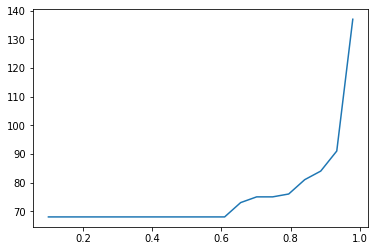

In [318]:
x = np.linspace(0.1, 0.98, num=20)
print_func_plot(
    get_community_size, 
    [
        {
            'weight_reduction_ratio': i,
            'break_point': 10,
        }
        for i in x
    ],
    x=x
)

## Нахождение общего знаменателя среди сообщества (школа, вуз, место жительста, группы вк и т.д)

In [1]:
from community import Community
Community.generate_random(20).print_users(5)

Serj Karaush https://vk.com/id413176842 
Эльвира Марсова https://vk.com/id404693545 
Евгений Добрый https://vk.com/id349755405 
Борис Юльметьев https://vk.com/id175167265 
Ира Туманова https://vk.com/id228994866 


In [679]:
# comm1 = Community.from_nodes_part(base_community)
# comm1.print_users(2)

Никита Брюзгин https://vk.com/id166141735 
Елизавета Шерстнёва https://vk.com/id170099909 


In [709]:
Community.from_nodes_part([my_id, 269339915, 493754172, 211915613], 
                          weight_reduction_ratio=0.5, break_point=3).get_special_params()

* Get user data 245520002
* Get user data 372043906
* Get user data 190016644
* Get user data 344735749
* Get user data 125646982
* Get user data 295948807
* Get user data 437530634
* Get user data 269339915
* Get user data 265405579
* Get user data 193795087
* Get user data 344871324
* Get user data 155987360
* Get user data 504638756
* Get user data 20352294
* Get user data 123543974
* Get user data 195097896
* Get user data 314043174
* Get user data 453566375
* Get user data 235933101
* Get user data 493754172
* Get user data 231293500
* Get user data 200109760
* Get user data 199148993
* Get user data 402705610
* Get user data 157185614
* Get user data 415803087
* Get user data 396970062
* Get user data 13759701
* Get user data 341467094
* Get user data 230749912
* Get user data 211915613
* Get user data 415808612
* Get user data 140878439
* Get user data 272023406
* Get user data 271552501


{'community_size': 36,
 'sex_mean': 1.6944444444444444,
 'age_median': 18.532233380395013,
 'city_first_fr': 0.5,
 'country_first_fr': 0.7222222222222222,
 'online_mean': 0.1388888888888889,
 'online_mobile_mean': 1.0,
 'verified_mean': 0.0,
 'last_seen_mean': 0.47183191654265055,
 'last_seen_amax': 1.9163202021767696,
 'last_seen_median': 0.07136649847306586,
 'site_fr': 0.1388888888888889,
 'followers_count_mean': 68.5,
 'followers_count_median': 47.0,
 'followers_count_amax': 309.0,
 'home_town_first_fr': 0.19444444444444445,
 'occupation_type_first_fr': 0.1388888888888889,
 'occupation_name_first_fr': 0.027777777777777776,
 'personal_langs_first_fr': 0.2777777777777778,
 'personal_political_first_fr': 0.027777777777777776,
 'personal_religion_first_fr': 0.027777777777777776,
 'personal_people_main_first_fr': 0.1111111111111111,
 'personal_smoking_first_fr': 0.08333333333333333,
 'personal_alcohol_first_fr': 0.05555555555555555,
 'personal_life_main_first_fr': 0.08333333333333333,
 

In [2]:
target_users = ['https://vk.com/emirudesu', 
                'https://vk.com/mra4kovsky', 
                'https://vk.com/chtobtizdox', 
                'https://vk.com/jinandja']

users_com = Community.from_urls(target_users)

In [9]:
for target_user in users_com.users:
    print()
    print(f'Рассматриваем {target_user.print_data}')
    for friend in target_user.friends.users:
        if 57466174 in friend.groups.groups:
            print(friend.print_data)


Рассматриваем Эмиль Шайбаков 96802262 https://vk.com/id96802262
    Среди друзей найден Дарья Некипелова 273869829 https://vk.com/id273869829
    Среди друзей найден Саша Ударцев 81818657 https://vk.com/id81818657
    Среди друзей найден Кима Миннуллина 80554087 https://vk.com/id80554087
    Среди друзей найден Полина Андреева 16861313 https://vk.com/id16861313
    Среди друзей найден Максим Нестеров 193440959 https://vk.com/id193440959
    Среди друзей найден Анастасия Кит 144939749 https://vk.com/id144939749
    Среди друзей найден Фархад Джумаев 229433602 https://vk.com/id229433602
    Среди друзей найден Варя Никонова 157166340 https://vk.com/id157166340
    Среди друзей найден Жинан Джабер 332297507 https://vk.com/id332297507
    Среди друзей найден Виктория Тутарова 422992227 https://vk.com/id422992227
    Среди друзей найден Юля Яковлева 121218921 https://vk.com/id121218921
    Среди друзей найден Вероника Низаметдинова 82413474 https://vk.com/id82413474
    Среди друзей найден

In [583]:
from tqdm import tqdm_notebook as tqdm
for i in tqdm(range(2)):
    size = np.random.randint(20, 250)
    params = Community.generate_random(size).get_special_params()
#     print(params)
    CommunityData.create(data=params)

In [584]:
comm_data = [i.data for i in CommunityData.select().execute()]
def param_list(key):
    return [x[key] for x in comm_data]
params = ['community_size', 'sex_mean', 'age_median', 'city_first_fr', 
'country_first_fr', 'online_mean', 'online_mobile_mean', 
'verified_mean', 'last_seen_mean', 'last_seen_amax', 
'last_seen_median', 'site_fr', 'followers_count_mean', 
'followers_count_median', 'followers_count_amax', 'home_town_first_fr', 
'occupation_type_first_fr', 'occupation_name_first_fr', 'personal_langs_first_fr', 
'personal_political_first_fr', 'personal_religion_first_fr', 'personal_people_main_first_fr', 
'personal_smoking_first_fr', 'personal_alcohol_first_fr', 'personal_life_main_first_fr', 
'relatives_childs_fr', 'relation_first_fr', 'schools_first_fr', 
'schools_type_str_first_fr', 'status_fr']

community_size


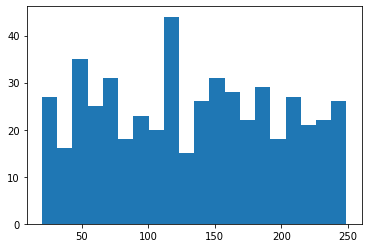

sex_mean


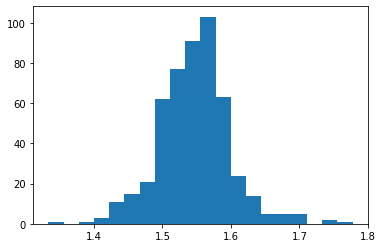

age_median


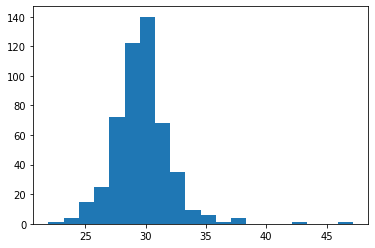

city_first_fr


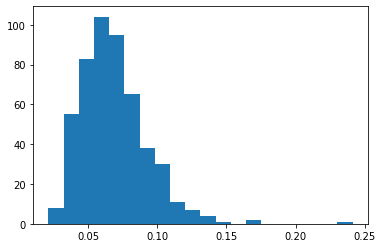

country_first_fr


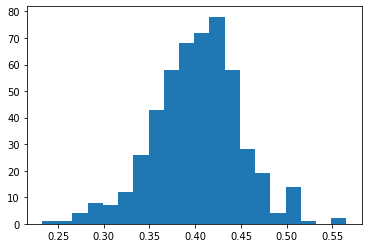

online_mean


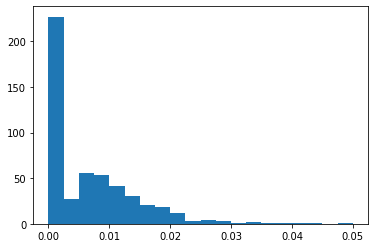

online_mobile_mean


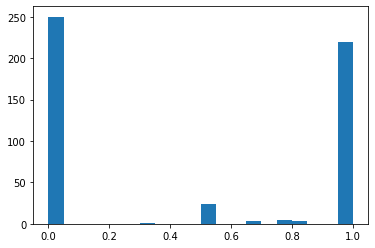

verified_mean


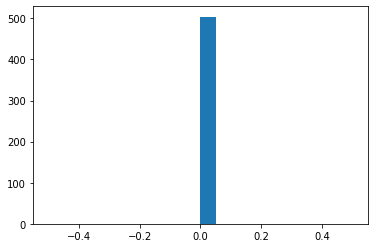

last_seen_mean


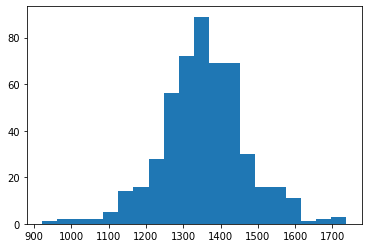

last_seen_amax


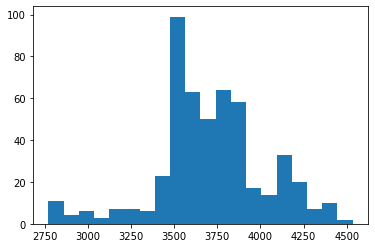

last_seen_median


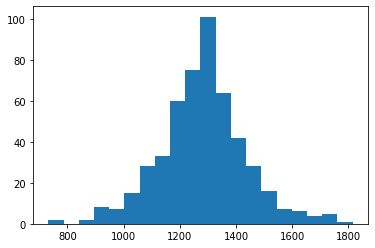

site_fr


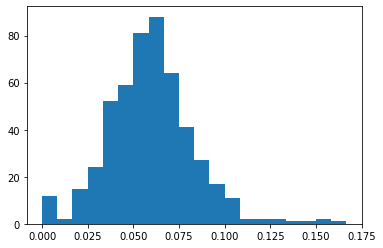

followers_count_mean


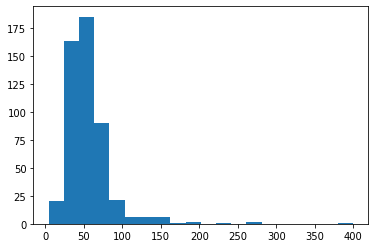

followers_count_median


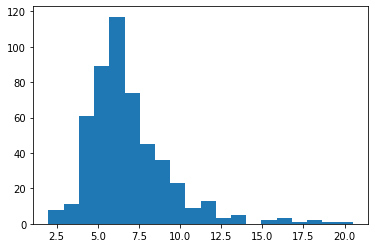

followers_count_amax


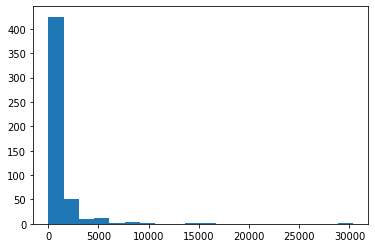

home_town_first_fr


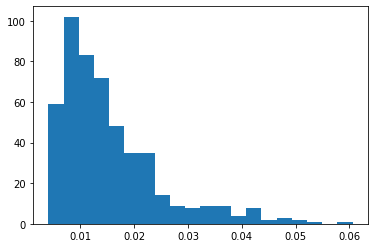

occupation_type_first_fr


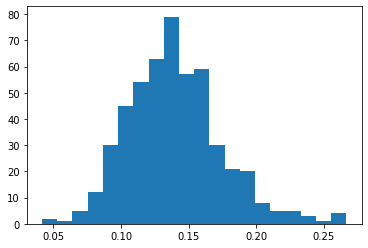

occupation_name_first_fr


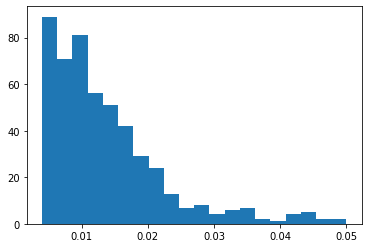

personal_langs_first_fr


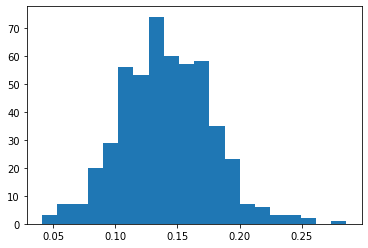

personal_political_first_fr


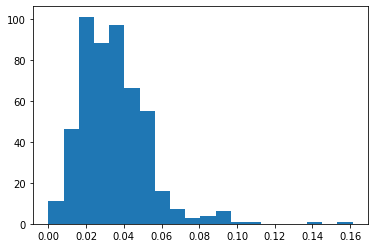

personal_religion_first_fr


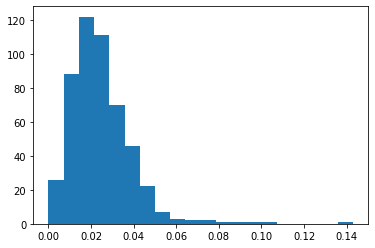

personal_people_main_first_fr


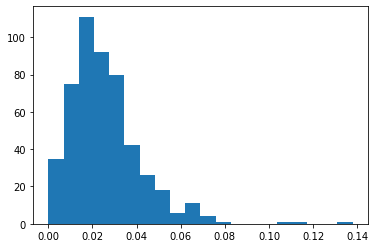

personal_smoking_first_fr


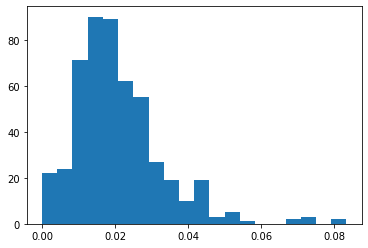

personal_alcohol_first_fr


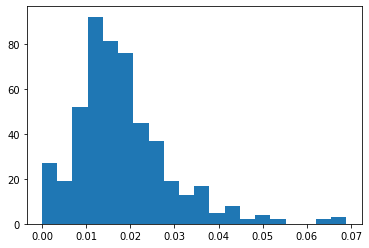

personal_life_main_first_fr


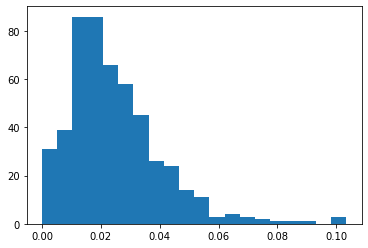

relatives_childs_fr


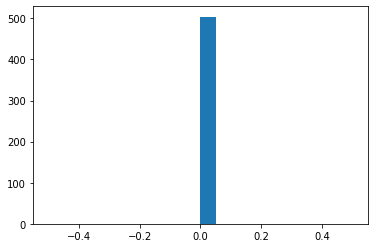

relation_first_fr


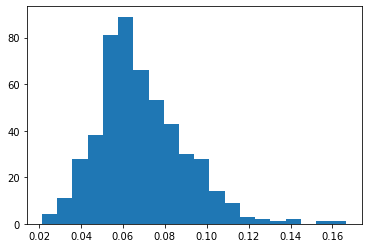

schools_first_fr


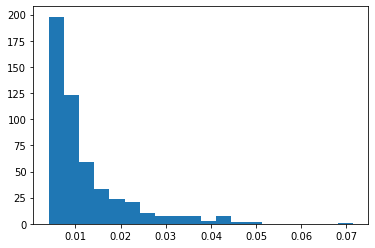

schools_type_str_first_fr


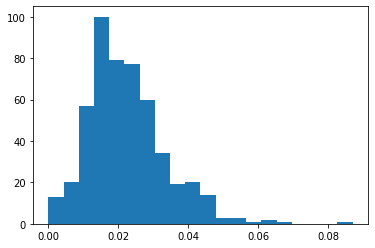

status_fr


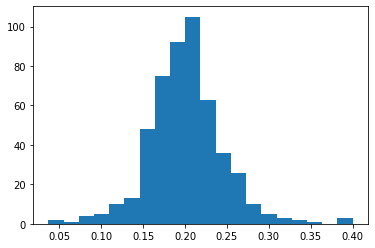

In [680]:
# Community.generate_random(1).special_params
for p in params:
    print(p)
    l = param_list(p)
    plt.hist(l, 20)
    plt.show()

In [681]:
key_importance = []
target_community = comm1.get_params()

for key in params:
    target_element = target_community[key]
#     print(target_element)
    hist_list = param_list(key)
    bins = 10
    hist_values, hist_x = np.histogram(hist_list, bins)
#     plt.hist(hist_list, bins)
#     plt.show()
#     print(hist_x)
    if target_element < hist_x[0]:
        hist_value = 0
    elif target_element > hist_x[-1]:
        hist_value = 0
    else:
        hist_column = np.where(hist_x <= target_element)[0][-1]
        hist_value = hist_values[hist_column]

    hist_max = np.max(hist_values)
    element_importance = hist_value / hist_max
    key_importance.append((element_importance, key))
#     print(hist_max)
#     print(element_fr)
[print(i) for i in sorted(key_importance)]
None

* Get user data 229170215
* Get user data 2384937
* Get user data 327191868
* Get user data 1727556
* Get user data 150879566
* Get user data 349087825
* Get user data 305752720
* Get user data 280349348
* Get user data 332072868
* Get user data 179897523
* Get user data 203419100
(0.0, 'age_median')
(0.0, 'city_first_fr')
(0.0, 'country_first_fr')
(0.0, 'followers_count_median')
(0.0, 'home_town_first_fr')
(0.0, 'last_seen_amax')
(0.0, 'last_seen_mean')
(0.0, 'last_seen_median')
(0.0, 'occupation_name_first_fr')
(0.0, 'occupation_type_first_fr')
(0.0, 'online_mean')
(0.0, 'schools_first_fr')
(0.0, 'schools_type_str_first_fr')
(0.0, 'status_fr')
(0.012, 'online_mobile_mean')
(0.07692307692307693, 'site_fr')
(0.09818181818181818, 'followers_count_mean')
(0.13664596273291926, 'personal_smoking_first_fr')
(0.20382165605095542, 'personal_alcohol_first_fr')
(0.21674876847290642, 'personal_people_main_first_fr')
(0.2261904761904762, 'sex_mean')
(0.23622047244094488, 'personal_langs_first_fr'

In [15]:
from instagram.client import InstagramAPI

client_id  = 'c6ab41f3c1094082aadf0cc0c6c4bb27'
client_secret = '16a8afe3350a43d697ac5138881c94fc'
access_token = '12638820603.c6ab41f.cad5b7d0690b496691583fc689a03b10'

api = InstagramAPI(client_id=client_id, client_secret=client_secret, access_token=access_token)

follows, next_ = api.user_follows()

InstagramAPIError: (400) OAuthPermissionsException-This request requires scope=follower_list, but this access token is not authorized with this scope. The user must re-authorize your application with scope=follower_list to be granted this permissions.

In [16]:
from instagram.client import InstagramAPI
import sys

if len(sys.argv) > 1 and sys.argv[1] == 'local':
    try:
        from test_settings import *

        InstagramAPI.host = test_host
        InstagramAPI.base_path = test_base_path
        InstagramAPI.access_token_field = "access_token"
        InstagramAPI.authorize_url = test_authorize_url
        InstagramAPI.access_token_url = test_access_token_url
        InstagramAPI.protocol = test_protocol
    except Exception:
        pass

# Fix Python 2.x.
try:
    import __builtin__
    input = getattr(__builtin__, 'raw_input')
except (ImportError, AttributeError):
    pass

client_id = input("Client ID: ").strip()
client_secret = input("Client Secret: ").strip()
redirect_uri = input("Redirect URI: ").strip()
raw_scope = input("Requested scope (separated by spaces, blank for just basic read): ").strip()
scope = raw_scope.split(' ')
# For basic, API seems to need to be set explicitly
if not scope or scope == [""]:
    scope = ["basic"]

api = InstagramAPI(client_id=client_id, client_secret=client_secret, redirect_uri=redirect_uri)
redirect_uri = api.get_authorize_login_url(scope = scope)

print ("Visit this page and authorize access in your browser: "+ redirect_uri)

code = (str(input("Paste in code in query string after redirect: ").strip()))

access_token = api.exchange_code_for_access_token(code)
print ("access token: " )
print (access_token)



Client ID: c6ab41f3c1094082aadf0cc0c6c4bb27
Client Secret: 16a8afe3350a43d697ac5138881c94fc
Redirect URI: https://rudrastyh.com/tools/access-token


KeyboardInterrupt: 

In [78]:
from instagram import Account, Media, WebAgent

agent = WebAgent()
account = Account("essie_amy334")

# media_objects, pointer = agent.get_media(account)
media, pointer = agent.get_media(account, count=100, delay=1)

In [58]:
# obj = media1[3]
# for item in dir(obj):
#     print(item, getattr(obj, item))

In [79]:
keys = ['caption', 'date', 'display_url', 'likes_count', 'comments_count']
for obj in media_objects:
    print(obj.display_url)

https://scontent-amt2-1.cdninstagram.com/vp/1b57e342eaf4c8802078f1ab01c541aa/5E24A260/t51.2885-15/e35/71024929_232709697697918_8404479157268540884_n.jpg?_nc_ht=scontent-amt2-1.cdninstagram.com&_nc_cat=110
https://scontent-amt2-1.cdninstagram.com/vp/bd544b9ced95cc3ca29ed2f98f0ceb89/5E1758BD/t51.2885-15/e35/69357277_107572600505017_2119080385914866789_n.jpg?_nc_ht=scontent-amt2-1.cdninstagram.com&_nc_cat=101
https://scontent-amt2-1.cdninstagram.com/vp/85672d75945507b84be01460634949f7/5E04AC80/t51.2885-15/e35/69805450_133553997927918_5874482647860257742_n.jpg?_nc_ht=scontent-amt2-1.cdninstagram.com&_nc_cat=106
https://scontent-amt2-1.cdninstagram.com/vp/4d579b5be46908036d95f0c98ee63310/5E3675F1/t51.2885-15/e35/69143631_493140504832604_7395125488741647540_n.jpg?_nc_ht=scontent-amt2-1.cdninstagram.com&_nc_cat=108
https://scontent-amt2-1.cdninstagram.com/vp/8befc8ddc30cc25112ee8bac6387a86c/5E16AC4A/t51.2885-15/e35/69078067_755965958172567_6808493308163585663_n.jpg?_nc_ht=scontent-amt2-1.cdni

In [3]:
from instagram import WebAgentAccount
from instagram import Account, Media, WebAgent

# agent = WebAgentAccount("fivol5")
# agent.auth('dlz08UtKFinst')

agent2 = WebAgentAccount('borfiner')
agent2.auth('dlz08UtKFfivol')
# f = agent2.get_follows(Account('cuvoe'), delay=0)[0]
# f = agent.get_follows(Account('cuvoe'), delay=0, count=100)[0]
agent2.username

'borfiner'

In [17]:
data, pointer = agent.get_follows(Account('cuvoe'), delay=0)
data2 = agent2.get_follows(pointer=pointer, delay=0)[0]
# print(data)
print(data, data2)

[taetaebooo, jypetwicenayeon, killrtaekook, _s.kripton_, svyatalina, essie_amy334, msuga1628, diakka__, astmodeus, yukokiro, mikialiet, the.kurb, my_afterglow_, jisoo.mp4, larkicheva, ester_exposito, jung_mariia, ugllliver.r, orthvs, jhopetv] [on_seish, al.boss006, mishalaz, kirillovphoto, vladomot]


In [27]:
for i in f:
    print(i)
    d = agent2.get_follows(Account(i), count=100, delay=0)[0]
    print(d)

taetaebooo
[malive.art, fabxiao, vanillahobie, bts.biighitofical, hannes_becker, koosarchive, shooky_dough, reiz_i, chungha_official, bts.world.official, koalaguk, iamhalsey, randomsplashes, kookiechimm, 2ah.in, hyundai.lifestyle, for__infinity, jiminskth, boo.archive, miyayeah, bn_sj2013, selenaspiral, ireneisgood, dora._.a, debaek, kimtaehyungscloset, winter_strawverry, _nuna_v, bt21club, mejiwoo103, bts_love_myself, bt21_official, sonsungdeuk, bighit_exhibition, bts.bighitofficial]
jypetwicenayeon
[renebaebae, twiceetweets, kym1222, im_cuck_oo, _imyour_joy, yeojin9oo, _happiness_o, ppong_ling, lesyeuxdenini, txt_bighit, han_bling_, sc__0322, jiyeon2__, geewonii, sweetthyunjin, damhee_00, abproject.official, seyoung__0203, cho.jiii, official_everglow, baifernbah, songjoongkionly, kyo1122, realllllmino, twicetagram, 3riii_0.k, hi_sseulgi, xeesoxee, petalhyunjin, shxxbi131, imhyoseop, yerimiese, chaeryeongfacts, hearthyunjins, nct127, itzy.all.in.us, hyunjinjyp, skz.straykids, straykid

[hisokafisting, simonakust, discosunniva, vivotattoo, sm_____tattoo, tattooist_mijeongwon, photohelll, lilli.ptz, svyatalina, _s.kripton_, astmodeus, javi.borrego, kulikulikulik, maratneva, titomerello, badgalriri, bymysidekookv, kedavra.art, voguemagazine, frejaerichsen, dididediego, manurios, simihaze, for_ladies_ua, jjjytikus, codyfern, designclass_odessa, _s.o.c.k.s, jessiehark_, flesh.png, naeriy, toface_ukraine, basquiatart, bohemianxse, _ul.na, xxmalato.jpg, darararm, xxiujj, chey_maya, vetements_official, kasiqjungwoo, itsnotsonia, michiko_malandro_, myaso_gorit, costarastrology, galaktionova_nastya, calvinklein, blonded, thegorgeousbane, areyouami, luv_jayne, for__infinity, doo.jk, nogobed, dianasilverss, mayonezusuki, pomogisebe, rommroom, case.she, pprofessorr, jacobbix, queenvelv, shooky_dough, dracarysgang, katemoss90s, thetogfather, hi_sseulgi, asaprocky, chiitan7407, jihobts, r._.kiya, _shoproishodit_, bts.bighitofficial, _imyour_joy, clara.berry, darjjap, shaaantiiiiiii